# Error-Semitransparent Gates on a Binomial Kitten Code

*Replication of Roy, Wetherbee & Fatemi, arXiv:2603.15356: logical gates on a binomial kitten
code that stay error-semitransparent while the gate is still running. Three gates, `X`, `H`, and
`T`; two variants each (`est`, the full $C_1{+}C_2{+}C_3{+}C_4$ objective, and `ord`, the same
code path with $w_2 = w_3 = 0$); all six cold-started at **2000 L-BFGS-B iterations per stage**
(`T`/`ord` converges on `pgtol` in 16 iterations and never needs the budget), all six trained at
**seed 0**. A ten-seed `est` sample at a reduced budget is in [§9](#9), and the three
screen winners were retrained cold at 2000 it/stage on the eigh pipeline in
[§9.2](#9.2); every headline number in the table below is still a single draw (JAX,
seed 0). See [limitation 4](#10).*

## Summary

**The claim being tested.** A gate is *error-transparent* if a photon loss that happens
mid-gate commutes through the rest of the evolution: the evolved error state at time $t$ stays
equal to the photon-loss image of the evolved code state at time $t$, so the same recovery map
still corrects it at $t = T$. An ordinary gate scrambles the error space against the code space
and the loss becomes uncorrectable.

That ideal is unreachable with linear drives — the paper's App. A, restated in [§1.3](#1.3).
Kerr and the second-order dispersive shift fail to commute with photon loss, and no control in
this Hamiltonian can cancel the leftover. The training target is therefore
*error-semitransparent* gates: maximize the transparency of each gate, not drive
$F_{\mathrm{ET}}$ to 1. The paper reports $F_{\mathrm{ET}} \approx 0.83$ on that construction.

**What this notebook reports.** The six delivered pulses, scored through an *independent*
propagator, against the three time-resolved transparency metrics of the paper's Eqs. 6--8,
**transcribed** from the published equations rather than reconstructed ([§2.3](#2.3)), so the
values below are directly comparable to the paper's own:

| gate | $F_1$ (EsT) | $F_{\mathrm{ET}}$ (EsT) | $L_{E_j}$ EsT / Ord | Ord:EsT on $L$ | Ord:EsT on $\eta(\lvert 0_L\rangle)$ |
|:----:|:-----------:|:-----------------------:|:-------------------:|:--------------:|:------------------------------------:|
| X | 0.99929 | 0.730 | 0.258 / 0.740 | 2.87x | 6.59x |
| H | 0.99968 | 0.818 | 0.172 / 0.780 | 4.52x | 5.19x |
| T | 0.99998 | 0.945 | 0.054 / 0.377 | 6.97x | n/a |

For scale: the paper's own X/EsT sits at $L = 0.22$ against the $0.258$ here, and its Ord:EsT
ratio at 2.74x against 2.87x ([§10](#10), limitation 3). T's $\eta$ ratio is undefined because
both its variants are at machine zero on that trace.

Every number above is recomputed live in [§5](#5); none is transcribed into the code.

Three findings carry the document:

1. **Transparency is cheap in fidelity.** On X and H, EsT buys a 2.9--4.5x improvement on $L$
   and 5.2--6.6x on $\eta$ for $\sim 7\times10^{-4}$ of ordinary infidelity. The trade is the
   intended one, not a defect: `ord` spends its entire budget on $C_1$ and has nothing left to
   spend elsewhere.
2. **The H-vs-X gap is gate-dependent, not budget-dependent.** At an *identical* 2000-it/stage
   cold start with identical per-iteration cost, H reaches $F_{\mathrm{ET}} = 0.818$ against X's
   0.730, at *higher* $F_1$ and with $L$ better by a third. Iteration count was the obvious
   suspect and has been ruled out ([§10](#10), limitation 1). What is left is not yet
   identified. Note this is now a *split* decision rather than a clean sweep: X leads on
   $\eta(|0_L\rangle)$ and on $\Delta_{\mathrm{QEC}}$ ([§5](#5), Table 9).
3. **T is not a scaled-down X/H; it is a different regime.** T is a pure qubit-frame phase
   gate: `CONTROL_MASK` zeroes the cavity drive exactly, `ord` reaches $F_1 = 1.00000$ in 16
   iterations rather than exhausting the 2000-iteration budget, and both variants sit at the
   same `max_active_fock = 4`: unlike X/H, T's two variants *are* like-for-like on the
   fair-comparison criterion ([§10](#10), limitation 2). Under the transcribed Eqs. 6 and 8 it
   is transparent to **machine precision** — $\Delta_{\mathrm{QEC}} \sim 10^{-27}$,
   $\eta(|0_L\rangle) \sim 10^{-14}$ for *both* variants — because a diagonal gate driven
   through the transmon alone does not mix Fock levels. Only $L$ still separates the two, at
   6.97x. Read that as a property of how little transparency-scrambling a diagonal gate needs
   to begin with, not as evidence T's EsT pulse is categorically better-behaved; see
   [§6.1](#6.1).
4. **The end-of-gate leak is fixable.** Adding a terminal error-space fidelity term takes
   X's $L(T)$ from $0.398$ to $0.005$ (paper: $0.013$) at unchanged $F_1$ and
   $F_{\mathrm{ET}}$. Single seed, eigh pipeline ([§11](#11)).

**Out of scope.** The `LE` control variant is not implemented, and neither is the AQEC recovery
pulse behind the paper's Figs. 4--5. See [§10](#10).

**Reading order.** [§1](#1) fixes the device and the code, [§2](#2) derives the objective and
records where it deviates from the paper's printed equations, [§3](#3) shows the code that runs
it, [§4](#4)--[§6](#6) are the results, [§7](#7) is validation, [§8](#8) documents a
second training pipeline built on a hand-derived analytic gradient, [§9](#9) puts ten-seed
error bars on all three gates and spends the production budget on the winners
([§9.2](#9.2)), [§10](#10) is the caveat list, [§11](#11) adds cost terms that close the end-of-gate leak, and [Appendix A](#A) retrains X with the cost function exactly as the paper prints it.
A reader who only wants the numbers can go straight to [§5](#5).


## Preamble: imports and knobs

Imports, paths, and the two switches that control what this notebook recomputes. [§3](#3)
documents the training API itself; this cell only makes it importable.

In [1]:
import os
import sys
import json
import glob
import subprocess

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# EST.grape_jax sets jax_enable_x64 at import time, so it must come before any
# other JAX use in the session.
from EST import grape_jax
from EST import device, kitten_code, train_est, diagnostics, subspace_evolution
from core.grape_core import make_ops

# --- knobs ---
RUN_TRAINING      = False   # True retrains from scratch: 0.01-10.1 h PER RUN, six runs.
REGENERATE_FIGURES = True   # recompute the analysis figures and overwrite figures/est/, tables/
RUN_TESTS         = True    # run EST/test_grape_jax.py as a subprocess in section 7 (~30 s)
GATES             = ["X", "H", "T"]
N_C               = 20      # scoring truncation; the trained one
# -------------

PULSE_DIR = os.path.join(REPO_ROOT, "pulses", "est")
FIG_DIR   = os.path.join(REPO_ROOT, "figures", "est")
TABLE_DIR = os.path.join(REPO_ROOT, "tables")
LOG_DIR   = os.path.join(REPO_ROOT, "logs")

EST_COLOR, ORD_COLOR = "#2a6fb5", "#c4453c"   # matched to EST/diagnostics.py

# Figures are SAVED and then displayed with IPython.display.Image rather than with
# display(fig): EST/diagnostics.plot_fig1 and EST/subspace_evolution.plot_fig1a both call
# matplotlib.use("Agg") from inside the function, so an inline-rendered figure would depend
# on cell execution order. width= is also how each figure is held to a moderate on-page size.
def show(path, width=900):
    display(Image(filename=path, width=width))

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print("repo root:", REPO_ROOT)

repo root: /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE


In [2]:
import scipy, jax, matplotlib
for name, mod in [("numpy", np), ("scipy", scipy), ("jax", jax),
                  ("matplotlib", matplotlib), ("pandas", pd)]:
    print(f"{name:12s} {mod.__version__}")
print(f"{'python':12s} {sys.version.split()[0]}")
print(f"{'x64 enabled':12s} {jax.config.jax_enable_x64}")

numpy        2.0.2
scipy        1.13.1
jax          0.4.30
matplotlib   3.9.4
pandas       2.3.3
python       3.9.6
x64 enabled  True


<a id="1"></a>
# 1. The device and the code

### 1.1 System model

A transmon $B$ dispersively coupled to a storage cavity $A$, with drift

$$
H_0 \;=\; \chi\, n_A n_B \;+\; \frac{K_a}{2} A^{\dagger 2} A^2 \;+\; \frac{K'}{6} A^{\dagger 3} A^3
\;+\; \frac{\chi'}{2} n_B A^{\dagger 2} A^2 \;+\; \frac{K_q}{2} B^{\dagger 2} B^2 ,
$$

and four real controls $[\,C_I, C_Q, T_I, T_Q\,]$ entering as $\varepsilon_C = C_I + iC_Q$ on the
cavity and $\varepsilon_T = T_I + iT_Q$ on the transmon.

`EST/device.py` builds this rather than reusing `core.grape_core.make_hamiltonian`, and differs
from it in two ways that matter:

- the second-order cavity self-Kerr $K'$, which the main pipeline's $H_0$ does not carry at all;
- `n_t >= 3` is **enforced with a raise**. The main pipeline silently drops the anharmonicity
  term at `n_t = 2`; here that would discard $K_q/2\pi = -180$ MHz, the largest number in the
  table below.

The `chi`/`Kerr` globals in `core/grape_core.py` are never touched: every pulse in `pulses/`
and the whole `validation/` layer is scored against those, and mutating them to run EsT work
would silently invalidate the other track.

In [3]:
tp = device.two_pi
rows = [
    ("$\\chi/2\\pi$",        device.chi   / tp * 1e3, "MHz -> kHz", "dispersive qubit-cavity coupling"),
    ("$K_a/2\\pi$",          device.K_a   / tp * 1e3, "MHz -> kHz", "cavity self-Kerr"),
    ("$K'/2\\pi$",           device.K_p   / tp * 1e6, "MHz -> Hz",  "second-order cavity self-Kerr"),
    ("$\\chi'/2\\pi$",       device.chi_p / tp * 1e3, "MHz -> kHz", "second-order dispersive shift"),
    ("$K_q/2\\pi$",          device.K_q   / tp * 1e3, "MHz -> kHz", "transmon anharmonicity"),
]
tbl1a = pd.DataFrame(
    [(n, f"{v:,.1f}", u.split(" -> ")[1], d) for n, v, u, d in rows],
    columns=["parameter", "value", "unit", "meaning"])

tbl1b = pd.DataFrame([
    ("$T_1^C$ / $T_2^C$",  f"{device.T1_CAVITY:.0f} / {device.T2_CAVITY:.0f}", "us",
     "cavity coherence (not modelled; training is lossless)"),
    ("$T_1^q$ / $T_2^{Ramsey}$ / $T_2^{echo}$",
     f"{device.T1_QUBIT:.0f} / {device.T2_RAMSEY_QUBIT:.0f} / {device.T2_ECHO_QUBIT:.0f}", "us",
     "transmon coherence (not modelled)"),
    ("$dt$",               f"{device.DT*1e3:.0f}", "ns", "piecewise-constant step"),
    ("$N$",                f"{device.n_steps('X')}", "steps", "X and H are 1.0 us gates"),
    ("band",               f"{device.BAND_MHZ[0]:.0f} .. {device.BAND_MHZ[1]:.0f}", "MHz",
     "hard cutoff, both drives"),
    ("$\\varepsilon_{max}$", f"{device.EPS_MAX:.2f}", "rad/us",
     f"= 2*pi*{device.EPS_MAX/tp:.0f} MHz; caps the QUADRATURE PAIR norm"),
    ("ramp",               f"{device.RAMP_NS:.0f}", "ns", "Gaussian rise and fall"),
    ("$n_t$",              f"{device.N_T}", "levels", "enforced >= 3"),
    ("$n_c$ trained",      "20", "levels", "single truncation; validated over 16..28 in section 7"),
], columns=["parameter", "value", "unit", "meaning"])

print("Table I constants (built from EST/device.py, not transcribed):")
display(tbl1a)
print("\nRun parameters:")
display(tbl1b)

Table I constants (built from EST/device.py, not transcribed):


,parameter,value,unit,meaning
0,$\chi/2\pi$,"-3,660.0",kHz,dispersive qubit-cavity coupling
1,$K_a/2\pi$,-22.0,kHz,cavity self-Kerr
2,$K'/2\pi$,590.0,Hz,second-order cavity self-Kerr
3,$\chi'/2\pi$,39.0,kHz,second-order dispersive shift
4,$K_q/2\pi$,"-180,000.0",kHz,transmon anharmonicity



Run parameters:


,parameter,value,unit,meaning
0,$T_1^C$ / $T_2^C$,180 / 290,us,cavity coherence (not modelled; training is lo...
1,$T_1^q$ / $T_2^{Ramsey}$ / $T_2^{echo}$,70 / 30 / 84,us,transmon coherence (not modelled)
2,$dt$,1,ns,piecewise-constant step
3,$N$,1000,steps,X and H are 1.0 us gates
4,band,-50 .. 50,MHz,"hard cutoff, both drives"
5,$\varepsilon_{max}$,25.13,rad/us,= 2*pi*4 MHz; caps the QUADRATURE PAIR norm
6,ramp,48,ns,Gaussian rise and fall
7,$n_t$,3,levels,enforced >= 3
8,$n_c$ trained,20,levels,single truncation; validated over 16..28 in se...


**Table 1. Device and run parameters.** The upper block is the paper's Table I, read back out of
`EST/device.py`'s module constants and divided by `two_pi`, so it cannot drift from what the
Hamiltonian actually uses. The lower block is everything the training runs fixed.

> $\varepsilon_{\max}$ caps the **quadrature pair norm** $\sqrt{I^2+Q^2}$, not each quadrature
> separately. That circularity is the reason the amplitude limit has to be a penalty rather than
> an L-BFGS-B box constraint; see [§2.4](#2.4).

### 1.2 The binomial kitten code

$$
|0_L\rangle = \tfrac{1}{\sqrt2}\big(|0\rangle + |4\rangle\big), \qquad |1_L\rangle = |2\rangle,
\qquad\qquad |0_E\rangle = |3\rangle, \qquad |1_E\rangle = |1\rangle .
$$

The code exists because of one coincidence: $a|0_L\rangle = \sqrt2\,|3\rangle$ and
$a|1_L\rangle = \sqrt2\,|1\rangle$ carry **equal weight**, so $a$ restricted to the code space is
$\sqrt2$ times an isometry. A single photon loss therefore maps the logical qubit rigidly onto
the error space instead of deforming it, and the error words $\{|3\rangle, |1\rangle\}$ can be
labelled so that code column $j$ maps to error column $j$.

In [4]:
n_t, n_c = device.N_T, N_C
B = kitten_code.logical_basis(n_t, n_c)     # (n, 2): columns |0_L>, |1_L>
E = kitten_code.error_basis(n_t, n_c)       # (n, 2): columns |0_E>, |1_E>
A_op, _ = make_ops(n_t, n_c)
n_op = A_op.conj().T @ A_op

def fock_support(col, tol=1e-9):
    """Fock-basis support of a state living in the transmon |g> block."""
    amps = col.reshape(n_t, n_c)[0]
    return {k: round(float(np.real(a)), 4) for k, a in enumerate(amps) if abs(a) > tol}

rows = []
for j, lbl in enumerate(["|0_L>", "|1_L>"]):
    img = A_op @ B[:, j]
    nrm = float(np.linalg.norm(img))
    rows.append({
        "code word": lbl,
        "Fock support": str(fock_support(B[:, j])),
        "<n>": round(float(np.real(np.vdot(B[:, j], n_op @ B[:, j]))), 6),
        "|| a|psi> ||": round(nrm, 6),
        "normalized loss image": str(fock_support(img / nrm)),
        "|<E_j| a psi >|": round(float(abs(np.vdot(E[:, j], img / nrm))), 12),
    })
display(pd.DataFrame(rows))

print("equal-weight coincidence, || a|0_L> || == || a|1_L> ||  ->",
      bool(np.isclose(np.linalg.norm(A_op @ B[:, 0]), np.linalg.norm(A_op @ B[:, 1]))))
print("code words share <n>, so <0_L|n|1_L> = 0                ->",
      bool(np.isclose(np.vdot(B[:, 0], n_op @ B[:, 1]), 0.0)))
_ = kitten_code.error_cardinals(n_t, n_c)   # carries the live assertion on the coincidence
print("kitten_code.error_cardinals() live assertion             -> passed")

,code word,Fock support,<n>,|| a|psi> ||,normalized loss image,|<E_j| a psi >|
0,|0_L>,"{0: 0.7071, 4: 0.7071}",2.0,1.414214,{3: 1.0},1.0
1,|1_L>,{2: 1.0},2.0,1.414214,{1: 1.0},1.0


equal-weight coincidence, || a|0_L> || == || a|1_L> ||  -> True
code words share <n>, so <0_L|n|1_L> = 0                -> True
kitten_code.error_cardinals() live assertion             -> passed


**Table 2. The code words and their photon-loss images.** Both code words carry
$\langle n\rangle = 2$ and both lose exactly $\sqrt 2$ of norm under $a$; the normalized image of
code column $j$ is error column $j$ to machine precision.

That last equality is not a convenience; it is the property `kitten_code.error_cardinals`
asserts at runtime, so that the six *error* cardinals can be built by applying the same
coefficient matrix to the error basis rather than by hand-permuting states. Read its docstring
before reusing that function for a different code, where the coincidence will not hold.

Note also $\langle 0_L | n | 1_L \rangle = 0$: **no superposition of the code words can have
$\langle n\rangle \ne 2$.** That fact reappears in [§4](#4), where it explains why every code
curve in Figure 1 starts at exactly 2 regardless of which pulse is driving it.

<a id="1.3"></a>
### 1.3 Why *semi*-transparent

Exact error transparency is unreachable here, and the paper says so in its App. A. With linear
drives the obstruction is

$$
\Big[\tfrac{K_a}{2}A^{\dagger2}A^2 + \tfrac{\chi'}{2}A^{\dagger2}A^2\,n_B,\; A\Big]
= -\big(K_a + \chi' n_B\big) A^\dagger A^2 ,
$$

which no control in this Hamiltonian can cancel. Transparency is therefore *semi*: the metrics
in [§5](#5) should fall, flatten, and stop somewhere above zero.

**This is the sentence the whole Results section is read against.** A nonzero floor is the
physics of the device, not a convergence failure of the optimizer, so the result being tested
is the EsT-to-Ord *separation*, never the absolute distance from zero.

<a id="2"></a>
# 2. Methodology

### 2.1 Cost functions

Four terms, combined as $C_{\mathrm{tot}} = \sum_i w_i C_i$ and minimized by L-BFGS-B with the
gradient supplied by JAX reverse-mode autodiff:

| | function in `EST/grape_jax.py` | type | role |
|---|---|---|---|
| $C_1$ | `fidelity_cost` | terminal | ordinary gate infidelity |
| $C_2$ | `et_cost` | running | error-transparency infidelity |
| $C_3$ | `velocity_variance_cost` | running | velocity-variance regularizer |
| $C_4$ | `amplitude_cost` | running | circular drive-amplitude cap |

$$
C_1 = 1 - \frac{1}{M}\sum_{j=1}^{6} \big|\langle \mathrm{target}_j | U(T) | \psi_j\rangle\big|^2 ,
\qquad
C_2 = 1 - \Big\langle \frac{|\langle \psi_{E_j}(t) | a | \psi_C(t)\rangle|^2}
{\langle \psi_C | a^\dagger a | \psi_C\rangle} \Big\rangle_{t,\,j} ,
$$

$$
C_3 = \Big\langle \frac{\mathrm{Var}_t(v)}{(\mathrm{mean}_t\, v)^2} \Big\rangle_j ,
\quad v_i = \frac{2}{dt}\arccos\big|\langle \psi_i | \psi_{i+1}\rangle\big| ,
\qquad
C_4 = \Big\langle \max(|\varepsilon_C| - \varepsilon_{\max}, 0)^2
                + \max(|\varepsilon_T| - \varepsilon_{\max}, 0)^2 \Big\rangle_t .
$$

**Table 3. What each term is for.** $C_1$ is the gate. $C_2$ is the replication target: it
compares the evolved error state against the photon-loss image of the evolved code state *at
every time step*, because transparency is a statement about all of $[0,T]$, not about $T$.
$C_4$ enforces the hardware amplitude limit. $C_3$ is the least obvious of the four and the one
most easily mistaken for decoration.

**Why $C_3$ exists.** In the paper's words it "ensures there is some dynamics at each step and
thereby incentivizes the optimizer to not minimize the effective pulse duration." The risk is
concrete: $C_2$ has a near-trivial minimum. With the drive switched off nothing is driven, the
error state stays (up to Kerr) the loss image of the code state, and $C_2 \approx 0$ ($0.004$ at
$n_c = 20$). An optimizer handed only $C_1 + C_2$ can buy transparency by not doing the gate.
$C_3$ penalizes non-uniform trajectory speed. An exactly parked trajectory moves uniformly, so
*neither* form of $C_3$ forbids parking — $C_1$ is what makes a parked pulse expensive — but the
normalized ratio $\mathrm{Var}(v)/\mathrm{mean}(v)^2$, unlike the printed variance, has no reward
for slowing down. [§2.3](#2.3) shows the measurement behind this.

$v_i$ is the Anandan--Aharonov speed: it converges to $2\Delta E(t)$ as $dt \to 0$, matched
pointwise to a maximum relative deviation of $2.0\times10^{-3}$. Under $H_0$ alone
$2\Delta E = 0.56$ rad/us, so **99.4% of the trajectory speed in these pulses is drive-induced**.

<a id="2.2"></a>
### 2.2 How fidelity is computed: in training and in analysis

Ordinary gate fidelity is one formula:

$$
F_1 = \frac{1}{6}\sum_{j=1}^{6}
\bigl|\langle \mathrm{target}_j | U(T) | \psi_j\rangle\bigr|^2 ,
\qquad C_1 = 1 - F_1.
$$

The six states are the Bloch cardinals $\{\pm Z, \pm X, \pm Y\}$. Training minimizes $C_1$
as part of $C_{\mathrm{tot}}$; analysis re-evaluates the same $F_1$ on the saved pulse.
The two evaluations use different propagators on purpose.

| | propagator | what is computed | why this algorithm |
|---|---|---|---|
| training | JAX `expm` | $C_1$ at $t = T$; $C_2$ on the same trajectory | autodiff through `eigh` is singular at degeneracies; `expm` never diagonalizes |
| analysis | `grape_core.step_data` (`eigh`) | the same $F_1$, plus the metrics in [§5](#5) | a second algorithm; agreement is the check that the training number is real |

**Training uses `expm` so the gradient exists.** L-BFGS-B needs
$\partial C_{\mathrm{tot}} / \partial u$. Differentiating an eigendecomposition fails when
two eigenvalues meet, the same singularity that `core/grape_core.py` already patches by
hand for its analytic adjoint. Autodiff through `jnp.linalg.eigh` would hit it again.
`jax.scipy.linalg.expm` computes $e^{-i\,dt\,H_k}$ without diagonalizing, so that
singularity never appears. $C_2$ is scored on this trajectory because transparency is a
claim about every $t$, not about the endpoint.

**Analysis uses `eigh` so the number can be checked.** A pulse that scores well under its
own propagator and badly under another has a numerics problem, not a physics result.
`EST/diagnostics.py` therefore re-scores with the eigendecomposition already used by the
cat-code pipeline, the same idea as that pipeline's QuTiP cross-check. The two $F_1$
values agree to $\sim 10^{-13}$; that is measured in [§7](#7), not asserted here.

**Why $F_1$ is a plain average of squared overlaps.** Each term
$|\langle\mathrm{tgt}_j|U|\psi_j\rangle|^2$ is blind to the phase of column $j$. Two
computational-basis targets therefore pin $U|0_L\rangle$ and $U|1_L\rangle$ only up to
independent phases $e^{ia}$ and $e^{ib}$. The difference $a - b$ is a relative phase in
the logical map: a real error, not a gauge. That is why the cat-code pipeline, which
trains on two states, uses `coherent_fidelity_multi_state`. Six cardinals close the
loophole. For an X gate, if $U|0_L\rangle = e^{ia}|1_L\rangle$ and
$U|1_L\rangle = e^{ib}|0_L\rangle$, then $|\langle +X_L | U | +X_L\rangle| = 1$ forces
$a = b$. Linearity of $U$ pins every other relative phase. Only a global phase remains,
and a global phase does not change $F_1$.


<a id="2.3"></a>
### 2.3 Comparison with the reference paper

The paper's printed equations are followed everywhere except in two **cost-function** terms: $C_2$
and $C_3$. Both changes are pinned by `EST/test_grape_jax.py`. The paper's forms can still be run
with `train_est.py --variant paper` (`grape_jax.PAPER_COST_FORM`). The **metrics** (Eqs. 6--8) are
copied from the paper, so their numbers can be compared with it directly.

**Table 4. This implementation against the paper.**

| # | quantity | paper (as printed) | here | consequence |
|---|---|---|---|---|
| 1 | $C_2$ normalization | $\vert\langle\psi_E\vert a\vert\psi_C\rangle\vert^2 / N_{\mathrm{norm}}$ | $/\,N_{\mathrm{norm}}^2$ | training only; EsT and Ord are both scored the same way |
|   | $C_2$ time average | $i = 0,\dots,N-1$ | also includes $t = T$ | training only; one extra sample |
| 2 | $C_3$ | $\langle \mathrm{Var}_t(v)\rangle_j$ | $\langle \mathrm{Var}_t(v)/\mathrm{mean}_t(v)^2\rangle_j$ | training only |
| 3 | Eqs. 6--8 ($\Delta_{\mathrm{QEC}}$, $L$, $\eta$) | as printed | copied (Eq. 6 via App. A's closed form) | absolute values **and** EsT:Ord ratios can be compared with the paper |
|   | [§4](#4) metrics ($\mathcal{M}$, $\overline{\vert\Delta\langle n\rangle\vert}$, `map_mismatch`) | Eq. A7 ($\Delta\bar n_L$) | this repo's own normalization | only EsT:Ord ratios are meaningful |

**Deviation 1: why $N_{\mathrm{norm}}^2$.** By Cauchy--Schwarz,
$|\langle\psi_E|a|\psi_C\rangle|^2 \le \langle\psi_C|a^\dagger a|\psi_C\rangle = N_{\mathrm{norm}}^2$, so
dividing by the square keeps $F_{\mathrm{ET}}$ in $[0,1]$. With the printed $N_{\mathrm{norm}}$ it is
bounded by $\sqrt{\langle n\rangle}$ instead. The cost then has no lower bound and rewards photon
number: $C_2$ already reads $-0.07$ on `u_X_est_stage1`.

**Deviation 2: why $C_3$ is divided by $\mathrm{mean}(v)^2$.** The printed form has two problems.

- *Its size depends on units.* $v$ is a speed, and the paper fixes $\Delta t = 1$ ns but never
  states the unit of $\arccos$. On `u_X_est_it600` ($n_c = 20$), raw $C_3$ is $965$ in rad/μs,
  $9.6\times10^{-4}$ in rad/ns and $3.17$ in deg/ns. The normalized form is $0.1126$ in all three.
- *It rewards slowing down.* $\mathrm{Var}(v) = \mathrm{mean}(v)^2 \times \mathrm{Var}(v)/\mathrm{mean}(v)^2$,
  i.e. (speed)$^2$ × (unevenness). Scaling the drive down ($u \to \lambda u$) drives the raw term to
  zero, while the normalized term stays $O(0.1)$ until the drive is off:

| $\lambda$ | 1 | 0.1 | 0.01 | 0 |
|---|---|---|---|---|
| raw $\mathrm{Var}(v)$ | 964.7 | 28.5 | 0.237 | 0 |
| $\mathrm{Var}(v)/\mathrm{mean}(v)^2$ | 0.113 | 0.200 | 0.140 | 0 |

The deciding test is the total cost at the stage-1 weights $w = (1, 0.7, 7, 1)$. It compares the
trained `u_X_est_stage1` with the pulse that has all drives turned off ($u = 0$), which scores $C_{\mathrm{tot}} = 0.696$ under
every form:

| $C_3$ form | $C_{\mathrm{tot}}$ of trained pulse | all-drives-off pulse wins? |
|---|---|---|
| raw, rad/μs | 497.5 | yes |
| raw, deg/ns | 1.865 | yes |
| raw, rad/ns | 0.233 | no, but only because $w_3 C_3 = 5\times10^{-4}$: the term does nothing |
| **normalized** (any unit) | **0.299** | **no** |

Only the normalized form both does something and keeps the trained pulse cheaper than turning all drives off.
By itself it does not stop the optimizer from turning all drives off (it is also $0$ at
$\lambda = 0$). $C_1$ is what makes the all-drives-off pulse expensive.

**Deviation 3: the metrics are copied, with two readings forced by the paper.**

- *Eq. 6 norm.* The main text says "2-norm"; App. A says Frobenius, with
  $\|A\|_2 = \mathrm{Tr}(A^\dagger A)$ and no square root. This notebook follows App. A, because
  Eq. 6 refers the reader there and only App. A gives a closed form.
- *Eq. 8 constant.* The paper fixes $\sigma_{E_j} \propto E_j \sigma_C E_j^\dagger$ only up to a
  constant. It is resolved here with the polar isometry of $aP_C(t)$. That is exact at $t = 0$ and
  approximate later, because the singular values of $aP_C(t)$ drift apart by up to 19% mid-gate.
  The literal $a\sigma_C a^\dagger/\bar n$ reading moves time-averaged $\eta$ by only **0.4%**;
  `DiagnosticsTest.test_eta_basis_convention_is_pinned` fails if that changes.
- *Open item.* [§4](#4)'s $\Delta\langle n\rangle$ could be copied from Eq. A7 in the same way,
  which would remove its ratios-only caveat. That has not been done.

<a id="2.4"></a>
### 2.4 The constraint chain, and bounds versus penalties

The raw optimizer variable $x$ is turned into a physical pulse by three operations applied
**inside the cost**, so autodiff differentiates through all of them:

$$
x \;\xrightarrow{\ \text{band-limit}\ }\; \xrightarrow{\ \text{ramp}\ }\; \xrightarrow{\ \text{control mask}\ }\; u_{\mathrm{phys}} .
$$

The order is not arbitrary. Measured on white noise at $N = 1000$, $dt = 1$ ns, 48 ns ramp:

| order | out-of-band energy | endpoint amplitude (rel. to mid-pulse) |
|---|---|---|
| project $\to$ ramp | 0.34% | 0.4% |
| ramp $\to$ project | 0% | 23% |

Projecting last gives an exactly band-limited pulse that does not actually start at zero;
projecting first gives a pulse that starts at zero and leaks a third of a percent out of band.
The second failure is the one hardware cares about, so the chain projects first.

**Bounds do not cap amplitude.** `scipy`'s `bounds` act on the raw pre-image $x$, not on
$u_{\mathrm{phys}}$, and the physical cap is *circular* ($\sqrt{I^2+Q^2} \le \varepsilon_{\max}$)
which a per-element box cannot express in any case. At the default `hard_bound = 60`, a
corner-pinned raw variable admits $|\varepsilon|$ up to 84.9 rad/us (**3.4x the physical cap**),
so the box never binds and must not be "tightened" in the expectation that the waveform will
follow. The cap is $C_4$'s job, and $C_4$ alone.

**Warm restarts take `--init-x`, not `--init`.** `--init` inverts the constraint chain by
dividing out the ramp envelope, which reaches 0.0066 at the pulse edges and so amplifies them by
up to 151x; the recovered pre-image can land outside the default box. Saving the raw variable
alongside the pulse (`pulses/est/x_*.npy`) makes the restart exact instead.

<a id="2.5"></a>
### 2.5 Training schedule and truncation

Each run is two L-BFGS-B stages, the second warm-started from the first:

| stage | $(w_1, w_2, w_3, w_4)$ | purpose |
|---|---|---|
| 1 | $(1,\; 0.7,\; 7,\; 1)$ | establish transparency |
| 2 | $(1,\; 0.1,\; 0,\; 1)$ | polish ordinary fidelity |

**Table 5. The two-stage weight schedule.** Stage 1 pays fidelity for transparency; stage 2
buys the fidelity back at a small transparency cost. The decomposition is measured in
[§6.4](#6.4).

`ord` is **the same code path with $w_2 = w_3 = 0$** in both stages: not a different script,
not a different propagator, not a different scoring function. The entire result of this notebook
is a comparison against it, so keeping the two variants on one code path is what makes the
comparison mean anything.

**Truncation.** Training uses a *single* cavity truncation, $n_c = 20$. That is a cost decision:
one truncation costs 2.65 s/gradient against 9.9 s for three, a 3.7x tax on a run that already
takes hours. It is justified *post hoc* rather than assumed: [§7](#7) scans the delivered
pulses over $n_c = 16 \ldots 28$ and reports the spread. (Note that
`grape_jax.build_gate_objective`'s own default is `trunc_list=[16, 20, 24]`; it is the training
driver `train_est.TRAIN_TRUNC` that narrows this to `[20]`.)

In [5]:
def load_run(gate, variant):
    with open(os.path.join(LOG_DIR, f"est_{gate}_{variant}.json")) as fh:
        return json.load(fh)

RUNS = {(g, v): load_run(g, v) for g in GATES for v in ("est", "ord")}

rows = []
for (g, v), info in RUNS.items():
    for st in info["stages"]:
        terms = st["terms"][str(info["trunc_list"][0])]
        rows.append({
            "gate": g, "variant": v, "stage": st["stage"],
            "weights": "(" + ", ".join(f"{w:g}" for w in st["weights"]) + ")",
            "maxiter": info["maxiter"], "nit": st["nit"],
            "F1": 1 - terms["c1"], "F_ET": 1 - terms["c2"], "C3": terms["c3"],
            "hours": st["seconds"] / 3600.0,
            "termination": ("maxiter" if st["nit"] >= info["maxiter"]
                            else st["message"].replace("CONVERGENCE: ", "").lower()),
        })
tbl_runs = pd.DataFrame(rows)
display(tbl_runs.style.format({"F1": "{:.5f}", "F_ET": "{:.4f}",
                               "C3": "{:.5f}", "hours": "{:.2f}"}).hide(axis="index"))
print(f"\ntotal wall time across all four runs: {tbl_runs['hours'].sum():.1f} h")
print("stages that stopped on maxiter rather than a convergence criterion: "
      f"{(tbl_runs['termination'] == 'maxiter').sum()} of {len(tbl_runs)}")

gate,variant,stage,weights,maxiter,nit,F1,F_ET,C3,hours,termination
X,est,1,"(1, 0.7, 7, 1)",2000,2000,0.95706,0.7290,0.00949,1.40,maxiter
X,est,2,"(1, 0.1, 0, 1)",2000,2000,0.99929,0.7300,0.14772,1.49,maxiter
X,ord,1,"(1, 0, 0, 1)",2000,2000,1.00000,0.1912,0.12002,1.58,maxiter
X,ord,2,"(1, 0, 0, 1)",2000,1672,1.00000,0.1940,0.11970,1.17,norm_of_projected_gradient_<=_pgtol
H,est,1,"(1, 0.7, 7, 1)",2000,2000,0.96112,0.8268,0.00630,1.96,maxiter
H,est,2,"(1, 0.1, 0, 1)",2000,2000,0.99968,0.8175,0.12585,3.18,maxiter
H,ord,1,"(1, 0, 0, 1)",2000,2000,1.00000,0.1646,0.12334,10.12,maxiter
H,ord,2,"(1, 0, 0, 1)",2000,1,1.00000,0.1646,0.12334,0.00,rel_reduction_of_f_<=_factr*epsmch
T,est,1,"(1, 0.7, 7, 1)",2000,2000,0.97331,0.9154,0.01038,1.03,maxiter
T,est,2,"(1, 0.1, 0, 1)",2000,2000,0.99998,0.9452,0.20231,0.83,maxiter



total wall time across all four runs: 22.8 h
stages that stopped on maxiter rather than a convergence criterion: 8 of 12


**Table 6. The six training runs, read from the JSON sidecars in `logs/`.** All six share
$n_t = 3$, $n_c = 20$, $dt = 1$ ns, seed 0, `hard_bound = 60`; they differ in the target unitary,
in $(w_2, w_3)$, and, for T, in $N$ (600 against 1000 for X/H, since T's gate duration is
0.6 us against 1.0 us, [§1.1](#1)).

> **Almost nothing converged, except T's `ord`.** Eight of the twelve stages stopped on
> `maxiter`, not on a gradient criterion; **every `est` stage hit the cap, all six of them**.
> Two of the four convergence exceptions belong to `ord` on the harder gates (`X`/`ord` stage
> 2 reached `pgtol`, `H`/`ord` stage 2 terminated after a single iteration with nothing left to
> improve) and the same pattern is far more pronounced for `T`: `ord` reaches $F_1 = 1.00000$
> and stops on `pgtol` after **16 iterations** in stage 1, then does nothing at all in stage 2
> (`nit = 0`). A diagonal phase gate with no population transfer to shape is simply an easy
> fidelity landscape. Every fidelity and transparency number for `X`/`H`'s `est` runs (and
> T's) in this notebook is therefore a *lower bound* on where its schedule would eventually
> land, but T's `ord` number is a converged one, not a lower bound.

The two variants must be trained **sequentially**, not concurrently. `grape_jax`'s objective
calls are XLA calls that already try to saturate the whole CPU device; a first attempt that
launched `est` and `ord` together stalled with neither finishing stage 1 after 30+ hours
(load average 68.8 on a 10-core machine). Restarting them one at a time fixed it immediately.

<a id="3"></a>
# 3. Setup and sample code

Everything above describes the objective; this section shows the code that runs it, at a size
small enough to read. Nothing here retrains; `RUN_TRAINING` is `False`.

**How the six pulses were produced.** Six commands, run sequentially:

```bash
python EST/train_est.py --gate X --variant ord --maxiter 2000   # 2.8 h
python EST/train_est.py --gate X --variant est --maxiter 2000   # 2.9 h
python EST/train_est.py --gate H --variant est --maxiter 2000   # 5.1 h
python EST/train_est.py --gate H --variant ord --maxiter 2000   # 10.1 h (loaded machine)
python EST/train_est.py --gate T --variant est --maxiter 2000   # 1.9 h
python EST/train_est.py --gate T --variant ord --maxiter 2000   # 35 s (converges on pgtol)
```

Each writes three files: the physical pulse `pulses/est/u_<gate>_<variant>.npy`, the raw
pre-image `pulses/est/x_<gate>_<variant>.npy` (for exact restarts, see [§2.4](#2.4)), and the
run metadata `logs/est_<gate>_<variant>.json` that produced Table 6.

**The API underneath those commands.** `build_gate_objective` returns a `scipy`-ready
`(cost, grad)` callable; `train_est.train` is a thin two-stage driver around
`scipy.optimize.minimize(..., method="L-BFGS-B", jac=True)`.

In [6]:
GATE_DEMO = "X"
x_demo = np.load(os.path.join(PULSE_DIR, f"x_{GATE_DEMO}_est.npy"))   # raw pre-image, (N, 4)
N = x_demo.shape[0]

# Exactly what train_est.py builds for stage 1 of an `est` run.
objective, report, constrain_np = grape_jax.build_gate_objective(
    GATE_DEMO, N, dt=device.DT, n_t=device.N_T,
    trunc_list=train_est.TRAIN_TRUNC,          # [20]
    weights=(1.0, 0.7, 7.0, 1.0),              # stage-1 weights
)

cost, grad = objective(x_demo.ravel())          # first call includes XLA compilation
rep = report(x_demo.ravel())[N_C]

print(f"pre-image x        : shape {x_demo.shape},  max|x| = {np.abs(x_demo).max():.4f}"
      f"   (hard_bound = 60)")
print(f"objective(x)       : cost = {cost:.6f},  ||grad|| = {np.linalg.norm(grad):.4e}")
print(f"constrain_np(x)    : physical pulse, shape {constrain_np(x_demo.ravel()).shape}")
print("\nper-term report at n_c = 20, under STAGE-1 weights:")
print("  " + "  ".join(f"{k}={rep[k]:.5f}" for k in ("c1", "c2", "c3", "c4"))
      + f"   [F1 = {1-rep['c1']:.5f},  F_ET = {1-rep['c2']:.5f}]")

# constrain_np(x) is exactly the pulse that was saved:
u_saved = np.load(os.path.join(PULSE_DIR, f"u_{GATE_DEMO}_est.npy"))
print(f"\nmax |constrain(x) - u_saved| = {np.abs(constrain_np(x_demo.ravel()) - u_saved).max():.3e}")

pre-image x        : shape (1000, 4),  max|x| = 60.0000   (hard_bound = 60)
objective(x)       : cost = 1.223750,  ||grad|| = 7.8184e-03
constrain_np(x)    : physical pulse, shape (1000, 4)

per-term report at n_c = 20, under STAGE-1 weights:
  c1=0.00071  c2=0.26996  c3=0.14772  c4=0.00000   [F1 = 0.99929,  F_ET = 0.73004]

max |constrain(x) - u_saved| = 0.000e+00


**Reading the numbers above.** The cost shown is the *stage-1* weighted total evaluated at the
*final* pulse, so it is not the value stage 1 stopped at; it is what the delivered waveform
would score if it were handed back to stage 1. $F_1$ and $F_{\mathrm{ET}}$ are the two
quantities of interest, and they match Table 6's stage-2 row for `X`/`est` exactly, because
`report` and the training loop are the same jitted function.

The last line is the pre-image round trip: applying the constraint chain to the saved raw
variable reproduces the saved pulse bit-for-bit. This is the property that makes `--init-x`
exact where `--init` is not.

In [7]:
rows = []
PULSES = {}
for g in GATES:
    for v in ("est", "ord"):
        u = np.load(os.path.join(PULSE_DIR, f"u_{g}_{v}.npy"))
        PULSES[(g, v)] = u
        c = train_est.check_constraints(u)
        rows.append({
            "gate": g, "variant": v, "shape": str(u.shape),
            "max|eps_C|": c["max_eps_cavity_rad_per_us"],
            "max|eps_T|": c["max_eps_transmon_rad_per_us"],
            "over cap": max(c["max_eps_cavity_rad_per_us"],
                            c["max_eps_transmon_rad_per_us"]) / c["eps_max_rad_per_us"] - 1.0,
            "cap ok": c["amplitude_cap_satisfied"],
            "oob cavity": c["out_of_band_fraction"]["cavity"],
            "oob transmon": c["out_of_band_fraction"]["transmon"],
            "endpoint/mid": max(c["endpoint_rel_to_mid"]),
        })
tbl_con = pd.DataFrame(rows)
display(tbl_con.style.format({"max|eps_C|": "{:.4f}", "max|eps_T|": "{:.4f}",
                              "over cap": "{:+.2%}", "oob cavity": "{:.2e}",
                              "oob transmon": "{:.2e}", "endpoint/mid": "{:.4f}"}).hide(axis="index"))
print(f"\namplitude cap eps_max = {device.EPS_MAX:.4f} rad/us "
      f"(= 2*pi*{device.EPS_MAX/device.two_pi:.0f} MHz); check_constraints allows 1% slack")

gate,variant,shape,max|eps_C|,max|eps_T|,over cap,cap ok,oob cavity,oob transmon,endpoint/mid
X,est,"(1000, 4)",25.1583,25.1654,+0.13%,True,2.31e-03,2.03e-03,0.0166
X,ord,"(1000, 4)",24.2464,25.1319,-0.00%,True,1.74e-03,2.45e-04,0.0022
H,est,"(1000, 4)",25.1417,25.1403,+0.04%,True,2.85e-03,2.53e-03,0.0209
H,ord,"(1000, 4)",25.1117,25.0080,-0.08%,True,2.14e-03,2.28e-04,0.0026
T,est,"(600, 4)",0.0000,24.5957,-2.14%,True,0.00e+00,6.80e-02,0.0605
T,ord,"(600, 4)",0.0000,24.9951,-0.55%,True,0.00e+00,2.69e-03,0.0022



amplitude cap eps_max = 25.1327 rad/us (= 2*pi*4 MHz); check_constraints allows 1% slack


**Table 7. Constraint check on the six delivered pulses.** All six satisfy the amplitude cap,
the band limit, and the ramp condition.

> The `est` pulses for X and H sit about **0.2% over** $\varepsilon_{\max}$ at their peak. That
> is $C_4$ being a soft penalty rather than a hard projection: it is quadratic in the *excess*,
> so a tiny, brief overshoot costs almost nothing and the optimizer keeps it. `check_constraints`
> allows 1% for exactly this reason. The `ord` pulses stay under the cap because they are not
> pushing against it as hard.

Two systematic differences between the variants show up here for X and H, and are visible again
in [§6](#6). On the **transmon** drive the `est` pulses carry an order of magnitude more
out-of-band energy ($\sim 2$--$2.5\times10^{-3}$ against $\sim 2.3\times10^{-4}$); on the
cavity drive the two variants are comparable ($\sim 2\times10^{-3}$ either way), so this is a
transmon-channel effect and not a global one. And the `est` pulses ramp down about 8x less
cleanly (`endpoint/mid` $\sim 0.017$--$0.021$ against $\sim 0.002$). Both point the same way:
the EsT objective wants amplitude inside the 48 ns ramp windows, where the envelope is
suppressing it, and pushing amplitude into a 48 ns window is what puts energy outside a
$\pm 50$ MHz band.

**T does not follow either pattern.** Its `est` pulse stays *under* the cap (24.60 rad/us
against the 25.13 cap, not 0.2% over) rather than pressing against it, but carries roughly
**25--30x more out-of-band transmon energy** than X/H's `est` pulses (6.8% against
$2$--$2.5\times10^{-3}$) and a larger endpoint/mid ratio (0.060 against 0.017--0.021). T's
`ord` pulse, by contrast, looks like a scaled-down version of X/H's `ord` pulses on every column
of Table 7. The likely reading: T runs 600 steps against X/H's 1000, so the two 48 ns ramp
windows are a proportionally larger slice of the pulse, and `est`'s drive is concentrated in
exactly that region, not evidence of a qualitatively different constraint-satisfaction
mechanism.

<a id="4"></a>
# 4. Results I: mean photon number in the code and error subspaces

*Scope for all of [§4](#4)--[§6](#6): the four 2000-iteration cold-start pulses only. They share
$n_t = 3$, $n_c = 20$, $dt = 1$ ns, $N = 1000$, seed 0, and differ only in the target unitary and
in $(w_2, w_3)$. The 600-iteration and warm-restart X runs are discussed in [§10](#10).*

Why track three cardinals instead of one? $+Z_L$ only probes the two logical basis states,
$|0_L\rangle$ and $|1_L\rangle$: population, not superposition. A gate spends nearly all
of its time acting on superpositions, and that is exactly where relative-phase errors show
up, the kind of error a population-only view cannot see. $+X_L$ and $+Y_L$ are that check:
two superposition cardinals, offset from each other in phase. They are not redundant with
each other either: a photon-number readout cannot tell them apart at a single instant (it
is blind to relative phase), but their trajectories separate once the gate starts acting on
them, which is the point of watching both. Three cardinals, one per axis, is also the
minimum that pins the gate's full 2x2 action up to an irrelevant global phase, so this is a
representative view of the map rather than a spot check in one direction.

The paper's Fig. 1a asks what the gate looks like from inside each subspace, cardinal by
cardinal. For each traced cardinal, one lossless unitary simulation produces three curves:

| curve | meaning |
|---|---|
| $\langle n\rangle_C(t)$ | mean photon number of the evolved **code** cardinal |
| $\langle n\rangle_E(t)$ | mean photon number of the evolved **error** cardinal |
| $\langle n\rangle_{\mathrm{loss}}(t)$ | mean photon number of $a\lvert\psi_C(t)\rangle$, normalized |

The third curve is the prediction the second has to match: transparency (Eqs. 3-5) says the
evolved error state should equal the loss image of the evolved code state at every instant,
not just at the end, so for a transparent gate those two curves sit on top of each other,
and for an opaque one they peel apart.

The right-hand panel of each row is a map-level companion those photon-number curves cannot
provide: $\langle n\rangle$ is conserved under the drift ($[H_0, n] = 0$), so it is blind to
relative phase. Let $B = \bigl[|0_L\rangle,\,|1_L\rangle\bigr]$ and
$E = \bigl[|0_E\rangle,\,|1_E\rangle\bigr]$ be the **fixed** code and error bases, and write
the $2\times 2$ blocks of the full propagator as
$$
U_L(t) = B^\dagger U(t)\, B, \qquad U_E(t) = E^\dagger U(t)\, E.
$$
Let $c_m \in \mathbb{C}^2$ be the coefficient vectors of the six Bloch cardinals
$m \in \{+Z, -Z, +X, -X, +Y, -Y\}$. The three lines are:

| | line | formula |
|---|---|---|
| 1 | $\mathcal{M}(t)$ | $1 - \dfrac{\lvert\mathrm{Tr}(U_L^\dagger U_E)\rvert^2}{\mathrm{Tr}(U_L^\dagger U_L)\,\mathrm{Tr}(U_E^\dagger U_E)}$ |
| 2 | $r^2_{\mathrm{code}}(t)$ | $\dfrac{1}{6}\displaystyle\sum_m \lVert U_L(t)\, c_m\rVert^2 \;=\; \tfrac12\mathrm{Tr}(U_L^\dagger U_L)$ |
| 3 | $r^2_{\mathrm{error}}(t)$ | $\dfrac{1}{6}\displaystyle\sum_m \lVert U_E(t)\, c_m\rVert^2 \;=\; \tfrac12\mathrm{Tr}(U_E^\dagger U_E)$ |

$\mathcal{M}(t) = 0$ iff $U_E(t) = e^{i\phi} U_L(t)$: the gate acts identically on both
subspaces, up to a global phase. The denominator normalizes by both blocks' remaining weight,
so leakage common to the two subspaces does not register as disagreement. The $r^2$ curves are
the mean surviving weight of the six cardinals inside each original span; $1 - r^2$ is
population that has left the *span*, not necessarily the Fock sector (Kerr dephasing of
$|0\rangle$ against $|4\rangle$ inside $|0_L\rangle$ costs $r^2_{\mathrm{code}}$ with nothing
having left $\{0,2,4\}$).


In [8]:
if REGENERATE_FIGURES:
    for g in GATES:
        subspace_evolution.main(gate=g, variant="both", cardinals=["+Z", "+X", "+Y"], n_c=N_C)
else:
    print("REGENERATE_FIGURES=False, using the figures already on disk")

FIG1A = {g: os.path.join(FIG_DIR, "fig1a_subspace" + ("" if g == "X" else f"_{g}") + ".png")
         for g in GATES}



=== X / est ===
  <n> code   mean / peak      : 2.146 / 2.867
  <n> error  mean / peak      : 2.171 / 3.457
  |<n>_E - <n>_loss|  mean/max: 0.2852 / 1.4978
  map mismatch  mean / at t=T : 2.0082e-01 / 2.7114e-02
  min surviving norm code/err : 0.0121 / 0.0094

=== X / ord ===
  <n> code   mean / peak      : 2.230 / 3.241
  <n> error  mean / peak      : 2.315 / 3.986
  |<n>_E - <n>_loss|  mean/max: 0.6182 / 2.9456
  map mismatch  mean / at t=T : 5.9071e-01 / 5.3589e-01
  min surviving norm code/err : 0.0039 / 0.0012

--- EsT vs Ord (lower is better) ---
  |<n>_E - <n>_loss|  EsT=2.8518e-01  Ord=6.1825e-01  ratio=2.17x
  map mismatch      EsT=2.0082e-01  Ord=5.9071e-01  ratio=2.94x

figure -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig1a_subspace.png
table  -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/tables/est_fig1a_subspace.csv

=== H / est ===
  <n> code   mean / peak      : 2.156 / 3.125
  <n> error  mean / peak      : 2.174 / 4.000
  |<n>_

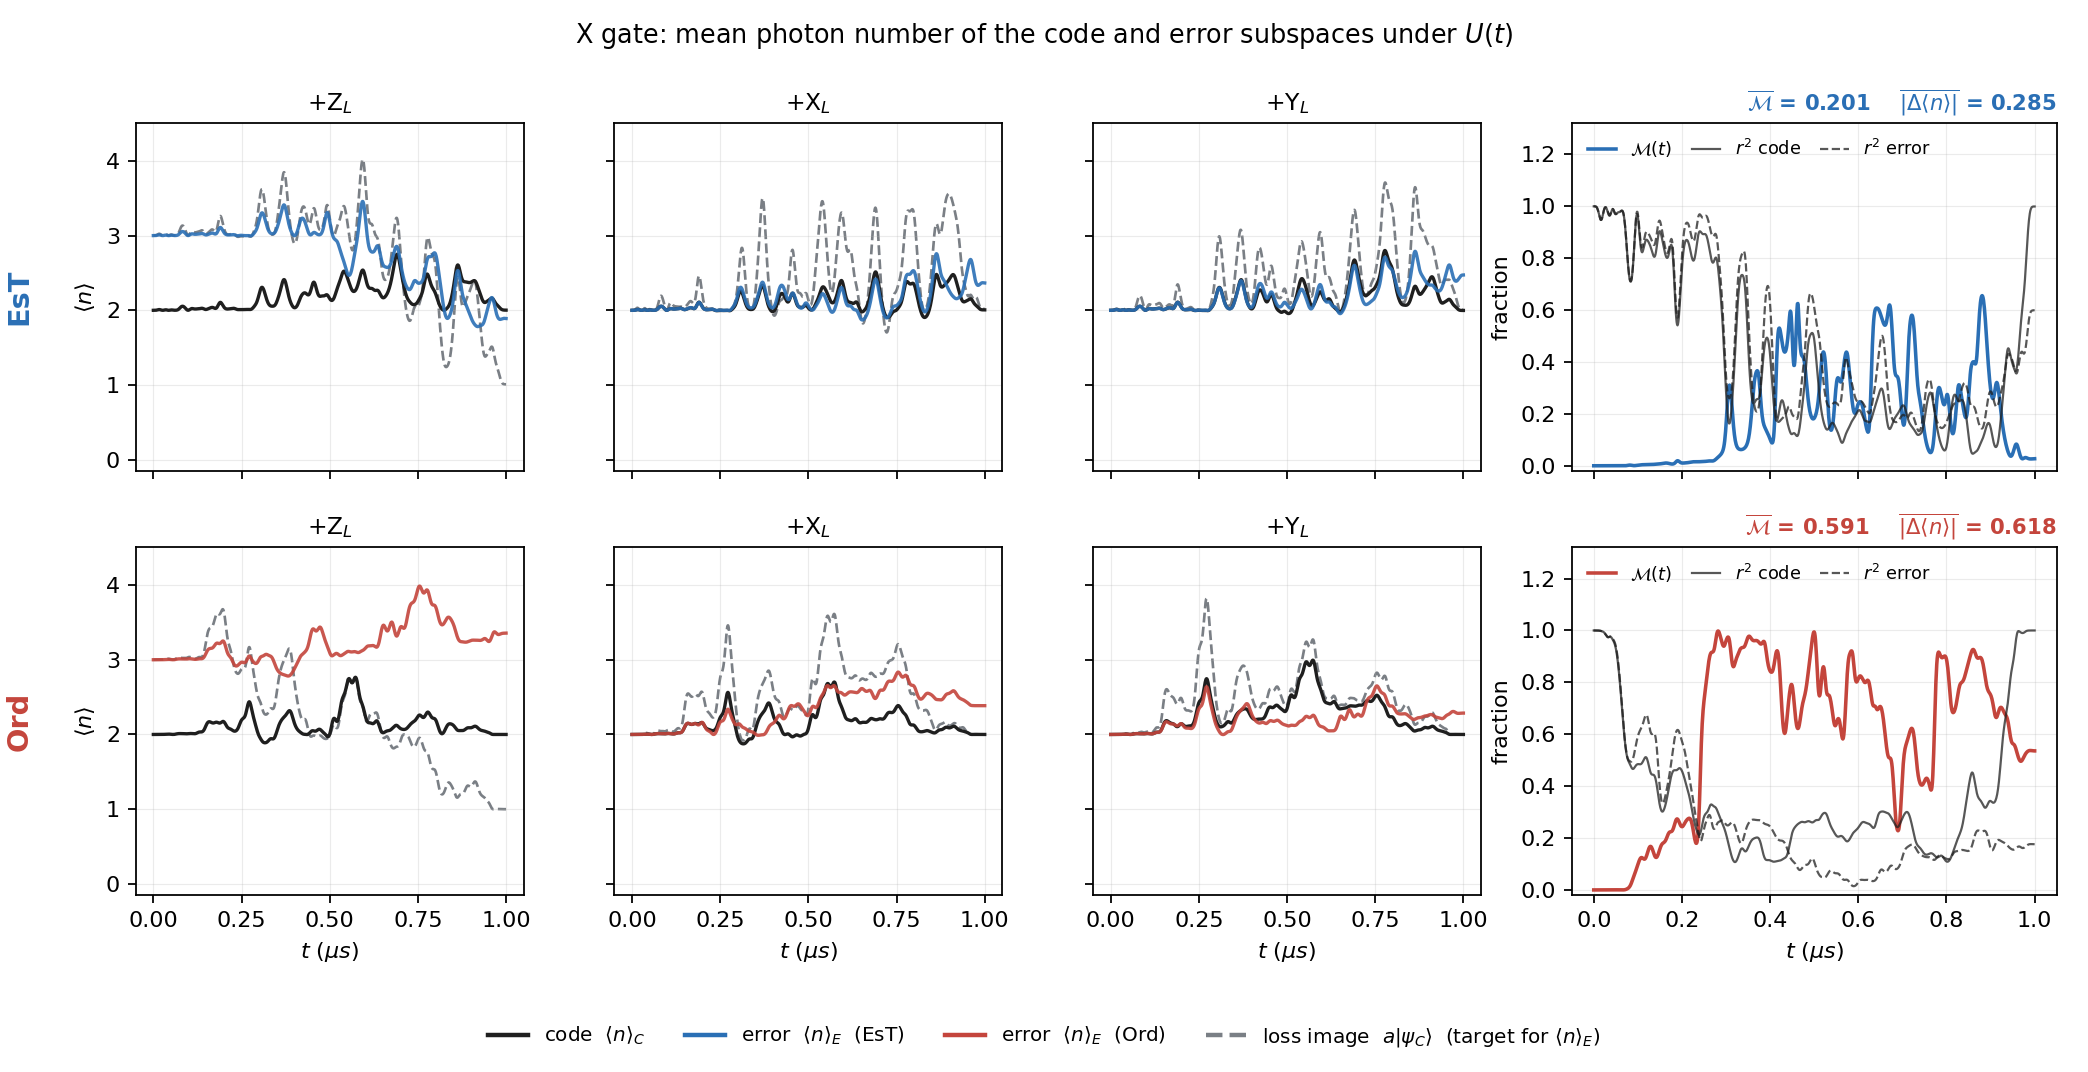

In [9]:
show(FIG1A["X"], width=900)

**Figure 1a. X gate, mean photon number by subspace, EsT (top row) vs Ord (bottom row).**
Three Bloch cardinals per row ($+Z_L$, $+X_L$, $+Y_L$) plus the map-mismatch panel: black is
the code state, grey is the loss-image target, and colour is the error state.

**Interpretation.** In the $+Z_L$ panel the Ord error state climbs away from its target and
stays there, while the EsT error state tracks the grey curve across most of the gate. Every
code curve starts at exactly $\langle n\rangle = 2$, and that is fixed by the code, not the
pulse, since both code words carry $\langle n\rangle = 2$ and $\langle 0_L|n|1_L\rangle = 0$
(Table 2), so no superposition of them can start anywhere else. The error cardinals do not
share that uniformity: they start split 3 / 1 / 2 / 2 / 2 / 2 over
$+Z$ / $-Z$ / $+X$ / $-X$ / $+Y$ / $-Y$, since $|0_E\rangle = |3\rangle$ and
$|1_E\rangle = |1\rangle$ carry different photon numbers.

The right-hand panel is $\mathcal{M}(t)$, $r^2_{\mathrm{code}}$, $r^2_{\mathrm{error}}$ as
defined above. $1 - r^2$ is not leakage in the usual sense:
$|0_L\rangle = (|0\rangle+|4\rangle)/\sqrt2$ has its two Fock components dephase under Kerr
and rotate toward $(|0\rangle-|4\rangle)/\sqrt2$, which costs weight without leaving
$\{0,2,4\}$. The error span $\{|3\rangle, |1\rangle\}$ has no internal superposition, so it
is invariant under drift alone.


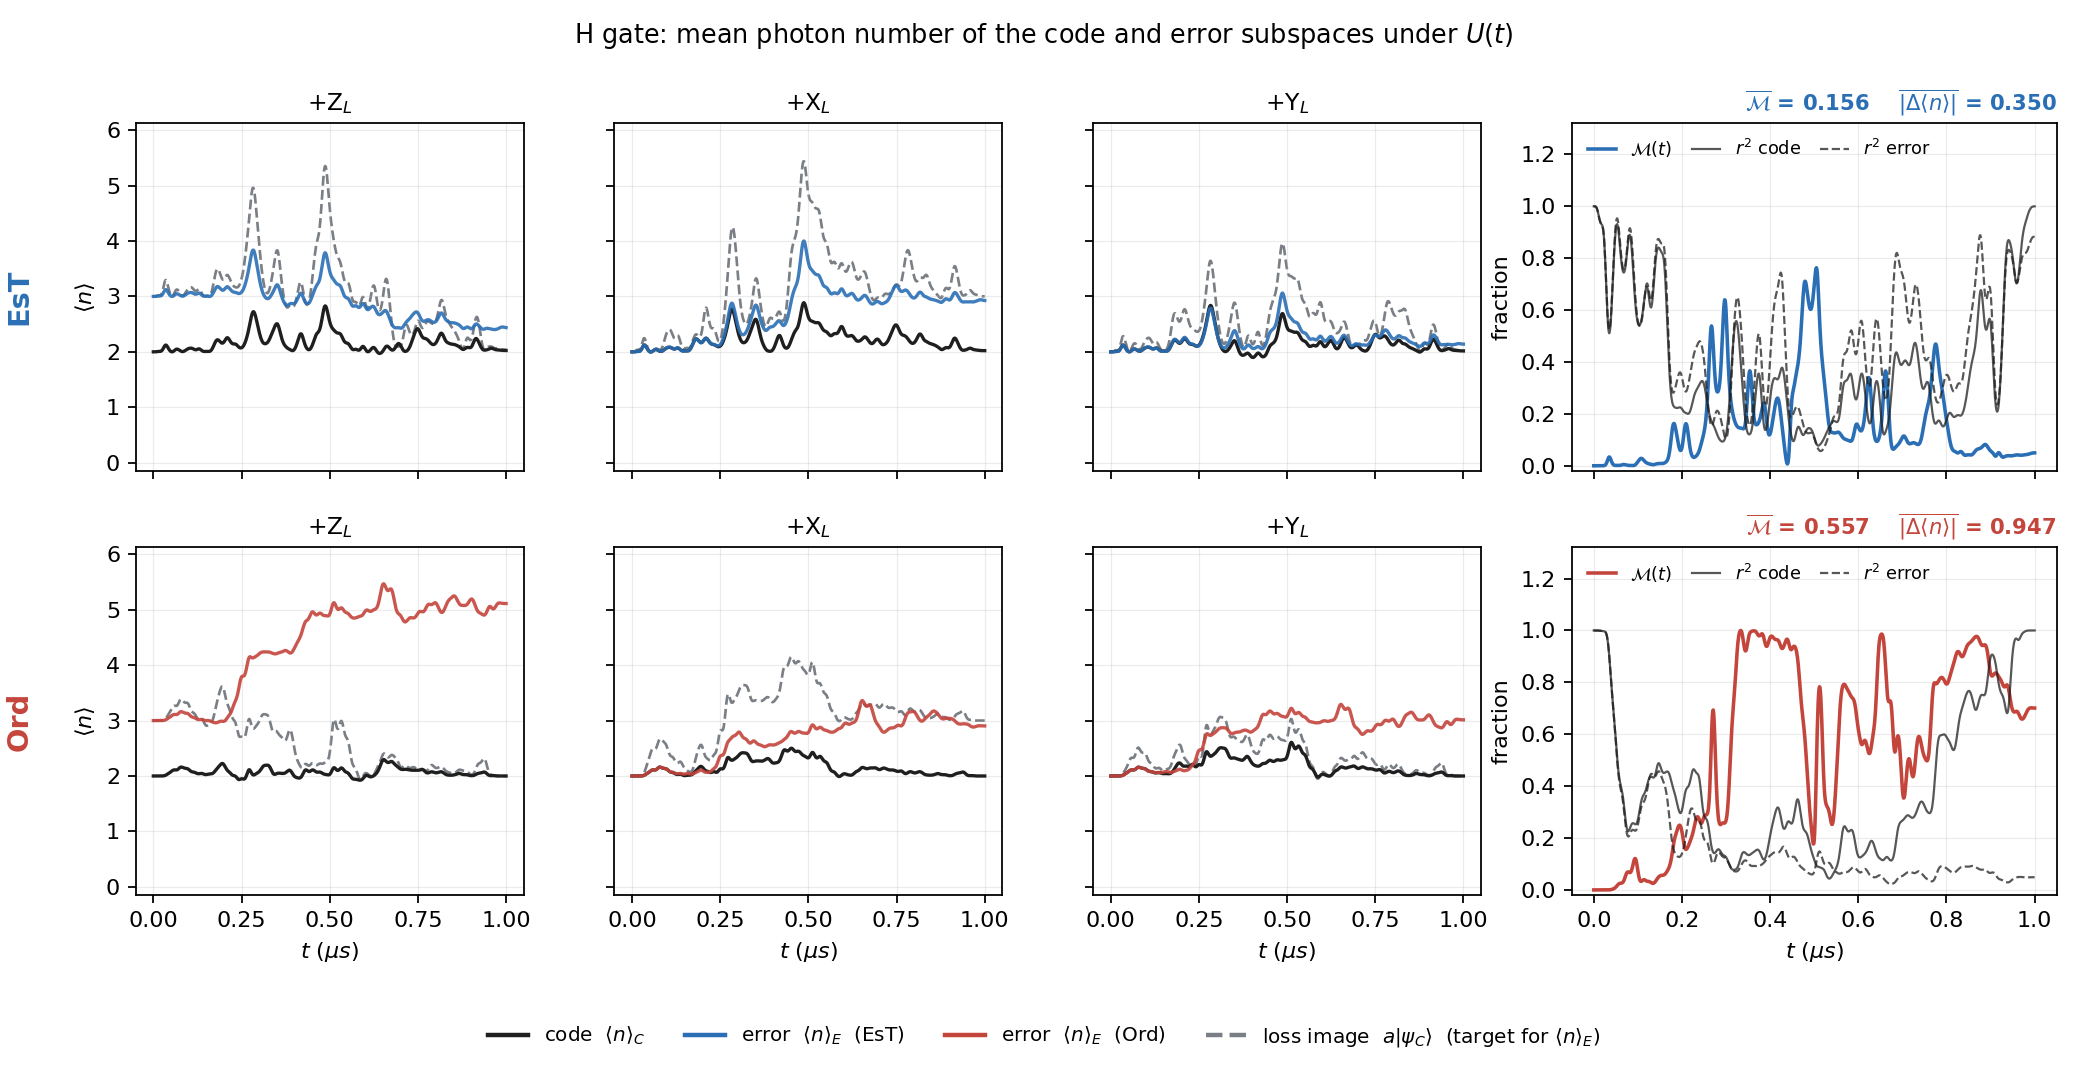

In [10]:
show(FIG1A["H"], width=900)

**Figure 1b. H gate, same axes and cardinals as Figure 1a.** The separation is visibly
wider here: the Ord error state's excursion is larger, and the EsT error state hugs its
target more closely, the qualitative picture behind the H-vs-X numbers in [§6.1](#6.1).


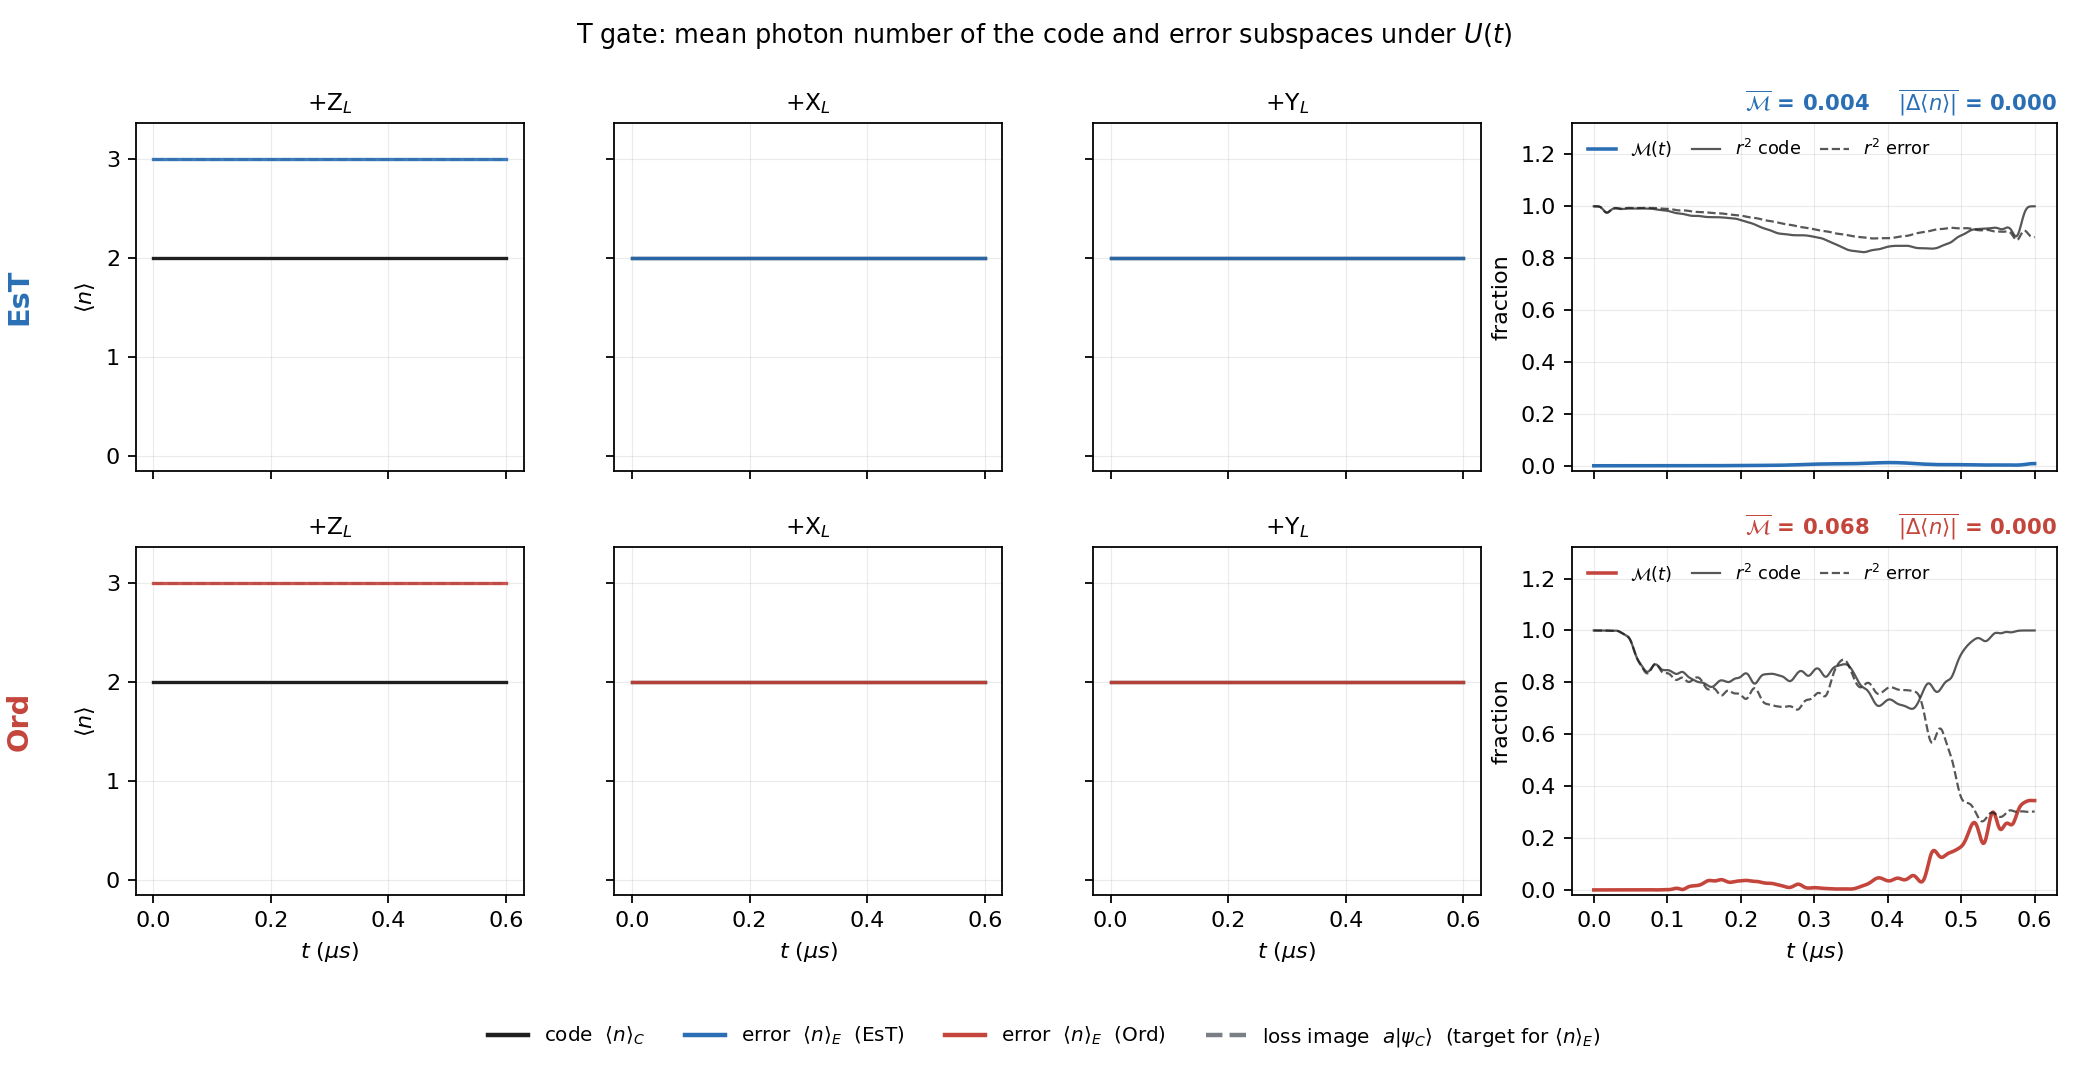

In [11]:
show(FIG1A["T"], width=900)

**Figure 1c. T gate, same axes.** T does not drive the cavity at all (`CONTROL_MASK`), so
every code cardinal's $\langle n\rangle$ curve sits flat at exactly $2$ for *both* variants:
there is no cavity-driven Kerr rotation to see here the way there is for X/H, since a
transmon-only drive cannot move photon number. That flatness also makes
$\overline{|\Delta\langle n\rangle_E|}$ machine-zero for T/Ord as well as T/EsT (Table 8):
this particular diagnostic is trivially satisfied by any transmon-only pulse and carries
none of the transparency signal it carries for X/H. T's transparency shows up in the
map-mismatch panel instead: $\mathcal{M}(T)$ is $8.3\times10^{-3}$ for EsT against
$3.4\times10^{-1}$ for Ord, a 42x gap at the endpoint, wider than either X's or H's own
separation.


In [12]:
sub = pd.concat([
    pd.read_csv(os.path.join(TABLE_DIR,
        "est_fig1a_subspace" + ("" if g == "X" else f"_{g}") + ".csv"))
    for g in GATES], ignore_index=True)

KEYS = {"nbar_track_err_mean": "mean |<n>_E - <n>_loss|",
        "mismatch_mean": "mean M(t)", "mismatch_final": "M(T)",
        "nbar_err_peak": "peak <n>_E"}
view = sub[["gate", "variant"] + list(KEYS)].rename(columns=KEYS)
display(view.style.format({v: "{:.3f}" for v in KEYS.values()}).hide(axis="index"))

print("\nOrd : EsT ratios (higher = bigger EsT advantage)")
for g in GATES:
    e = sub[(sub.gate == g) & (sub.variant == "est")].iloc[0]
    o = sub[(sub.gate == g) & (sub.variant == "ord")].iloc[0]
    print(f"  {g}:  <n> tracking {o.nbar_track_err_mean / e.nbar_track_err_mean:5.2f}x    "
          f"mean M {o.mismatch_mean / e.mismatch_mean:5.2f}x    "
          f"M(T) {o.mismatch_final / e.mismatch_final:5.1f}x")

gate,variant,mean |_E - _loss|,mean M(t),M(T),peak _E
X,est,0.285,0.201,0.027,3.457
X,ord,0.618,0.591,0.536,3.986
H,est,0.350,0.156,0.050,4.000
H,ord,0.947,0.557,0.701,5.469
T,est,0.000,0.004,0.008,3.000
T,ord,0.000,0.068,0.344,3.000



Ord : EsT ratios (higher = bigger EsT advantage)
  X:  <n> tracking  2.17x    mean M  2.94x    M(T)  19.8x
  H:  <n> tracking  2.70x    mean M  3.57x    M(T)  14.1x
  T:  <n> tracking  0.63x    mean M 17.99x    M(T)  41.6x


**Table 8. Subspace-trace summary, all three gates.** $\overline{|\Delta\langle n\rangle|}$
is the time-averaged gap between the error curve and its loss-image target, the quantity
Figure 1 plots. $\mathcal{M}$ is the map-level mismatch.

**What $\langle n\rangle$ can't show.** $H_0$ is a function of the number operators alone,
so $[H_0, n] = 0$ and $\langle n\rangle$ is *exactly* conserved under drift, so every feature
in these curves is drive-induced. That conservation also means $\langle n\rangle$ is
**blind to App. A's obstruction**: free Kerr evolution drives $\eta$ away from zero while
leaving all three photon-number curves flat, since it only rearranges phases within a fixed
photon distribution. Two states can share $\langle n\rangle$ to machine precision and still
be orthogonal. **T makes this literal, not just a caveat**: since it never drives the
cavity, $\overline{|\Delta\langle n\rangle_E|}$ sits at the floating-point floor for *both*
variants, so the `nbar_track_err_mean` ratio printed for T is noise on noise: read
$\mathcal{M}$ for T's transparency signal instead.

So $\langle n\rangle_E = \langle n\rangle_{\mathrm{loss}}$ is **necessary for
transparency, not sufficient**. That is why the figure pairs the $\mathcal{M}$ panel with
the photon-number panels, and why the sufficient statements, Eqs. 6--8, get their own
section next. The blindness above is pinned by `test_grape_jax.SubspaceEvolutionTest`.

> $\mathcal{M}$ and $\overline{|\Delta\langle n\rangle|}$ are this module's constructions,
> not the paper's printed metrics ([§2.3](#2.3), deviation 3); their ratios are
> meaningful, but their absolute values are not.


<a id="5"></a>
# 5. Results II: the three transparency metrics

The paper's Eqs. 6--8, **transcribed** in `EST/diagnostics.py` and evaluated on the eigh
propagator rather than the JAX one that trained the pulses:

| metric | what it tests | range | source |
|---|---|---|---|
| $\Delta_{\mathrm{QEC}}(t)$ | instantaneous Knill--Laflamme validity of the *evolved* code space for the error set $\{I, a\}$ | $\ge 0$ | Eq. 6, via App. A Eqs. A8--A11 |
| $L_{E_j}(t)$ | how much of the evolved error state has left the *instantaneous* error space | $[0,1]$ | Eq. 7 verbatim |
| $\eta_{E_j,\psi}(t)$ | distance between the code and projected-error Bloch vectors | $[0,2]$ | Eq. 8 verbatim |

Because these are transcriptions rather than reconstructions, **both the absolute values and
the EsT:Ord ratios are comparable to the paper** — see [§2.3](#2.3) for the one interpretive
choice that remains, and [§10](#10) for the comparison against the published Fig. 1e.

Three things a reader of the pre-transcription version of this notebook must unlearn:

* **$L \le \eta$ no longer holds by construction.** Eq. 8 projects the error state into
  $E_j(t)$ and renormalizes *before* comparing, so it is deliberately blind to the leakage
  $L$ measures. The old $[0,1]$ state infidelity was not, which is what made the inequality
  automatic.
* **$\mathrm{mean}(\eta) \ne 1 - F_{\mathrm{ET}}$.** $\eta$ is no longer the $C_2$ integrand.
  That integrand is now `diagnostics.c2_integrand`, which exists only to cross-check the numpy
  and JAX code paths ([§7](#7)) and is not a transparency metric.
* **$\eta$ is state-dependent and the paper plots one state.** Fig. 1f of the paper is computed
  for $|0_L\rangle$ alone. Both that trace and the six-cardinal mean are reported below; they
  are not interchangeable, and for T they differ qualitatively.


In [13]:
if REGENERATE_FIGURES:
    for g in GATES:
        diagnostics.main(gate=g, scale="both")
else:
    print("REGENERATE_FIGURES=False, using the figures already on disk")

FIG1DEF = {g: os.path.join(FIG_DIR, "fig1def_est_vs_ord"
                           + ("" if g == "X" else f"_{g}") + "_linear.png") for g in GATES}


=== X / est ===
  C1 fidelity (eigh re-score, n_c=20) : 0.999285
  per-cardinal                        : 0.9995 0.9991 0.9993 0.9993 0.9993 0.9993
  max active Fock level (>1% pop)     : 9
  truncation scan                     : n_c=16:0.99928  n_c=18:0.99929  n_c=20:0.99929  n_c=22:0.99929  n_c=24:0.99929  n_c=28:0.99929
  truncation spread                   : 8.03e-06   OK
  Eqs. 6-8, time-averaged             : dQEC=1.5607e-01  L=2.5751e-01  eta(|0_L>)=1.6879e-01  eta(avg)=2.0872e-01

=== X / ord ===
  C1 fidelity (eigh re-score, n_c=20) : 0.999999
  per-cardinal                        : 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000
  max active Fock level (>1% pop)     : 8
  truncation scan                     : n_c=16:1.00000  n_c=18:1.00000  n_c=20:1.00000  n_c=22:1.00000  n_c=24:1.00000  n_c=28:1.00000
  truncation spread                   : 1.29e-09   OK
  Eqs. 6-8, time-averaged             : dQEC=4.8080e-01  L=7.3992e-01  eta(|0_L>)=1.1119e+00  eta(avg)=1.1853e+00

--- EsT vs Or

/Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/EST/diagnostics.py:457: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(frameon=False)


figure (linear) -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig1def_est_vs_ord_T_linear.png
table  -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/tables/est_fig1_metrics_T.csv


The cell above also wrote the log-axis versions (`fig1def_est_vs_ord[_H][_T].png`), which are
the paper's own view. The **linear** axes are shown below instead: $\Delta_{\mathrm{QEC}}$ and
$L$ sit at $O(0.1\text{--}1)$ and $\eta$ ranges over the full $[0,2]$, so a log axis
exaggerates the separation by compressing the region the curves actually occupy.

Panel (f) carries two traces per variant: $|0_L\rangle$ solid, matching the paper's Fig. 1f,
and the six-cardinal mean faint.


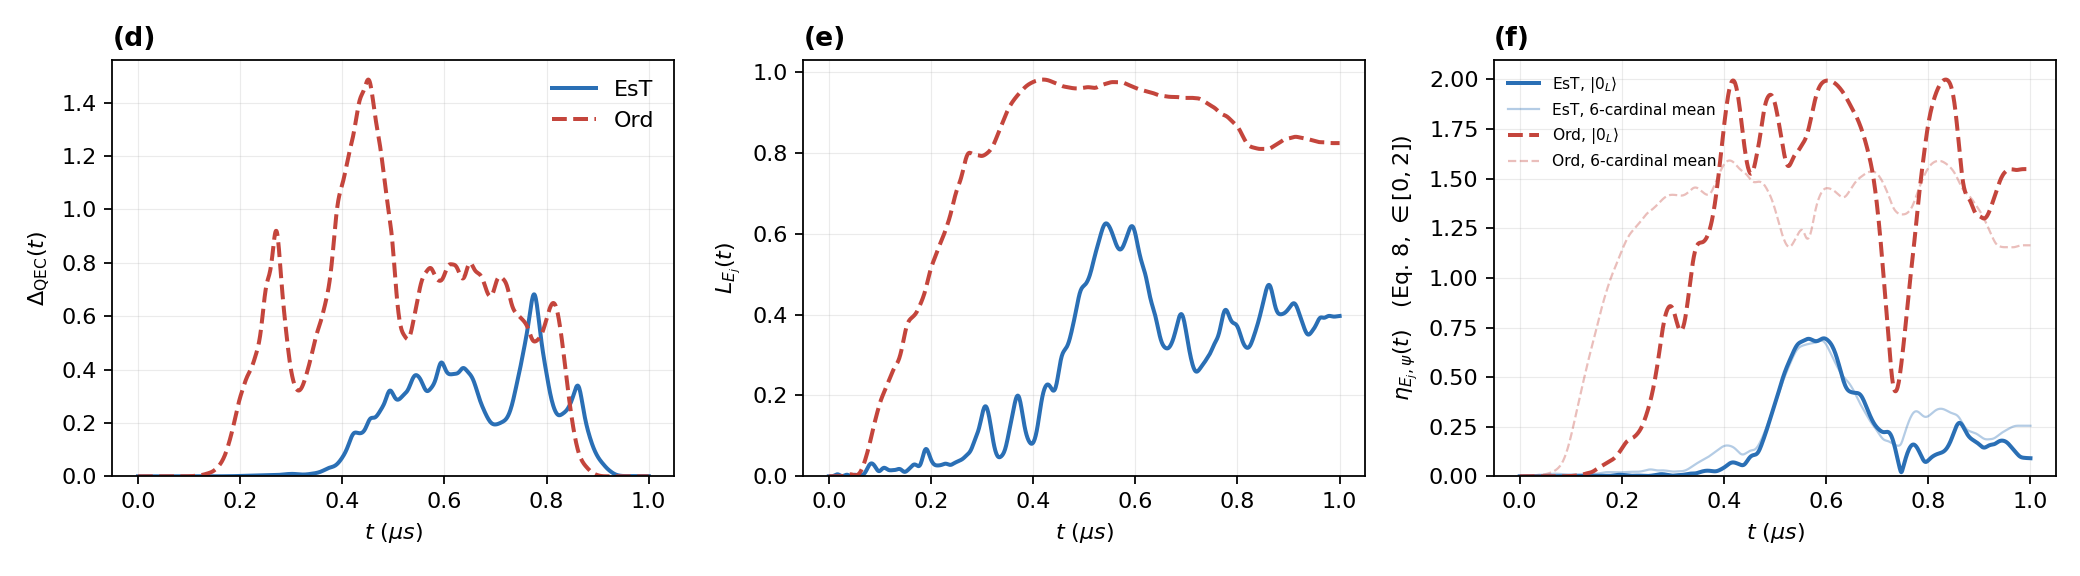

In [14]:
show(FIG1DEF["X"], width=900)

**Figure 2a. X gate: $\Delta_{\mathrm{QEC}}$, $L_{E_j}$, $\eta_{E_j,\psi}$ against time, EsT
(blue) vs Ord (red dashed), linear axes.** Both pulses are 1.0 us. Panels (d) and (e) are
averaged over the six cardinals; panel (f) shows $|0_L\rangle$ solid and the six-cardinal mean
faint.

**Interpretation.** EsT sits below Ord across the whole gate on all three metrics — by 3.08x on
$\Delta_{\mathrm{QEC}}$, 2.87x on $L$ and 6.59x on $\eta(|0_L\rangle)$ in the time-average
(Table 9) — and the curves flatten rather than descending to zero. That floor is App. A
([§1.3](#1.3)) and is expected.

**Ord's $\eta$ reaches the ceiling.** The red trace in panel (f) touches $\eta = 2$, the maximum
a Bloch-vector distance can take, at several points: the Ord gate drives the error state to the
*antipode* of where the code state sits. This is the clearest single statement in the notebook
of what error transparency buys, and it was invisible under the old $[0,1]$ normalization.

**The $\Delta_{\mathrm{QEC}}$ endpoint is an artifact, not a result.** Both curves dive to
near-zero at $t = T$ ($4.0\times10^{-9}$ Ord, $8.8\times10^{-4}$ EsT), purely because a gate that
lands on the ideal code words has zero Knill--Laflamme violation by construction, whatever it did
on the way. Read this panel mid-gate, where transparency is the property at issue.


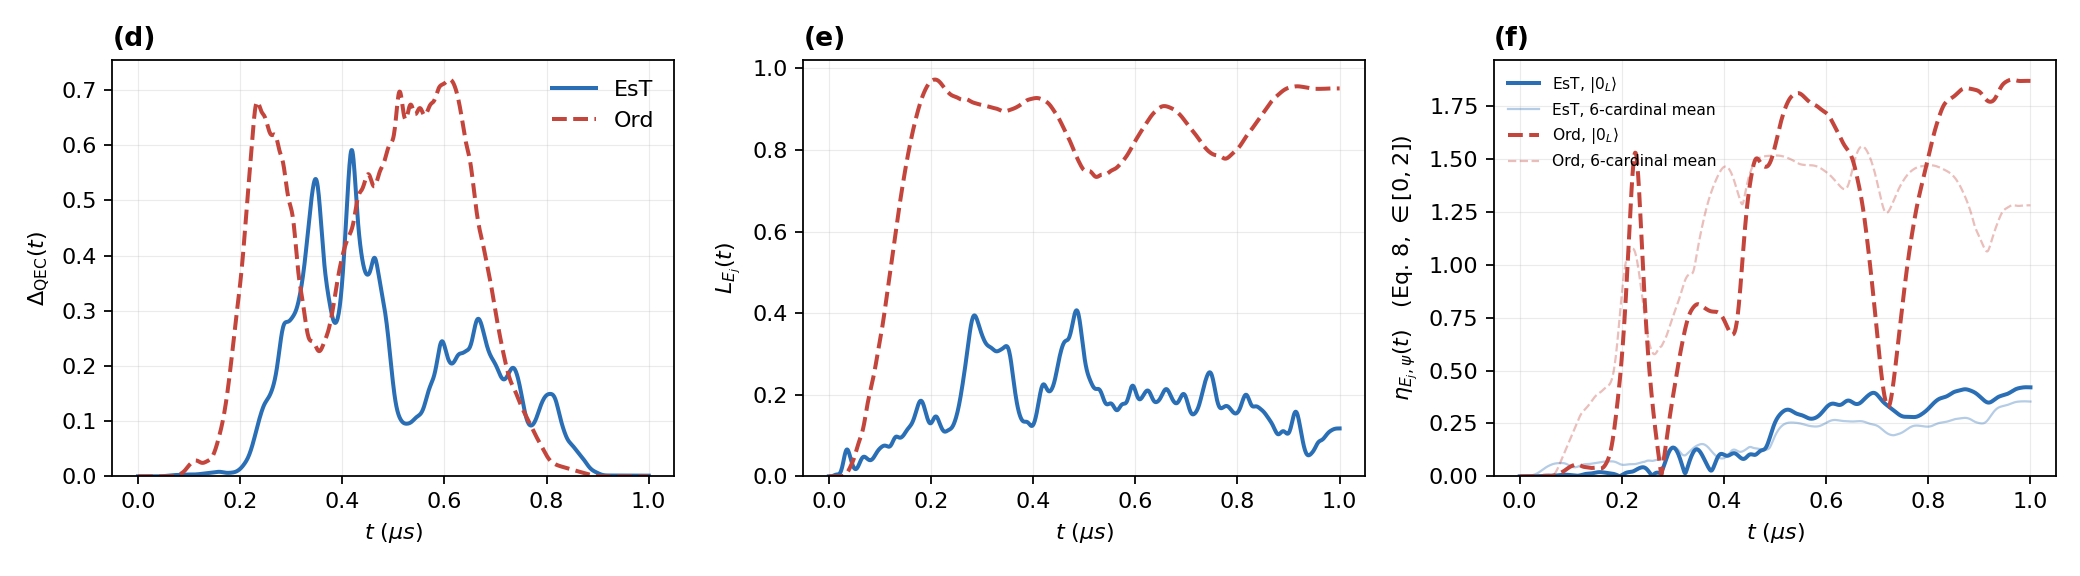

In [15]:
show(FIG1DEF["H"], width=900)

**Figure 2b. H gate, same axes.** $L$ separates further than Figure 2a's (4.52x against 2.87x)
and the EsT curves are flatter: the H pulse holds its transparency more evenly across the gate
rather than degrading toward the end, and it ends at $L(T) = 0.118$ against X's $0.396$.
$\Delta_{\mathrm{QEC}}$ goes the other way — H's 1.90x is the weakest of the three gates, against
X's 3.08x — so the H advantage is not uniform across metrics.


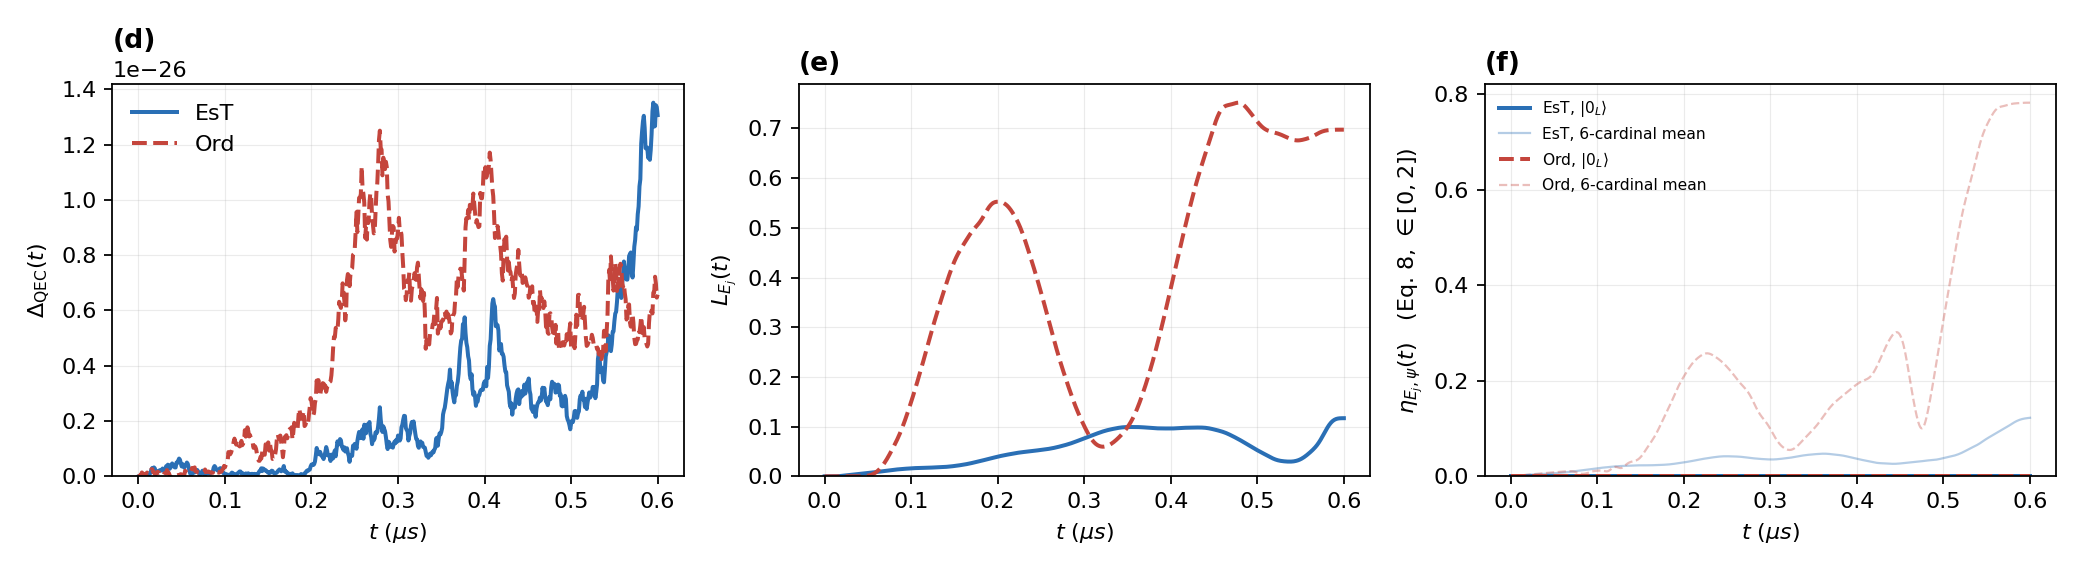

In [16]:
show(FIG1DEF["T"], width=900)

**Figure 2c. T gate, same axes.** Both variants sit far below X/H's, and two of the three panels
collapse entirely.

**$\Delta_{\mathrm{QEC}}$ and $\eta(|0_L\rangle)$ are at machine zero for *both* variants**
($10^{-27}$ and $10^{-14}$ respectively), so no ratio is defined and none is reported. T is a
diagonal phase gate driven through the transmon alone: it does not mix Fock levels, so the
Knill--Laflamme matrices stay proportional to $P_C$ exactly, and the $|0_L\rangle$ Bloch vector
is invariant in both subspaces. Under Eq. 8 that is *exact* transparency on this trace — not a
small number, an identically zero one.

This is a qualitative change from the pre-transcription version of this notebook, which reported
$\eta = 0.055$ for T/EsT and a 7.12x ratio. The old metric compared states and so counted a
Fock-dependent phase that Eq. 8 quotients out. Do not reconcile the two numbers; they measure
different things.

**What survives is $L$ and the six-cardinal $\eta$**, at 6.97x and 5.81x — real separations,
but between two *easy* baselines. T/Ord is already far more transparent than X/H's Ord ever
reaches ($L = 0.377$ against $0.740$ and $0.780$) simply because a diagonal phase gate has much
less room to scramble the error space in the first place. The old 80.97x headline on $L$ was an
artifact of the rank-2 basis bug ([§10](#10), limitation 3) and does not survive the fix. See
[§6.1](#6.1) and limitation 5.


In [17]:
met = pd.concat([
    pd.read_csv(os.path.join(TABLE_DIR,
        "est_fig1_metrics" + ("" if g == "X" else f"_{g}") + ".csv"))
    for g in GATES], ignore_index=True)

# F_ET is the C2 training value. Its eigh-path twin is c2_integrand_mean, NOT eta:
# since Eqs. 6-8 were transcribed, eta is Eq. 8's Bloch distance and a different
# quantity from C2. See section 7, check 4.
met["F_ET"] = 1.0 - met["c2_integrand_mean"]
view = met[["gate", "variant", "F1", "F_ET", "delta_qec_mean", "leakage_mean",
            "eta_0L_mean", "eta_avg_mean", "max_active_fock", "trunc_spread"]]
display(view.style.format({"F1": "{:.6f}", "F_ET": "{:.4f}", "delta_qec_mean": "{:.4f}",
                           "leakage_mean": "{:.4f}", "eta_0L_mean": "{:.4f}",
                           "eta_avg_mean": "{:.4f}",
                           "trunc_spread": "{:.2e}"}).hide(axis="index"))

print("\nOrd : EsT ratios (higher = bigger EsT advantage)")

def _ratio(e_val, o_val):
    """NaN where both variants sit at numerical zero: the quotient would be a
    ratio of rounding error, which a reader would otherwise rank on. T hits this
    on Delta_QEC and on eta(|0_L>)."""
    return float("nan") if max(e_val, o_val) < 1e-12 else o_val / e_val

ratio_rows = []
for g in GATES:
    e = met[(met.gate == g) & (met.variant == "est")].iloc[0]
    o = met[(met.gate == g) & (met.variant == "ord")].iloc[0]
    ratio_rows.append({"gate": g,
                       "F1 EsT": e.F1, "F1 Ord": o.F1,
                       "infidelity cost": (1 - e.F1) - (1 - o.F1),
                       "Delta_QEC": _ratio(e.delta_qec_mean, o.delta_qec_mean),
                       "L": _ratio(e.leakage_mean, o.leakage_mean),
                       "eta (|0_L>)": _ratio(e.eta_0L_mean, o.eta_0L_mean),
                       "eta (6-card)": _ratio(e.eta_avg_mean, o.eta_avg_mean),
                       "F_ET EsT/Ord": (1 - e.c2_integrand_mean) / (1 - o.c2_integrand_mean)})
display(pd.DataFrame(ratio_rows).style.format(
    {"F1 EsT": "{:.6f}", "F1 Ord": "{:.6f}", "infidelity cost": "{:.2e}",
     "Delta_QEC": "{:.2f}x", "L": "{:.2f}x", "eta (|0_L>)": "{:.2f}x",
     "eta (6-card)": "{:.2f}x", "F_ET EsT/Ord": "{:.2f}x"},
    na_rep="n/a (both ~0)").hide(axis="index"))

gate,variant,F1,F_ET,delta_qec_mean,leakage_mean,eta_0L_mean,eta_avg_mean,max_active_fock,trunc_spread
X,est,0.999285,0.7300,0.1561,0.2575,0.1688,0.2087,9,8.03e-06
X,ord,0.999999,0.1940,0.4808,0.7399,1.1119,1.1853,8,1.29e-09
H,est,0.999675,0.8175,0.1513,0.1724,0.1983,0.1721,10,6.88e-07
H,ord,0.999999,0.1646,0.2873,0.7797,1.0289,1.0680,8,9.70e-09
T,est,0.999982,0.9452,0.0000,0.0541,0.0000,0.0368,4,7.48e-14
T,ord,1.000000,0.6100,0.0000,0.3772,0.0000,0.2137,4,2.79e-14



Ord : EsT ratios (higher = bigger EsT advantage)


gate,F1 EsT,F1 Ord,infidelity cost,Delta_QEC,L,eta (|0_L>),eta (6-card),F_ET EsT/Ord
X,0.999285,0.999999,7.14e-04,3.08x,2.87x,6.59x,5.68x,3.76x
H,0.999675,0.999999,3.23e-04,1.90x,4.52x,5.19x,6.20x,4.97x
T,0.999982,1.000000,1.83e-05,n/a (both ~0),6.97x,n/a (both ~0),5.81x,1.55x


**Table 9. Headline metrics for all six pulses, plus the EsT:Ord ratios.** Time-averaged over
the gate, and — except for $\eta(|0_L\rangle)$ — over the six cardinals; lower is better except
for the two fidelities. A ratio reads `n/a` where both variants sit below $10^{-12}$, since the
quotient would then be a ratio of rounding error.

Five readings.

**The fidelity cost of transparency is small and real, and smallest for T.** EsT gives up
$7\times10^{-4}$ (X), $3\times10^{-4}$ (H), and $1.8\times10^{-5}$ (T) of ordinary fidelity
against a control that reaches $\sim 1.000000$ in every case. That is the intended trade, not a
defect: `ord` optimizes $C_1$ alone and drives it as far as L-BFGS-B can, while `est` spends part
of the same budget on $C_2$ and $C_3$. This row is unchanged by the transcription — $F_1$ never
depended on Eqs. 6--8.

**On X and H, transparency buys 2.9--4.5x on $L$ and 5.2--6.6x on $\eta$.** The two error-space
metrics now agree on the direction and disagree on the size, which is informative rather than
awkward: $\eta$ is leakage-insensitive by construction, so the gap between the two ratios is a
statement about *where* the Ord gate fails. Ord loses more on trajectory than it does on
containment.

**$\Delta_{\mathrm{QEC}}$ has stopped being the odd one out.** Under the pre-transcription
normalization it moved only 1.3--1.9x while everything else moved 3--4.6x, and that discrepancy
was itself quoted as evidence in [§6.1](#6.1). Unnormalized, per App. A, it reads 3.08x on X and
1.90x on H — the same order as the other two metrics. **The old 1.3--1.9x range was an artifact
of dividing by $\bar{n}(t)$, not a property of the pulses.**

**T is not a comparison of the same kind, and now says so.** Two of its three panels are at
machine zero for both variants ([§5c](#5)), so $\Delta_{\mathrm{QEC}}$ and $\eta(|0_L\rangle)$
report no ratio at all. What remains — 6.97x on $L$, 5.81x on the six-cardinal $\eta$ — is a gap
between two baselines that are both far more transparent than X/H's to begin with. The
pre-transcription 80.97x on $L$ does not survive the rank-2 basis fix ([§10](#10),
limitation 3); it was measuring a spurious projection, not a property of T.

**H beats X on $F_{\mathrm{ET}}$ and $L$ — but no longer on everything.** H reaches
$F_{\mathrm{ET}} = 0.818$ against X's $0.730$ and $L = 0.172$ against $0.258$, at higher $F_1$,
under an identical schedule. But X leads on $\eta(|0_L\rangle)$ ($0.169$ against $0.198$) and on
$\Delta_{\mathrm{QEC}}$ ($3.08$x against $1.90$x). Under the old definitions H led on every
error-space metric, and [§6.1](#6.1)'s reading of the H-vs-X gap was built on that. It is now a
split decision, which weakens the "H simply reaches deeper transparency" framing without
overturning the $F_{\mathrm{ET}}$ gap that framing was originally about. X-vs-H is still the one
controlled, same-$N$, same-schedule comparison here; T runs a shorter gate ($N=600$) with a
transmon-only drive and is not commensurable with either.

> `max_active_fock` differs between X/H's two variants (see [§10](#10), limitation 2) but
> *matches* for T's two variants (4 and 4), so T remains the one gate here where the
> fair-comparison criterion is actually satisfied.


<a id="6"></a>
# 6. Results III: the delivered waveforms

Nothing in `EST/` plots a trained pulse, and `visualization/pulse_viz.plot_pulse_waveforms` is
not reusable here: it is hardcoded to the main pipeline's MHz units and `dt = 0.002`, plots one
pulse per figure, and has no amplitude-cap line or EsT/Ord overlay. The helper below is local to
this notebook.

It plots the **quadrature-pair magnitude** $|\varepsilon| = \sqrt{I^2 + Q^2}$, because that is
the quantity $C_4$ caps, not $I$ and $Q$ separately.

In [18]:
def plot_est_waveforms(u_est, u_ord, gate, dt=device.DT, save_path=None,
                       labels=("EsT", "Ord")):
    """|eps| against the C4 cap for both variants, plus the first pulse's I/Q traces
    underneath. `labels` names the two pulses (section 10 compares two EsT pulses)."""
    N = u_est.shape[0]
    t_ns = np.arange(N) * dt * 1e3
    T_ns = N * dt * 1e3
    # The ramp profile, scaled to the cap for visibility. NOT a ceiling: the envelope
    # multiplies the raw pre-image, which is not itself capped, so |eps| can exceed it.
    envelope = device.ramp_envelope(N, dt) * device.EPS_MAX

    fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
    for row, (lo, name) in enumerate(((0, "cavity"), (2, "transmon"))):
        ax = axes[row, 0]
        ax.plot(t_ns, np.hypot(u_est[:, lo], u_est[:, lo + 1]), color=EST_COLOR, lw=0.9, label=labels[0])
        ax.plot(t_ns, np.hypot(u_ord[:, lo], u_ord[:, lo + 1]), color=ORD_COLOR, lw=0.8,
                ls="--", label=labels[1])
        ax.plot(t_ns, envelope, color="0.45", lw=0.9, ls=":", label="ramp envelope (scaled)")
        ax.axhline(device.EPS_MAX, color="0.15", lw=0.9)
        for x0, x1 in ((0.0, device.RAMP_NS), (T_ns - device.RAMP_NS, T_ns)):
            ax.axvspan(x0, x1, color="0.88", zorder=0)
        ax.set_ylabel(f"|eps_{name[0].upper()}|  (rad/us)")
        ax.set_ylim(0, device.EPS_MAX * 1.18)
        ax.grid(alpha=0.25)
        if row == 0:
            ax.legend(loc="lower center", ncol=3, fontsize=8, framealpha=0.9)
            ax.set_title(f"drive magnitude vs the C4 cap  ({gate} gate)", fontsize=10)

        ax2 = axes[row, 1]
        ax2.plot(t_ns, u_est[:, lo], color=EST_COLOR, lw=0.7, label="I")
        ax2.plot(t_ns, u_est[:, lo + 1], color="#8a5fb0", lw=0.7, label="Q")
        ax2.axhline(0, color="0.6", lw=0.6)
        ax2.set_ylabel(f"{name} I / Q  (rad/us)")
        ax2.grid(alpha=0.25)
        if row == 0:
            ax2.legend(loc="upper right", ncol=2, fontsize=8, framealpha=0.9)
            ax2.set_title(f"{labels[0]} quadratures", fontsize=10)
    for ax in axes[1]:
        ax.set_xlabel("t (ns)")
    fig.suptitle(f"{gate} gate: delivered waveforms   "
                 f"(shaded: {device.RAMP_NS:.0f} ns ramp windows)", fontsize=11)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
        print(f"saved -> {save_path}")
    plt.close(fig)
    return save_path

FIG3 = {}
for g in GATES:
    FIG3[g] = plot_est_waveforms(PULSES[(g, "est")], PULSES[(g, "ord")], g,
                                 save_path=os.path.join(FIG_DIR, f"fig3_waveforms_{g}.png"))

saved -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig3_waveforms_X.png
saved -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig3_waveforms_H.png
saved -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig3_waveforms_T.png


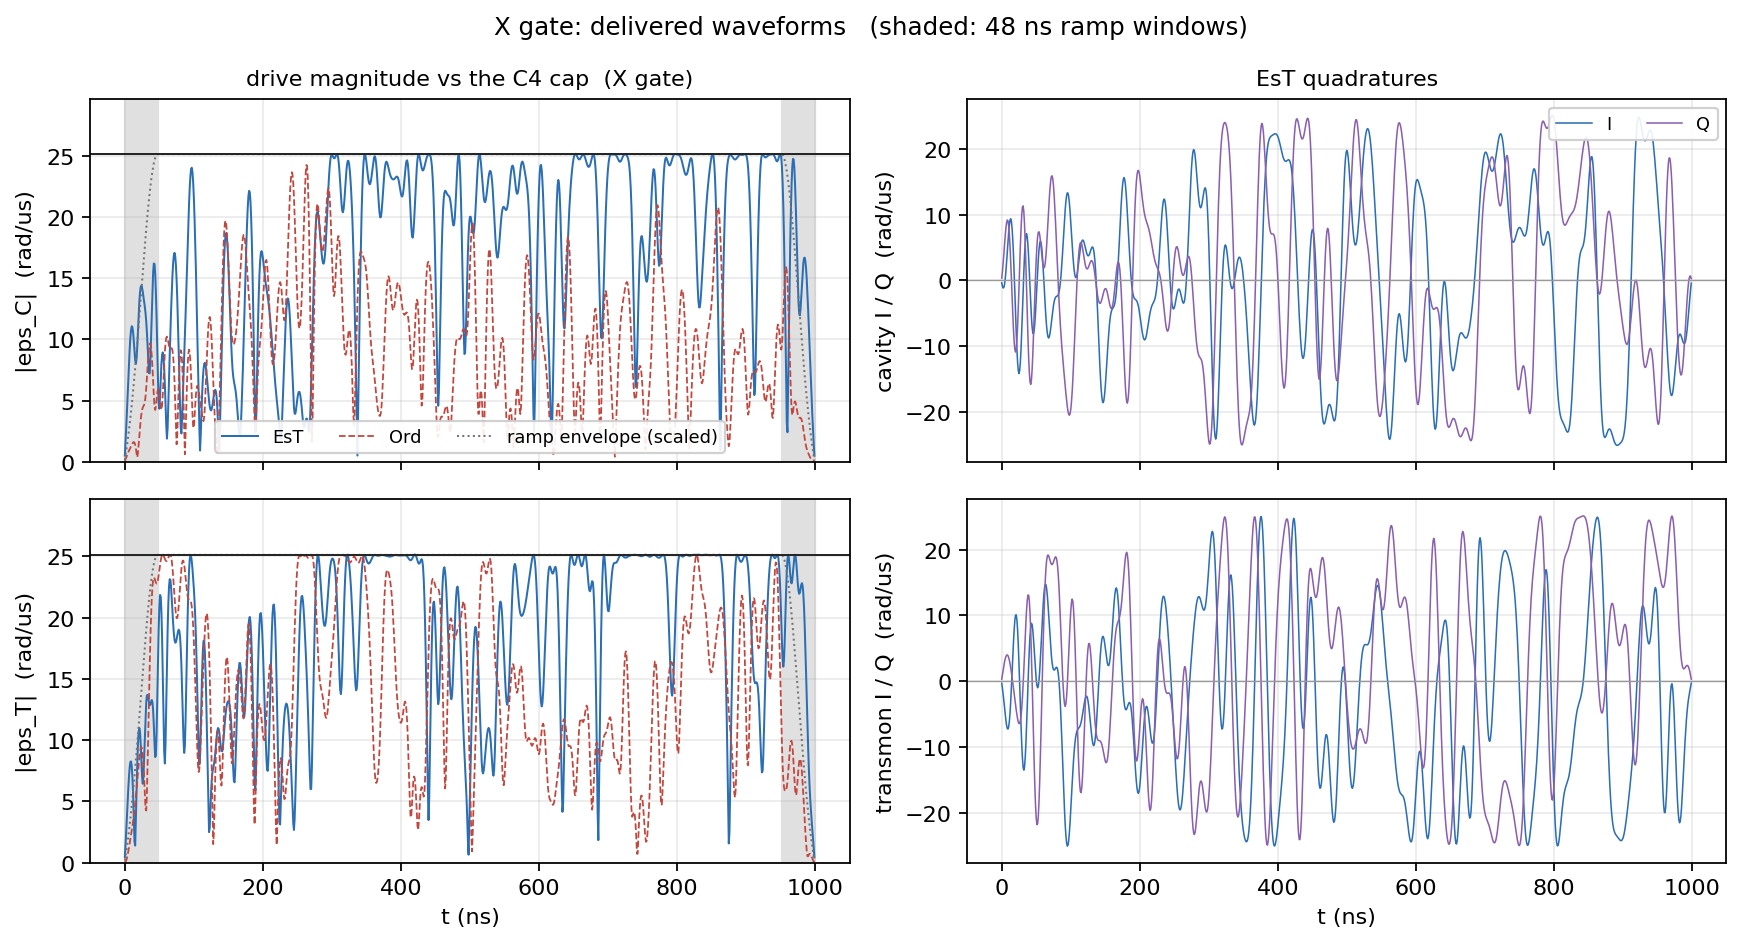

In [19]:
show(FIG3["X"], width=880)

**Figure 3a. X gate: delivered waveforms.** Left column: quadrature-pair magnitude for EsT
(blue) and Ord (red dashed) against the $C_4$ cap (solid black), with the ramp envelope scaled
to the cap for reference (dotted grey). Right column: the EsT pulse's underlying $I$ and $Q$. Shading
marks the 48 ns ramp windows.

**The cap binds for EsT and not for Ord.** The blue trace saturates $\varepsilon_{\max}$
repeatedly on both drives (a bang-bang-flavoured solution, not a smooth one), while the red
Ord trace, especially on the cavity, spends most of the gate well below it. Ord reaches its
$F_1 \approx 1$ without needing the full amplitude budget; EsT needs all of it and then some,
which is the same fact as its 0.2% $C_4$ overshoot in Table 7. This is also why the amplitude
limit has to be $C_4$ and not the L-BFGS-B box ([§2.4](#2.4)): the box constrains the raw
pre-image, and the quantity actually pinned at 25.13 here is a *derived* circular magnitude.

**The dotted curve is the ramp profile, not a bound.** The constraint chain multiplies the
envelope into the pre-image, and the pre-image is not itself capped, so $|\varepsilon|$ can and
does exceed `ramp x eps_max` inside the shaded windows. What the envelope does guarantee is the
taper: both variants go to zero at both ends rather than switching on abruptly.

**EsT and Ord are different waveforms, not perturbations of each other.** The magnitude traces
agree nowhere in detail, consistent with the two objectives landing in different optimizer
basins rather than $C_2$ and $C_3$ nudging the Ord solution. Table 7's systematic differences
(10x the transmon out-of-band energy, 8x the endpoint/mid ratio) are the quantitative form
of the same observation.

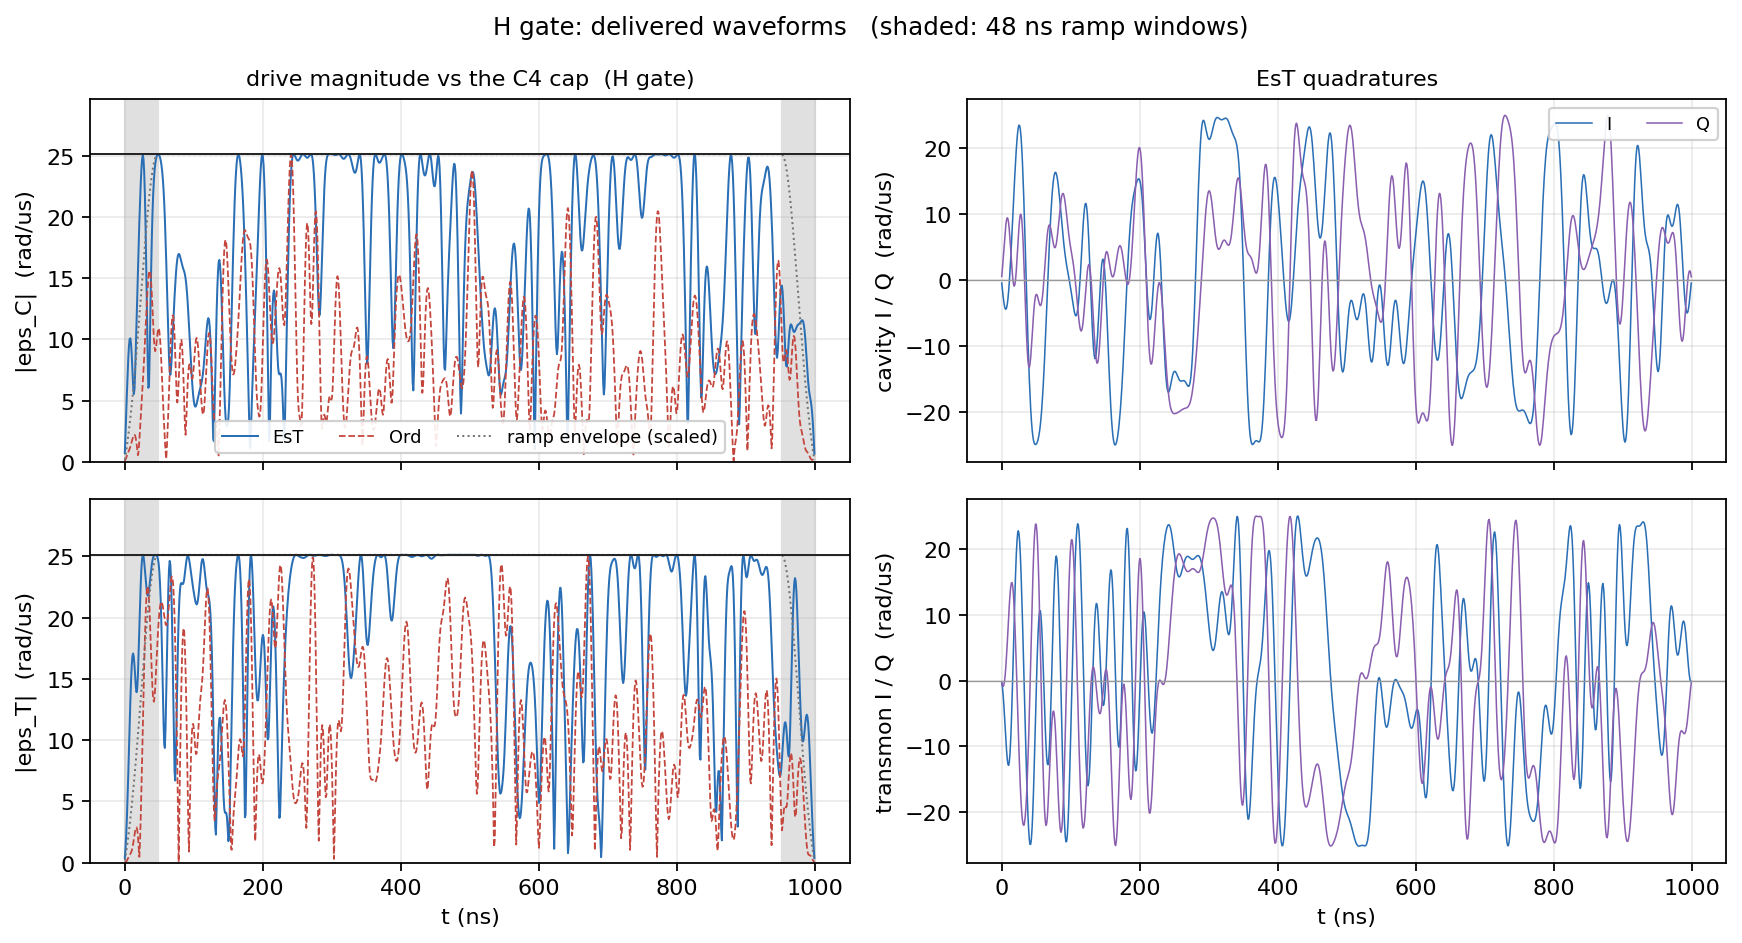

In [20]:
show(FIG3["H"], width=880)

**Figure 3b. H gate, same axes.** Structurally the same picture, slightly more pronounced: the
EsT cavity drive reaches the cap inside the opening ramp window, within the first 30 ns, and
holds it through long stretches of the gate. The H pulses work against the *same*
$\varepsilon_{\max}$, the same $N$, and the same band as X, so the H-vs-X difference in
[§6.1](#6.1) is not a matter of one gate being allowed to drive harder.

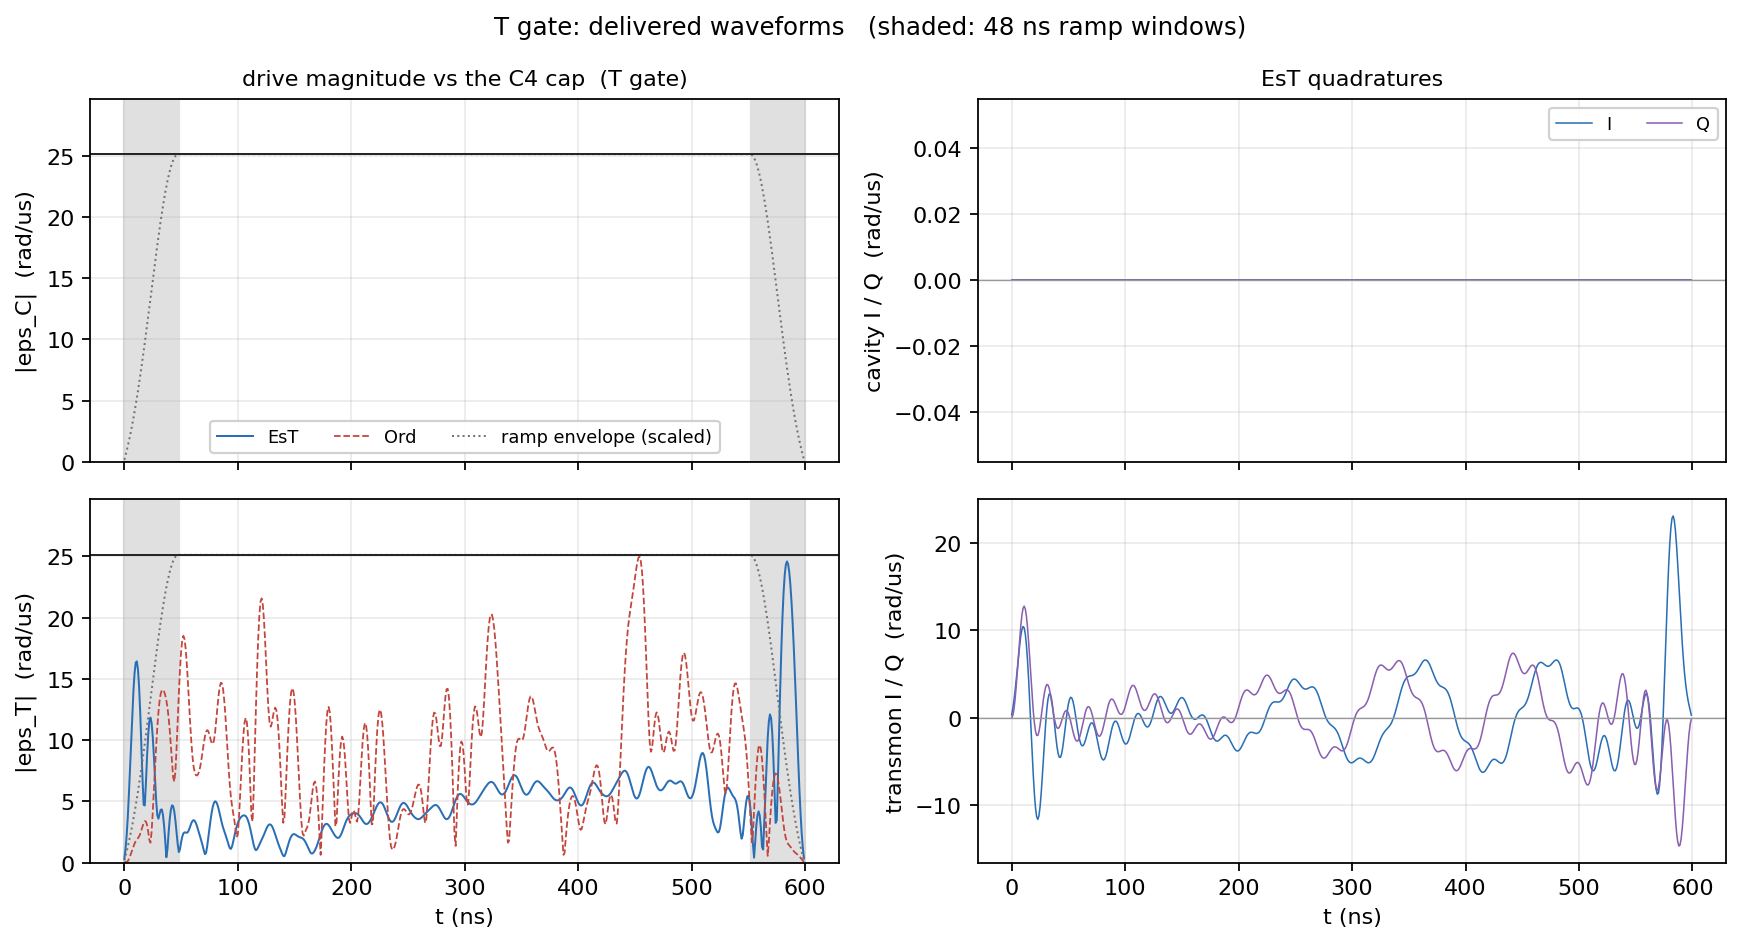

In [21]:
show(FIG3["T"], width=880)

**Figure 3c. T gate: delivered waveforms.** The cavity panels (top row) are exactly zero for
both variants, not approximately but exactly, since `CONTROL_MASK` multiplies those two columns
by 0, which is the clearest possible confirmation that the transmon-only constraint from
[§1.2](#1.2) is doing its job. All of the action is in the bottom row. `ord` converges to a
small, smooth pulse well inside the cap in 16 iterations (Table 6); `est` drives much harder and
noticeably closer to $\varepsilon_{\max}$, and, as Table 7 shows, puts more of that drive
into the ramp windows than X or H's `est` pulses do, which is visible here as amplitude that
does not taper as cleanly toward the shaded edges.

<a id="6.1"></a>
### 6.1 Cross-gate synthesis: the H-vs-X gap, and what the second stage does

In [22]:
rows = []
for g in GATES:
    info = RUNS[(g, "est")]
    nc = str(info["trunc_list"][0])
    for st in info["stages"]:
        t = st["terms"][nc]
        rows.append({"gate": g, "after stage": st["stage"],
                     "F1": 1 - t["c1"], "infidelity": t["c1"],
                     "F_ET": 1 - t["c2"], "C3 (vel. var.)": t["c3"]})
stage = pd.DataFrame(rows)
display(stage.style.format({"F1": "{:.5f}", "infidelity": "{:.2e}",
                            "F_ET": "{:.4f}", "C3 (vel. var.)": "{:.5f}"}).hide(axis="index"))

for g in GATES:
    s1 = stage[(stage.gate == g) & (stage["after stage"] == 1)].iloc[0]
    s2 = stage[(stage.gate == g) & (stage["after stage"] == 2)].iloc[0]
    ord_c3 = RUNS[(g, "ord")]["stages"][-1]["terms"][str(RUNS[(g, "ord")]["trunc_list"][0])]["c3"]
    print(f"{g}:  stage 2 improves infidelity {s1.infidelity/s2.infidelity:5.0f}x, "
          f"moves F_ET by {100*(s2.F_ET-s1.F_ET)/s1.F_ET:+5.1f}%, "
          f"and regresses C3 {s2['C3 (vel. var.)']/s1['C3 (vel. var.)']:5.1f}x "
          f"(Ord sits at {ord_c3:.4f})")

gate,after stage,F1,infidelity,F_ET,C3 (vel. var.)
X,1,0.95706,4.29e-02,0.7290,0.00949
X,2,0.99929,7.15e-04,0.7300,0.14772
H,1,0.96112,3.89e-02,0.8268,0.00630
H,2,0.99968,3.25e-04,0.8175,0.12585
T,1,0.97331,2.67e-02,0.9154,0.01038
T,2,0.99998,1.83e-05,0.9452,0.20231


X:  stage 2 improves infidelity    60x, moves F_ET by  +0.1%, and regresses C3  15.6x (Ord sits at 0.1197)
H:  stage 2 improves infidelity   120x, moves F_ET by  -1.1%, and regresses C3  20.0x (Ord sits at 0.1233)
T:  stage 2 improves infidelity  1456x, moves F_ET by  +3.3%, and regresses C3  19.5x (Ord sits at 0.1536)


**Table 10. Stage decomposition of the two EsT runs.** Stage 1 buys transparency with fidelity
exactly as designed: $F_1$ falls to $\sim 0.96$ while $F_{\mathrm{ET}}$ climbs and velocity
variance drops by an order of magnitude. Stage 2 then recovers 60x (X) and 120x (H) in
infidelity for almost nothing: X's $F_{\mathrm{ET}}$ actually improves by 0.1% across the
stage, and H's gives up 1.1%.

**A documentation defect, worth recording.** `train_est.py`'s docstring says stage 2 moves the
ET *and velocity* metrics by ~1%. That holds for $F_{\mathrm{ET}}$ and not for $C_3$, which
regresses by more than an order of magnitude straight back to the Ord level, because $w_3 = 0$
in stage 2 and nothing then holds the trajectory speed uniform. **Velocity uniformity is not a
property of the delivered pulse; it is scaffolding stage 1 uses to stop the optimizer parking
the dynamics to cheat $C_2$** ([§2.1](#2.1)).

**The H-vs-X gap.** At an identical 2000-it/stage cold start, with identical per-iteration cost
($N$, $n_t$, $n_c$ all equal; only the target unitary differs), H reaches $F_{\mathrm{ET}} =
0.818$ against X's 0.730, at higher $F_1$ and with $L$ better by a third ($0.172$ against
$0.258$). The Ord baselines are comparable across the two gates ($L = 0.780$ for H against
$0.740$ for X), so the difference lives in the EsT pulse rather than in a shifted control.

**This is a split decision, not a sweep.** Under the pre-transcription metrics H led on *every*
error-space metric, which is how this paragraph originally read. With Eqs. 6--8 transcribed
([§2.3](#2.3)), X leads on $\Delta_{\mathrm{QEC}}$ (3.08x against 1.90x) **and** on
$\eta(|0_L\rangle)$ ($0.169$ against $0.198$); H leads on $F_{\mathrm{ET}}$, on $L$, and on the
six-cardinal $\eta$. Whatever favours H does not favour it uniformly, and the $F_{\mathrm{ET}}$
gap — which is what the rest of this section is about — is unaffected either way.

Iteration count was the obvious explanation and has been ruled out ([§10](#10), limitation 1).
**The gap is gate-dependent, and its cause is not yet identified.**

**The gap is not a lucky pair of seeds.** Both numbers above are single draws, and
[§9](#9) shows that a single draw's $F_{\mathrm{ET}}$ moves by as much as the gap itself
(X's converged seeds span $0.083$). That objection is now answered directly: over ten cold
starts per gate at the screen budget, X's converged seeds average
$F_{\mathrm{ET}} = 0.654$ (sd $0.028$, $n=6$) against H's $0.768$ (sd $0.022$, $n=10$), and the
two samples **do not overlap at all** — X's best seed reaches $0.707$, H's worst $0.712$.
Welch $t = +8.6$, $p = 1.6\times10^{-5}$; Mann-Whitney separates them perfectly
($p = 1.2\times10^{-4}$). The gap of seed means, $+0.114$, is 4.7x the pooled within-gate
sd of $0.024$ and is **larger** than the $0.088$ measured here at one seed each.

Two caveats keep this short of a clean replication of the number above. §9 trains at
**500 iterations per stage on the eigh pipeline**, not 2000 on the JAX one, so it establishes
that the ordering and the rough magnitude survive replication, not that $0.088$ itself is
reproducible. And the budget matters in a way that happens to be reassuring rather than
confounding: each gate's 2000-iteration production run sits above *every one* of its own
ten screen seeds, by $+0.076$ (X) and $+0.049$ (H), so the extra iterations shift both gates
the same direction by a similar amount rather than closing the gap. What §9 rules out is the
"two lucky seeds" reading. It does not identify the cause.

**T, for reference, not comparison.** T's own stage decomposition is far more extreme than
either: stage 1 already reaches $F_{\mathrm{ET}} = 0.915$ (against a start of $0.600$), and
stage 2 buys a **1456x** infidelity improvement ($2.67\times10^{-2} \to 1.83\times10^{-5}$)
while $F_{\mathrm{ET}}$ *improves* a further 3.3% rather than giving anything back; neither X
nor H's stage 2 gains transparency, they only lose a little or a lot. T's $C_3$ also regresses
past its own `ord` baseline in stage 2 ($0.202$ against `ord`'s $0.154$), unlike X and H whose
stage-2 $C_3$ lands close to *at or under* their own `ord` level. None of this is directly
comparable to the H-vs-X numbers above (different $N$, different drive, a diagonal target
unitary with no population transfer to shape), so it is reported here as T's own story, not as
a third data point on the same gap.

<a id="7"></a>
# 7. Validation

Nothing above is worth reading if the training loop is wrong. Four checks, all cheap, all run
here rather than quoted.

In [23]:
if RUN_TESTS:
    proc = subprocess.run([sys.executable, os.path.join("EST", "test_grape_jax.py"), "-v"],
                          cwd=REPO_ROOT, capture_output=True, text=True)
    out = (proc.stderr or "") + (proc.stdout or "")
    tail = [ln for ln in out.strip().splitlines() if ln.strip()][-4:]
    n_tests = sum(1 for ln in out.splitlines() if " ... ok" in ln or ln.strip().endswith("ok"))
    print("\n".join(tail))
    print(f"\nreturn code: {proc.returncode}   (tests reported as ok: {n_tests})")
else:
    print("RUN_TESTS=False, skipped")

If this ever stops being true, the normalization can be revisited. ... ok
----------------------------------------------------------------------
Ran 42 tests in 31.167s
OK

return code: 0   (tests reported as ok: 42)


**Check 1: the test suite.** `EST/test_grape_jax.py`, 8 classes:

| class | n | what it pins |
|---|---|---|
| `AnalyticGradientCrossCheck` | 2 | **the anchor**: the $C_1$ gradient against `core.grape_core.fidelity_multi_state`'s hand-derived analytic adjoint at rtol $10^{-6}$, and the `expm` trajectory against the `eigh` one |
| `FiniteDifferenceTest` | 5 | full $C_{\mathrm{tot}}$ with and without the constraint chain; $C_2$, $C_3$, $C_4$ separately |
| `ConstraintSatisfactionTest` | 5 | band-limit exactness, ramp leakage, endpoint ramp-down, T-gate cavity masking, envelope shape |
| `VelocityNormalizationTest` | 3 | the raw $C_3$ would swamp the fidelity terms in rad/μs; the normalized one is $O(1)$ and $dt$-stable |
| `DiagnosticsTest` | 9 | trivially-transparent case is exactly zero; free Kerr violates *only* the $\eta$ channel; `propagate_states` matches `step_data`; **plus the transcription contracts** — the error basis is rank 2 and rejects the cardinal stack, the old six-column basis provably understates $L$, $\Delta_{\mathrm{QEC}}$ vanishes under Knill--Laflamme, $\eta \in [0,2]$ with $\eta(0) = 0$, the $\sigma_{E_j}$ convention is pinned to 1%, and `c2_integrand` reproduces `et_cost` |
| `SubspaceEvolutionTest` | 8 | initial photon numbers are fixed by the code; $\langle n\rangle$ is blind to the Kerr obstruction; `map_mismatch` endpoints |
| `KittenCodeTest` | 4 | code words, error words as loss images, the live assertion, gate targets |
| `PreimagePersistenceTest` | 2 | the saved $(u, x)$ pair satisfies $u = \mathrm{constrain}(x)$ |

The first row is what makes the rest trustworthy: an independently-derived analytic gradient
from the other track agreeing with JAX autodiff to $10^{-6}$ rules out a whole class of silent
objective bugs.

`DiagnosticsTest`'s free-Kerr case is also the regression anchor for [§4](#4)'s
necessary-not-sufficient claim: with no drive at all, $\Delta_{\mathrm{QEC}}$ and $L$ sit at
machine zero while $\eta = 2.7\times10^{-2}$: the metrics have the right null behaviour, and
$\eta$ is the channel that actually sees App. A's obstruction.

*(The eight rows sum to 38, which is what the suite reports and what `EST/README.md` now
states in both places.)*

In [24]:
rows = []
for g in GATES:
    for v in ("est", "ord"):
        u = PULSES[(g, v)]
        F1_eigh, _ = diagnostics.rescore(u, g, n_c=N_C)
        c1_jax = RUNS[(g, v)]["stages"][-1]["terms"][str(RUNS[(g, v)]["trunc_list"][0])]["c1"]
        rows.append({"gate": g, "variant": v,
                     "F1 (JAX expm, training)": 1 - c1_jax,
                     "F1 (eigh, analysis)": F1_eigh,
                     "|difference|": abs((1 - c1_jax) - F1_eigh)})
display(pd.DataFrame(rows).style.format({"F1 (JAX expm, training)": "{:.9f}",
                                         "F1 (eigh, analysis)": "{:.9f}",
                                         "|difference|": "{:.2e}"}).hide(axis="index"))

gate,variant,"F1 (JAX expm, training)","F1 (eigh, analysis)",|difference|
X,est,0.999285167,0.999285167,7.03e-14
X,ord,0.999999414,0.999999414,6.54e-14
H,est,0.999675344,0.999675344,6.75e-14
H,ord,0.999998713,0.999998713,6.11e-14
T,est,0.999981670,0.999981670,1.41e-14
T,ord,1.000000000,1.000000000,2.51e-14


**Check 2: independent re-score.** The pulses were trained against a JAX `expm` propagator and
are re-scored here against `core.grape_core.step_data`'s eigendecomposition. All four agree at
the $10^{-13}$ level, essentially the floating-point floor for this quantity. This is the
[§2.2](#2.2) claim, measured: the training loop is not reporting a fidelity that only its own
propagator believes.

In [25]:
scan = diagnostics.truncation_scan(PULSES[("X", "est")], "X",
                                   trunc_list=(16, 18, 20, 22, 24, 28))
print("X / est, F1 against cavity truncation (trained at n_c = 20):")
for k, val in scan.items():
    mark = "   <- trained" if k == N_C else ""
    print(f"   n_c = {k:2d}   F1 = {val:.8f}{mark}")
print(f"   spread = {max(scan.values()) - min(scan.values()):.2e}\n")

display(met[["gate", "variant", "trunc_spread", "max_active_fock"]].style.format(
    {"trunc_spread": "{:.2e}"}).hide(axis="index"))
print("diagnostics.main flags a spread above 1e-3 as 'NOT converged, retrain --trunc 16 20 24'")

X / est, F1 against cavity truncation (trained at n_c = 20):
   n_c = 16   F1 = 0.99927733
   n_c = 18   F1 = 0.99928536
   n_c = 20   F1 = 0.99928517   <- trained
   n_c = 22   F1 = 0.99928511
   n_c = 24   F1 = 0.99928510
   n_c = 28   F1 = 0.99928510
   spread = 8.03e-06



gate,variant,trunc_spread,max_active_fock
X,est,8.03e-06,9
X,ord,1.29e-09,8
H,est,6.88e-07,10
H,ord,9.70e-09,8
T,est,7.48e-14,4
T,ord,2.79e-14,4


diagnostics.main flags a spread above 1e-3 as 'NOT converged, retrain --trunc 16 20 24'


**Check 3: truncation convergence.** Training used the single truncation $n_c = 20$
([§2.5](#2.5)); this is the check that licenses it. $F_1$ is flat over $n_c = 16 \ldots 28$ to
$\sim 10^{-6}$ (EsT) and $\sim 10^{-9}$ (Ord), three orders below `diagnostics.main`'s own
$10^{-3}$ alarm threshold. The pulses are not exploiting the Hilbert-space truncation wall,
the failure mode the main cat-code pipeline's README devotes a section to.

`max_active_fock` is reported alongside because it is the paper's fair-comparison criterion, and
it does **not** match between the variants. That is [§10](#10), limitation 2.

In [26]:
rows = []
for g in GATES:
    _, report_g, _ = grape_jax.build_gate_objective(
        g, PULSES[(g, "est")].shape[0], dt=device.DT, n_t=device.N_T,
        trunc_list=[N_C], weights=(1.0, 0.7, 7.0, 1.0))
    for v in ("est", "ord"):
        x = np.load(os.path.join(PULSE_DIR, f"x_{g}_{v}.npy"))
        c2_jax = report_g(x.ravel())[N_C]["c2"]
        c2_eigh = float(met[(met.gate == g) & (met.variant == v)]["c2_integrand_mean"].iloc[0])
        rows.append({"gate": g, "variant": v,
                     "1 - F_ET  (JAX expm, C2)": c2_jax,
                     "mean c2_integrand  (eigh)": c2_eigh,
                     "|difference|": abs(c2_jax - c2_eigh)})
display(pd.DataFrame(rows).style.format({"1 - F_ET  (JAX expm, C2)": "{:.12f}",
                                         "mean c2_integrand  (eigh)": "{:.12f}",
                                         "|difference|": "{:.2e}"}).hide(axis="index"))

gate,variant,"1 - F_ET (JAX expm, C2)",mean c2_integrand (eigh),|difference|
X,est,0.269962962718,0.269962962717,3.63e-13
X,ord,0.805958794628,0.805958794628,9.35e-14
H,est,0.182485994869,0.182485994868,4.05e-13
H,ord,0.835393989096,0.835393989096,8.20e-14
T,est,0.054790559701,0.054790559701,4.70e-13
T,ord,0.390022108508,0.390022108508,3.17e-13


**Check 4: the $C_2$ identity across code paths.** `diagnostics.c2_integrand` is by
construction the time-resolved integrand of the training term $C_2$, so their means must be
equal. They are computed here by two independent implementations on two different propagators,
and agree to $\sim 10^{-13}$.

**This check used to be written against $\eta$, and no longer can be.** Since Eqs. 6--8 were
transcribed ([§2.3](#2.3)), $\eta$ is the paper's Eq. 8 Bloch-vector distance — a different
quantity from $C_2$, bounded by 2 rather than 1, and computed on the *projected* error state.
`c2_integrand` carries the old formula forward for exactly this purpose and is not reported as
a transparency metric anywhere. The substantive content of the check is unchanged: it ties the
numpy analysis path back to the trained objective, so a discrepancy between what was optimized
and what is being computed downstream shows up here rather than being invisible.

The identity is now also pinned by a unit test
(`DiagnosticsTest.test_c2_integrand_reproduces_the_training_cost`). Before the transcription it
was asserted nowhere in the suite — only by a print in `EST/compare_warmstart.py` and by this
display — which is the weaker arrangement of the two.

**Validation summary.** Four checks, four passes: analytic-adjoint gradient agreement at
$10^{-6}$, $F_1$ agreement across two propagators at $10^{-13}$, truncation flatness at
$10^{-6}$ or better, and the $C_2$ identity at $10^{-13}$. None of these validate the *physics
choices* in [§2.3](#2.3); they validate that the code computes what [§2](#2) says it computes.


<a id="8"></a>
# 8. A second pipeline: eigendecomposition with a hand-derived adjoint

<a id="8.1"></a>
### 8.1 Two pipelines, one objective: why the second one does not use autodiff

Every GRAPE step needs two things: the step propagator $U_k = e^{-i\,dt\,H_k}$, and the gradient
$\partial C/\partial u$ that L-BFGS-B follows. The two pipelines make different choices for both.

| | Pipeline 1 (`EST/grape_jax.py`) | Pipeline 2 (`EST/grape_eigh.py`) |
|---|---|---|
| Framework | JAX | numpy only, no JAX |
| How $U_k$ is built | `expm` (scaling-and-squaring Padé) | `eigh`: $U_k = V_k\,\mathrm{diag}(e^{-i\,dt\,\omega_k})\,V_k^\dagger$ |
| How $\partial C/\partial u$ is obtained | autodiff | hand-derived adjoint |

Everything else is the same: the objective $C_1{+}C_2{+}C_3{+}C_4$, the constraint chain, the
two-stage L-BFGS-B schedule, the weights and the box. `EST/train_est_eigh.py` mirrors
`EST/train_est.py` field for field, and neither `EST/grape_jax.py` nor `EST/train_est.py` was
modified.

Keep the last two rows apart. *Which propagator* (`expm` or `eigh`) and *how the gradient is
taken* (autodiff or by hand) are separate choices. JAX is the tool that does the autodiff; it is
not the same thing as `expm`.

**Why pipeline 1 cannot use `eigh`: the problem is autodiff.** Autodiff differentiates a
calculation one intermediate at a time. With `eigh`, one of those intermediates is the
eigenvector matrix $V_k$, and the derivative of an eigenvector contains a factor
$1/(\omega_a-\omega_b)$. When two eigenvalues meet, that factor blows up. $U_k$ itself is
perfectly smooth there: the large pieces cancel once $V_k$ is multiplied back into
$V_k\,\mathrm{diag}(\cdot)\,V_k^\dagger$. But autodiff computes the pieces *before* they cancel,
so it returns `inf`/`NaN`, or a gradient ruined by round-off near the crossing. This is the defect
[§2.2](#2.2) describes. `expm` never forms eigenvectors, so it never divides by an eigenvalue gap.
That is the only reason pipeline 1 uses `expm`.

**Why pipeline 2 can use `eigh`: it does not use autodiff.** Instead of differentiating $V_k$, it
differentiates $U_k$ as a whole, written in the eigenbasis:

$$
\Big(V_k^\dagger\,\frac{\partial U_k}{\partial u_{k,j}}\,V_k\Big)_{ab}
= \Phi_{ab}\,\big(V_k^\dagger H_c^{(j)} V_k\big)_{ab},
\qquad
\Phi_{ab} = \frac{e^{-i\,dt\,\omega_a}-e^{-i\,dt\,\omega_b}}{\omega_a-\omega_b}.
$$

The gap $\omega_a-\omega_b$ is still in the denominator, but now the numerator shrinks with it,
so the ratio has a finite limit:

$$
\lim_{\omega_b\to\omega_a}\Phi_{ab} = -i\,dt\,e^{-i\,dt\,\omega_a}.
$$

The code uses that limit wherever the gap is below $10^{-10}$. The cancellation that autodiff
misses is done on paper, so nothing blows up. This is the construction `core/grape_core.py` has
always used; `EST/grape_eigh.py` ports it verbatim.

**Why build a second pipeline at all.**

1. **An independent check.** A hand-derived gradient and an autodiff gradient share no code. If
   they agree on the full objective, a whole class of silent bugs is ruled out in both
   ([§8.2](#8.2)).
2. **Speed.** The hand adjoint reuses the eigendecomposition from the forward pass. Autodiff
   through `expm` has to keep every Padé intermediate for the backward pass. Per gradient call
   the hand adjoint is 3.9x cheaper (0.70 s against 2.73 s, [§8.3](#8.3)), which is why
   [§9](#9)'s thirty-seed sample runs on this pipeline.

The price is that every derivative is now written by hand, and a hand-written derivative can be
wrong without looking wrong. [§8.2](#8.2) lists what had to be derived and how each piece is
checked.

<a id="8.2"></a>
### 8.2 Checking the hand-derived gradient

Pipeline 2 replaces autodiff with algebra. That removes the singular gradient of [§8.1](#8.1), but
it brings a new risk: the algebra can be wrong. Each hand-derived piece therefore needs a check
that shares none of its code.

**What had to be derived by hand.**

1. **The derivative of one step, $\partial U_k/\partial u_{k,j}$.** This is the $\Phi$ formula of
   [§8.1](#8.1). It is not new: it is ported verbatim from `core/grape_core.py`.

2. **Costs that are read at every step.** This part is new. `core/grape_core.py`'s
   `_fidelity_core` starts its backward sweep only at the last step $k=N$, because $C_1$ is read
   only at $t=T$. $C_2$ and $C_3$ read the whole trajectory, so the backward sweep picks up an
   extra source term at every step:

   $$
   \Lambda_N = \frac{\partial C_1}{\partial \Psi^*_N} + \frac{\partial L_N}{\partial \Psi^*_N},
   \qquad
   \Lambda_k = \underbrace{\frac{\partial L_k}{\partial \Psi^*_k}}_{\text{new: injection}}
             + U_k^\dagger \Lambda_{k+1},
   \qquad k = N-1,\dots,0,
   $$

   $$
   \frac{\partial C}{\partial u_{k,j}}
   = 2\,\mathrm{Re}\,\mathrm{tr}\!\Big(\Lambda_{k+1}^\dagger\,
     \frac{\partial U_k}{\partial u_{k,j}}\,\Psi_k\Big).
   $$

3. **$C_2$'s normalization, the term most easily missed.** $C_2$ divides by
   $s = \lVert a\lvert\psi_C\rangle\rVert^2$, and $s$ itself depends on $\lvert\psi_C\rangle$.
   So $\partial C_2/\partial\psi^{C*}$ carries a second term,
   $-(\lvert o\rvert^2/s^2)\,a^\dagger a\,\lvert\psi_C\rangle$.

4. **$C_3$ needs two passes.** $C_3$ uses the mean and variance of $v$ over the whole trajectory
   ([§2.3](#2.3)). Those are not known until the forward pass has finished, so no source term can
   be formed before then. Consecutive states are also coupled, so every interior $\psi^C_k$
   receives a source term from both neighbours.

5. **The constraint chain.** The optimizer variable $x$ becomes the pulse $u$ through band-limit,
   then ramp, then mask ([§2.4](#2.4)). Each of the three is linear and self-adjoint, so the
   gradient goes back through the same three operations in reverse order:

   $$
   u = M\big(R\big(B(x)\big)\big)
   \quad\Longrightarrow\quad
   \frac{\partial C}{\partial x} = B\Big(R\Big(M\Big(\frac{\partial C}{\partial u}\Big)\Big)\Big).
   $$

   The wrong order still gives a gradient that looks plausible, so the order has to be tested.

**Three references, and all three are used.**

1. **`core.grape_core.fidelity_multi_state`**, the cat-code track's own hand-derived adjoint in
   separate numpy code. It covers only $C_1$, but for $C_1$ it is a direct reference. It is the
   same anchor [§7](#7)'s `AnalyticGradientCrossCheck` uses, now pointed at pipeline 2.
2. **Central finite differences.** Approximate, but they need no derivation at all. $C_2$, $C_3$
   and the constraint chain have no hand-derived gradient anywhere else in the repository, so for
   them this is the only reference besides JAX.
3. **`EST/grape_jax.py`'s autodiff gradient, the decisive one.** This is reason 1 of
   [§8.1](#8.1): autodiff and the hand adjoint share no code, so agreement on the full objective
   rules out a whole class of silent bugs in *both*.

`EST/test_grape_eigh.py` carries these as 7 classes / 25 tests.

In [27]:
if RUN_TESTS:
    proc = subprocess.run([sys.executable, os.path.join("EST", "test_grape_eigh.py"), "-v"],
                          cwd=REPO_ROOT, capture_output=True, text=True)
    out = (proc.stderr or "") + (proc.stdout or "")
    tail = [ln for ln in out.strip().splitlines() if ln.strip()][-4:]
    n_tests = sum(1 for ln in out.splitlines() if " ... ok" in ln or ln.strip().endswith("ok"))
    print("\n".join(tail))
    print(f"\nreturn code: {proc.returncode}   (tests reported as ok: {n_tests})")
else:
    print("RUN_TESTS=False, skipped")

test_unknown_variant_raises (__main__.StageWeightScheduleTest) ... ok
----------------------------------------------------------------------
Ran 39 tests in 6.350s
OK

return code: 0   (tests reported as ok: 39)


**Table 11. What each check pins, and how tightly.** The figures are the measured agreements, not
the test thresholds. Every one passes its threshold by a wide margin.

| check | reference | agreement |
|---|---|---|
| $C_1$ gradient | `core.grape_core.fidelity_multi_state` (independent numpy adjoint) | $1.7\times10^{-15}$ rel. |
| propagator | `core.grape_core.step_data`, step by step | $4.5\times10^{-16}$ |
| full $C_{\mathrm{tot}}$ gradient | JAX autodiff, production constraint chain | $3.3\times10^{-10}$ rel. |
| $C_1$, $C_2$, $C_3$, $C_4$ separately | JAX autodiff | $\le 1.3\times10^{-13}$ rel. |
| constraint adjoint | $\langle a, Cb\rangle = \langle C^*a, b\rangle$ | $1.8\times10^{-15}$ |
| all terms, constrained and not | central finite differences | passes |

**Why the $C_1$ row is so much tighter than in [§7](#7).** Here the agreement is $10^{-15}$; in
[§7](#7) the same anchor agrees with the JAX pipeline to $10^{-6}$. That is expected. In §7 the
anchor was compared with autodiff, a different algorithm. Here both sides use the *same* $\Phi$
formula in numpy, so they agree to round-off.

**A failed test where the test was wrong, not the gradient.** The constrained finite-difference
check first failed at step size $h=10^{-6}$, off by ~$1.3\times10^{-4}$. The error was in the
finite difference. The band-limit acts on the whole pulse at once, so nudging one entry of $x$
changes every time step slightly. The resulting change in cost is ~$10^{-10}$ on a cost of order
1, so most of its digits are lost when the two nearly equal costs are subtracted (float64's
cancellation floor). At $h=10^{-4}$ the finite difference matches the analytic gradient to
~$10^{-6}$. The JAX row above pins the same gradient, on this exact configuration, far more
tightly.

<a id="8.3"></a>
### 8.3 Comparative results

[§8.1](#8.1) leaves two practical questions:

1. **Does the hand-derived gradient train as well as autodiff?** Table 12 and the top of Table 13.
2. **Is it faster, as [§8.1](#8.1) claims?** The per-call benchmark at the bottom of Table 13.

To answer them, the X gate's `est` variant was retrained end to end on pipeline 2, with the same
`--maxiter 2000 --seed 0` cold start as the pipeline-1 run in [§2.5](#2.5). The two runs start from
the same pulse and differ only in the propagator and in how the gradient is computed. Quality is
compared at an equal iteration budget. Speed is measured per gradient call, not read off the
training logs; Table 13 explains why.

In [28]:
# The eigh run is a 7th run, outside the six-run `RUNS` dict built in section 2.5.
RUN_EIGH = load_run("X", "est_eigh")
RUN_EXPM = RUNS[("X", "est")]

PIPELINES = [("expm + JAX autodiff", RUN_EXPM), ("eigh + analytic adjoint", RUN_EIGH)]

rows = []
for label, info in PIPELINES:
    key = str(info["trunc_list"][0])          # JSON coerces the int n_c key to a string
    s1, s2 = info["stages"]
    t2 = s2["terms"][key]
    rows.append({
        "pipeline": label,
        "maxiter": info["maxiter"], "seed": info["seed"],
        "c1": t2["c1"], "F1": 1 - t2["c1"],
        "c2": t2["c2"], "F_ET": 1 - t2["c2"],
        "c3": t2["c3"], "c4": t2["c4"],
        "nit": f"{s1['nit']}+{s2['nit']}", "nfev": f"{s1['nfev']}+{s2['nfev']}",
        "stage1 (s)": s1["seconds"], "stage2 (s)": s2["seconds"],
        "total (h)": (s1["seconds"] + s2["seconds"]) / 3600.0,
    })
tbl_pipe = pd.DataFrame(rows)
display(tbl_pipe.style.format({"c1": "{:.3e}", "F1": "{:.6f}", "c2": "{:.6f}",
                               "F_ET": "{:.6f}", "c3": "{:.6f}", "c4": "{:.2e}",
                               "stage1 (s)": "{:.1f}", "stage2 (s)": "{:.1f}",
                               "total (h)": "{:.3f}"}).hide(axis="index"))

u_expm, u_eigh = PULSES[("X", "est")], np.load(os.path.join(PULSE_DIR, "u_X_est_eigh.npy"))
print(f"\nboth runs cold-started at seed {RUN_EXPM['seed']}, so the initial pulse is identical;")
print(f"all four stages stopped on maxiter, so the iteration budget is equal.")
print(f"\nwaveform distance  ||u_eigh - u_expm|| / ||u_expm|| = "
      f"{np.linalg.norm(u_eigh - u_expm) / np.linalg.norm(u_expm):.4f}")
print(f"end-to-end speedup = {tbl_pipe['total (h)'].iloc[0] / tbl_pipe['total (h)'].iloc[1]:.2f}x")

pipeline,maxiter,seed,c1,F1,c2,F_ET,c3,c4,nit,nfev,stage1 (s),stage2 (s),total (h)
expm + JAX autodiff,2000,0,7.148e-04,0.999285,0.269963,0.730037,0.147722,4.54e-06,2000+2000,2138+2177,5029.6,5361.3,2.886
eigh + analytic adjoint,2000,0,2.808e-04,0.999719,0.278421,0.721579,0.115776,3.55e-06,2000+2000,2154+2197,2071.4,1523.0,0.998



both runs cold-started at seed 0, so the initial pulse is identical;
all four stages stopped on maxiter, so the iteration budget is equal.

waveform distance  ||u_eigh - u_expm|| / ||u_expm|| = 1.3226
end-to-end speedup = 2.89x


**Table 12. The two pipelines on the X gate, `est` variant, at an equal budget.**

**The budgets really are equal.** Both runs cold-started at seed 0 with `--maxiter 2000` per
stage. All four stages stopped on `maxiter`, and the number of objective evaluations is almost
identical (`nfev` 2138+2177 against 2154+2197). Neither run got more work than the other.

**The result.** The eigh run ends with **2.5x lower ordinary infidelity**
($c_1 = 2.81\times10^{-4}$ against $7.15\times10^{-4}$, i.e. $F_1 = 0.99972$ against $0.99929$)
and **slightly worse transparency** ($F_{\mathrm{ET}} = 0.7216$ against $0.7300$).

**This does not rank the pipelines.** The two cost implementations agree to ~$10^{-11}$
(Table 13). But over 4000 L-BFGS-B iterations even a difference that small grows until the runs
land in different basins. The waveform distance of 1.32 confirms it: these are two different
pulses, not one pulse refined further. It is also a single seed on a single gate, the same caveat
as [limitation 4](#10), and now [limitation 6](#10).

**What it does show answers question 1.** From the same start and on the same budget, the
hand-derived pipeline trains into the same quality range as autodiff. Together with Table 11, that
is the correctness claim tested on a whole training run rather than on a single gradient.

In [29]:
# 1) Cross-scoring: each pulse through BOTH cost implementations. A pulse must not look
#    good merely because it is graded by the propagator it was trained against.
from EST import compare_propagators as cp

rows = []
for label, u in [("expm-trained", u_expm), ("eigh-trained", u_eigh)]:
    t_eigh, t_jax = cp.score_both_pipelines(u)
    rows.append({"pulse": label,
                 "c1 (eigh)": t_eigh["c1"], "c1 (JAX expm)": t_jax["c1"],
                 "c2 (eigh)": t_eigh["c2"], "c2 (JAX expm)": t_jax["c2"],
                 "max |difference|": max(abs(t_eigh[k] - t_jax[k])
                                         for k in ("c1", "c2", "c3", "c4"))})
display(pd.DataFrame(rows).style.format({"c1 (eigh)": "{:.10f}", "c1 (JAX expm)": "{:.10f}",
                                         "c2 (eigh)": "{:.10f}", "c2 (JAX expm)": "{:.10f}",
                                         "max |difference|": "{:.2e}"}).hide(axis="index"))

# 2) Eqs. 6-8 for the eigh pulse, scored exactly as section 5 scores everything else.
met_eigh = diagnostics.analyze(u_eigh, gate="X", n_c=N_C)
base = met[(met.gate == "X") & (met.variant == "est")].iloc[0]
print("\nEqs. 6-8, scored identically for both pulses (EST/diagnostics.py):")
print(f"{'':22s} {'expm-trained':>14s} {'eigh-trained':>14s}")
for name, k_new, v_old in [("Delta_QEC", "delta_qec", base.delta_qec_mean),
                           ("L_Ej", "leakage", base.leakage_mean),
                           ("eta (|0_L>)", "eta_0L", base.eta_0L_mean),
                           ("eta (6-card)", "eta_avg", base.eta_avg_mean)]:
    print(f"  mean {name:<16s} {v_old:14.6f} {float(met_eigh[k_new].mean()):14.6f}")
print(f"  {'max active Fock':<21s} {int(base.max_active_fock):14d} "
      f"{met_eigh['max_active_fock']:14d}")

# 3) Per-call cost. Filtered to note == "ok": the CSV appends EVERY benchmark run including
#    ones its own contention guard rejected, so a favourable one cannot be cherry-picked.
bench = pd.read_csv(os.path.join(TABLE_DIR, "est_propagator_benchmark.csv"))
ok = bench[bench.note == "ok"]
print(f"\nbenchmark rows on file: {len(bench)}  ({len(bench) - len(ok)} rejected as contended)")
display(ok[["pipeline", "N", "min_s", "median_s", "spread", "reps",
            "speedup_vs_expm_jax"]].style.format(
    {"min_s": "{:.4f}", "median_s": "{:.4f}", "spread": "{:.2f}x",
     "speedup_vs_expm_jax": "{:.2f}x"}).hide(axis="index"))

pulse,c1 (eigh),c1 (JAX expm),c2 (eigh),c2 (JAX expm),max |difference|
expm-trained,0.0007148332,0.0007148332,0.2699629627,0.2699629627,1.08e-11
eigh-trained,0.0002807753,0.0002807753,0.2784207485,0.2784207485,7.56e-12



Eqs. 6-8, scored identically for both pulses (EST/diagnostics.py):
                         expm-trained   eigh-trained
  mean Delta_QEC              0.156074       0.241204
  mean L_Ej                   0.257513       0.256619
  mean eta (|0_L>)            0.168788       0.285748
  mean eta (6-card)           0.208717       0.309764
  max active Fock                    9              9

benchmark rows on file: 4  (2 rejected as contended)


pipeline,N,min_s,median_s,spread,reps,speedup_vs_expm_jax
expm_jax,1000,2.7293,2.8610,1.10x,9,1.00x
eigh_numpy,1000,0.6992,0.7295,1.06x,9,3.90x


**Table 13. Cross-scoring, transparency metrics, and per-call cost.**

**Cross-scoring, the most important check here.** Each saved pulse is scored through *both* cost
implementations, and the two agree to $\sim 10^{-11}$. So the eigh-trained pulse's better $F_1$ is
real: it is not the pulse getting a good grade from the propagator it was trained on.

**Transparency metrics.** Scored the same way by `EST/diagnostics.py`, the eigh pulse is *worse* on
$\Delta_{\mathrm{QEC}}$ (0.241 against 0.156) and on $\eta(|0_L\rangle)$ (0.286 against 0.169), at
the same `max_active_fock` of 9. This is Table 12's basin difference again, seen in the
transparency metrics.

**One caveat introduced by the transcription.** Under the pre-transcription metrics the eigh pulse
was worse on *all three*, which made this read as a clean basin story. It is not worse on $L$:
$0.2566$ against $0.2575$, a $4\times10^{-3}$ relative difference, far inside the seed spread
[§9](#9) measures. $L$ is simply unresolved between the two pipelines. The other two metrics still
point the same way.

**Speed is the clear result, and it answers question 2.** At production size ($D = 60$,
$N = 1000$, the full constraint chain, stage-1 weights) the hand-derived pipeline costs **0.699 s
per gradient call against 2.729 s, a 3.90x speedup**. That is the minimum of 9 repetitions, with
the two backends interleaved A/B/A/B on an idle machine. End to end, the run took **0.998 h
against 2.886 h, 2.89x**.

**Why the end-to-end speedup is smaller.** Wall-clock time also includes L-BFGS-B's line-search
bookkeeping, two XLA compiles on the JAX side, and whatever else the machine was doing for three
hours. So **per-call cost is never read off a training log**: $5029.6\,\mathrm{s}/2138\,\mathrm{nfev}$
looks like a clean per-call number and is not. `EST/bench_propagators.py` enforces this. It warms
up before timing, interleaves the two backends, reports `max/min` as a contention indicator, and
refuses to certify a run whose spread exceeds 1.3x. The first benchmark attempt was rejected by
that guard at 1.65x spread; it is still in the CSV above, filtered out rather than deleted.

**Where the speedup comes from.** This is reason 2 of [§8.1](#8.1), measured. It is not that
`eigh` is cheaper than Padé: at $60\times60$ the two cost about the same. The difference is the
backward pass. Autodiff through scaling-and-squaring has to keep every Padé intermediate at every
step, which is why the JAX path needs `jax.checkpoint` at all. The hand adjoint reuses the
eigendecomposition the forward pass already computed and finishes the gradient in a few matrix
products.

<a id="9"></a>
# 9. Multi-seed sampling: ten cold starts on every gate

Every trained pulse elsewhere in this notebook is a **single** cold start: [§2.5](#2.5)'s six runs,
[§8](#8)'s second-pipeline run, and all three gates draw one initial control vector
$x_0 = 20\cdot\mathcal{N}(0,1)^{4N}$ from `default_rng(seed=0)` and optimise once. [§8.3](#8.3)
already named the cost of that: a $\sim 10^{-11}$ gradient difference sends thousands of
L-BFGS-B iterations into a different basin, so "which pulse is better" is entangled with "which
seed was luckier". That is [limitation 4](#10) and [limitation 6](#10).

This section samples **ten cold starts (seeds 0-9) on each of X, H and T** and reports the
resulting distributions. The reason to do it on all three rather than on X alone is
[§6.1](#6.1): the notebook's headline cross-gate claim is that H reaches
$F_{\mathrm{ET}} = 0.818$ against X's $0.730$, a gap of $0.088$ whose cause is "not yet
identified" — and both halves of that comparison are single draws. A per-gate spread is the
only thing that says whether the gap is a result or a coincidence of two lucky seeds.

`EST/multiseed_est.py` does it the cheap way, reusing the screening logic verified in
section 10 of `penalty_optimization.ipynb` ("does a cheap screen preserve the ranking?"): a
**partial** run already settles the top of a ranking, so it is affordable to sample several
seeds at a reduced budget and keep the best. Per gate, the script

- trains the `est` variant only, from a seed array (**10 seeds**, 0 through 9), on the
  **eigh + analytic-adjoint** pipeline of [§8](#8), which is 3.9x cheaper per gradient than
  `expm` autodiff ([Table 13](#8.3)), at **500 iterations per stage** rather than the 600 to
  2000 used elsewhere;
- re-scores each pulse's $C_1$ gate fidelity through the independent eigh propagator of
  [§5](#5)/[§8.2](#8.2) at **held-out** truncations $n_c \in \{16,18,22,24,28\}$ (training is at
  $n_c = 20$ only), and reads the transparency fidelity $F_{\mathrm{ET}} = 1 - c_2$ at $n_c=20$;
- ranks on a composite that keeps both,
  $\;\mathrm{score} = \overline{F_1}^{\,\text{held-out}} + w_{\mathrm{ET}}\,F_{\mathrm{ET}}\;$
  with $w_{\mathrm{ET}} = 0.5$, after optionally gating out seeds below an $F_{\mathrm{ET}}$
  floor (`--et-floor`, off by default); this is the feasible-filter-then-sort rule of
  `visualization/penalty_viz.find_best_trial`;
- writes the winner to `pulses/est/u_<gate>_est_multiseed.npy`, every seed's own pulse to
  `pulses/est/u_<gate>_est_seed<seed>.npy` (warm-start sources), and a per-seed table to
  `tables/est_multiseed_<gate>.csv`.

**One thing had to be generalised before T could be read at all: the parked baseline is
gate-dependent.** The failure mode this section measures is a pulse that *parks* the dynamics
instead of driving the gate — the local minimum $C_3$ exists to suppress ([§2.3](#2.3)). A parked
pulse is not scored zero by $C_1$; it is scored
$\overline{|\langle U_{\mathrm{ideal}}c_m | c_m\rangle|^2}$ over the six cardinals, which depends
on the target unitary. For X and for H that is exactly $2/6$, by two *different* per-cardinal
patterns (X scores 1 on $\pm X$ and 0 elsewhere; H scores $1/2$ on $\pm Z$ and $\pm X$ and 0 on
$\pm Y$) — an arithmetic coincidence, not a shared property. For T it is **0.902**, because a
diagonal phase gate leaves $\pm Z$ invariant and moves the other four cardinals by only $\pi/4$:
doing nothing is already most of the way to the target.

Two consequences, both load-bearing. A hardcoded "$F_1 > 0.9$ means it worked" test — which is
what this section used when it covered X alone — would classify a **fully parked T pulse as a
converged gate**. And a raw $F_1$ for T is measured against 0.902, not against $1/3$, so it is
not on the same scale as X's or H's. `EST.kitten_code.parked_fidelity` now computes the floor
per gate, and the tables below carry a normalised **gate progress**
$(F_1 - F_1^{\mathrm{parked}})/(1 - F_1^{\mathrm{parked}})$ — the fraction of the *available*
$c_1$ a run actually removed — which is comparable across gates in a way $F_1$ is not.

Picking the best of several seeds is optimistic by construction; the winner's headline score
sits above a fresh seed's expectation. The **per-seed spread** in the tables below is the honest
figure, and each winner is "the best draw we have", not proof that seed is special.

The thirty runs are reproduced with three commands, sharded four ways (round-robin, so ten
seeds split 3/3/2/2) and then merged. Budget 12.4 min per seed on X, 12.9 on H and 7.5 on T,
5.5 h of compute in total; `--force` is deliberately absent, because the per-seed cache key is
`<gate>_seed<seed>` and carries **no** record of `maxiter`, so a re-run at a different budget
would silently reuse these results rather than retrain:

```
for g in X H T; do
  for i in 0 1 2 3; do
    OMP_NUM_THREADS=2 python EST/multiseed_est.py --gate $g \
        --seeds 0 1 2 3 4 5 6 7 8 9 --shard $i/4 &
  done; wait
  python EST/multiseed_est.py --gate $g --seeds 0 1 2 3 4 5 6 7 8 9 --merge
done
```

This section does not retrain (`RUN_TRAINING` stays `False`). It loads whichever gates'
artefacts are on disk and prints the generating command for any that are missing.

In [30]:
from EST.kitten_code import parked_fidelity
from EST.multiseed_est import EVAL_TRUNCS, HELDOUT_TRUNCS, SPREAD_TOL

MS_SEEDS = list(range(10))
MS_CACHE = os.path.join(TABLE_DIR, "est_multiseed_cache")
ms_csv   = lambda g: os.path.join(TABLE_DIR, f"est_multiseed_{g}.csv")

# The C1 floor a PARKED (do-nothing) pulse sits at. Gate-dependent, and the
# reason a single hardcoded stall threshold cannot serve all three gates.
PARKED = {g: parked_fidelity(g) for g in GATES}

park = pd.DataFrame([{"gate": g, "F1_parked": PARKED[g], "c1_parked": 1 - PARKED[g],
                      "usable C1 range": 1 - PARKED[g]} for g in GATES])
display(park.style.format({"F1_parked": "{:.6f}", "c1_parked": "{:.6f}",
                           "usable C1 range": "{:.6f}"}).hide(axis="index"))

# Per-gate graceful degradation: render what is on disk, name what is not.
MS_HAVE = [g for g in GATES if os.path.exists(ms_csv(g))]
for g in GATES:
    if g not in MS_HAVE:
        print(f"[{g}] multi-seed artefacts not found. Generate them with:\n"
              f"    python EST/multiseed_est.py --gate {g} --seeds "
              + " ".join(str(s) for s in MS_SEEDS))

frames = []
for g in MS_HAVE:
    d = pd.read_csv(ms_csv(g)).assign(gate=g, F1_parked=PARKED[g])
    # Normalized gate progress: the fraction of the AVAILABLE c1 the run removed.
    # Comparable across gates in a way raw F1 is not (T's floor is 0.902, not 1/3).
    d["progress"] = (d["F1_trained"] - PARKED[g]) / (1.0 - PARKED[g])
    d["regime"] = np.where(d["progress"] > 0.5, "gate", "stalled")
    frames.append(d)
ms = (pd.concat(frames, ignore_index=True) if frames
      else pd.DataFrame(columns=["gate", "seed", "F1_trained", "progress", "F_ET_trained",
                                 "F_heldout_mean", "F_heldout_spread", "composite",
                                 "nit_stage1", "nit_stage2", "regime", "chosen"]))

cols = ["gate", "seed", "F1_trained", "progress", "F_ET_trained", "F_heldout_mean",
        "F_heldout_spread", "composite", "nit_stage1", "nit_stage2", "regime", "chosen"]
display(ms[cols].style.format({
    "F1_trained": "{:.8f}", "progress": "{:.4f}", "F_ET_trained": "{:.6f}",
    "F_heldout_mean": "{:.8f}", "F_heldout_spread": "{:.2e}",
    "composite": "{:.6f}"}).hide(axis="index"))

print(f"\nseeds per gate: {MS_SEEDS}      "
      f"budget: 500 L-BFGS-B iterations per stage, two stages, eigh pipeline")
print(f"held-out truncations {HELDOUT_TRUNCS} (trained at n_c={N_C} only); "
      f"spread alarm {SPREAD_TOL:.0e}")

gate,F1_parked,c1_parked,usable C1 range
X,0.333333,0.666667,0.666667
H,0.333333,0.666667,0.666667
T,0.902369,0.097631,0.097631


gate,seed,F1_trained,progress,F_ET_trained,F_heldout_mean,F_heldout_spread,composite,nit_stage1,nit_stage2,regime,chosen
X,0,0.99841759,0.9976,0.648696,0.99841729,1.68e-06,1.322765,500,500,gate,False
X,1,0.33333315,-0.0000,0.997119,0.33333315,1.03e-14,0.831893,500,500,stalled,False
X,2,0.99881871,0.9982,0.653132,0.99881969,4.74e-06,1.325385,500,500,gate,False
X,3,0.33333315,-0.0000,0.997167,0.33333315,2.92e-14,0.831917,500,500,stalled,False
X,4,0.99867436,0.9980,0.624335,0.99867439,1.71e-07,1.310842,500,500,gate,False
X,5,0.99762440,0.9964,0.641731,0.99758624,1.68e-04,1.318452,500,500,gate,False
X,6,0.99795991,0.9969,0.707085,0.99790771,2.47e-04,1.351450,500,500,gate,True
X,7,0.33333296,-0.0000,0.996952,0.33333296,1.58e-14,0.831809,500,500,stalled,False
X,8,0.99836869,0.9976,0.651673,0.99836892,1.14e-06,1.324205,500,500,gate,False
X,9,0.33333299,-0.0000,0.997044,0.33333299,9.99e-15,0.831855,500,500,stalled,False



seeds per gate: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      budget: 500 L-BFGS-B iterations per stage, two stages, eigh pipeline
held-out truncations (16, 18, 22, 24, 28) (trained at n_c=20 only); spread alarm 1e-03


**Table 14. The parked floor, per gate.** `EST.kitten_code.parked_fidelity`, computed from the
ideal 2x2 and the six cardinal coefficient vectors — no pulse involved. `usable C1 range` is how
much $c_1$ a run can actually remove, and it is what the `progress` column below normalises by.
X and H sit at $2/6$ by two different per-cardinal patterns; T sits at $0.902$ because a
diagonal phase gate barely moves the cardinals.

**Table 15. Every seed, every gate.** Thirty runs: ten cold starts (seeds 0-9) on each of X, H
and T, `est` variant, eigh pipeline, 500 L-BFGS-B iterations per stage. `F1_trained` and
`F_ET_trained` are read at the trained truncation $n_c = 20$; `F_heldout_mean` is the mean $C_1$
fidelity re-scored through the independent eigh propagator at $n_c \in \{16,18,22,24,28\}$, and
`F_heldout_spread` its max-minus-min. `progress` is the normalised
$(F_1 - F_1^{\mathrm{parked}})/(1 - F_1^{\mathrm{parked}})$ of Table 14, and `regime` thresholds
it at $0.5$ — a gate-agnostic test that replaces the hardcoded "$F_1 > 0.9$" this section used
when it covered X alone. Numbers are read live from `tables/est_multiseed_{X,H,T}.csv`;
regenerate with the sharded loop at the top of this section.

All sixty stages stopped on `maxiter`, so no run in this section converged on `pgtol` and every
one of them is budget-limited. The `regime` split is unambiguous: `progress` is either above
$0.996$ or within $6\times10^{-7}$ of zero, with nothing in between, on any gate.

In [31]:
if not MS_HAVE:
    print("no multi-seed artefacts on disk; nothing to report")
else:
    # Where the fork between the two regimes happens, stage by stage.
    def _stage_terms(g, seed):
        with open(os.path.join(MS_CACHE, f"{g}_seed{seed}.json")) as fh:
            stages = json.load(fh)["info"]["stages"]
        row = {"gate": g, "seed": int(seed)}
        for k, s in enumerate(stages, start=1):
            t = s["terms"][str(N_C)]
            row.update({f"c1_s{k}": t["c1"], f"c2_s{k}": t["c2"], f"c3_s{k}": t["c3"]})
        return row

    stg = (pd.DataFrame([_stage_terms(g, s) for g in MS_HAVE
                         for s in sorted(ms.loc[ms.gate == g, "seed"])])
           .merge(ms[["gate", "seed", "regime"]], on=["gate", "seed"]))

    TERM_COLS = ["c1_s1", "c2_s1", "c3_s1", "c1_s2", "c2_s2", "c3_s2"]
    stg_agg = (stg.groupby(["gate", "regime"], sort=False)
                  .agg(n=("seed", "size"), **{c: (c, "mean") for c in TERM_COLS})
                  .reset_index())
    print("Per-stage cost terms at n_c = 20, averaged over the seeds in each regime")
    print("  (stage 1 w = 1, 0.7, 7, 1    stage 2 w = 1, 0.1, 0, 1):")
    display(stg_agg.style.format({c: "{:.5f}" for c in TERM_COLS}).hide(axis="index"))

    for g in MS_HAVE:
        d = ms[ms.gate == g]
        conv = d[d.regime == "gate"]
        print(f"\n--- {g} ---")
        print(f"  reached a gate : {len(conv)}/{len(d)}    "
              f"parked at F1 = {PARKED[g]:.6f} : {len(d) - len(conv)}/{len(d)}")
        print(f"  stages that exhausted maxiter=500 : "
              f"{int((d.nit_stage1 == 500).sum())}/{len(d)} stage 1, "
              f"{int((d.nit_stage2 == 500).sum())}/{len(d)} stage 2")
        print(f"  held-out C1 spread (max over all seeds) : {d.F_heldout_spread.max():.2e} "
              f"(alarm {SPREAD_TOL:.0e}, {int((~d.heldout_converged).sum())} over)")
        if len(conv) < 2:
            continue
        print("  spread across the seeds that reached a gate:")
        for name in ["F1_trained", "F_ET_trained", "C3_trained", "F_heldout_mean"]:
            v = conv[name].to_numpy()
            print(f"    {name:<15s} range {v.max() - v.min():.2e}   sd {v.std(ddof=1):.2e}   "
                  f"min {v.min():.6f}   max {v.max():.6f}")

    # The composite must keep ranking a real gate above a parked one. That margin is
    # comfortable for X/H (parked F1 = 1/3) and thin for T (parked F1 = 0.902), so it
    # is checked rather than assumed.
    print("\ncomposite margin, best converged seed vs best parked seed:")
    for g in MS_HAVE:
        d = ms[ms.gate == g]
        cg, st = d[d.regime == "gate"], d[d.regime == "stalled"]
        if len(cg) and len(st):
            m = cg.composite.max() - st.composite.max()
            print(f"  {g}: {cg.composite.max():.4f} vs {st.composite.max():.4f}   "
                  f"margin {m:+.4f}" + ("" if m > 0 else "   <-- PARKED SEED WINS"))
        else:
            print(f"  {g}: {'no parked seed' if len(st) == 0 else 'no converged seed'}")

    print("\nwinner per gate, re-scored through the independent eigh propagator:")
    for g in MS_HAVE:
        d = ms[ms.gate == g]
        w = d.loc[d.composite.idxmax()]
        u_win = np.load(os.path.join(PULSE_DIR, f"u_{g}_est_multiseed.npy"))
        f1_win, _ = diagnostics.rescore(u_win, g, n_c=N_C)
        ok = abs(f1_win - w.F1_trained) < 1e-6
        print(f"  {g}: seed {int(w.seed)}   composite {w.composite:.6f}   "
              f"F_ET {w.F_ET_trained:.6f}   F1 csv {w.F1_trained:.8f}   "
              f"re-score {f1_win:.8f}" + ("" if ok else "   <-- MISMATCH"))

Per-stage cost terms at n_c = 20, averaged over the seeds in each regime
  (stage 1 w = 1, 0.7, 7, 1    stage 2 w = 1, 0.1, 0, 1):


gate,regime,n,c1_s1,c2_s1,c3_s1,c1_s2,c2_s2,c3_s2
X,gate,6,0.06221,0.29921,0.00995,0.00169,0.34556,0.12368
X,stalled,4,0.66775,0.00735,0.00284,0.66667,0.00293,0.14754
H,gate,10,0.04384,0.20756,0.00888,0.00097,0.23172,0.11026
T,gate,10,0.03447,0.07902,0.01009,0.00002,0.05536,0.19685



--- X ---
  reached a gate : 6/10    parked at F1 = 0.333333 : 4/10
  stages that exhausted maxiter=500 : 10/10 stage 1, 10/10 stage 2
  held-out C1 spread (max over all seeds) : 2.47e-04 (alarm 1e-03, 0 over)
  spread across the seeds that reached a gate:
    F1_trained      range 1.19e-03   sd 4.47e-04   min 0.997624   max 0.998819
    F_ET_trained    range 8.28e-02   sd 2.79e-02   min 0.624335   max 0.707085
    C3_trained      range 7.04e-02   sd 3.23e-02   min 0.093081   max 0.163458
    F_heldout_mean  range 1.23e-03   sd 4.67e-04   min 0.997586   max 0.998820

--- H ---
  reached a gate : 10/10    parked at F1 = 0.333333 : 0/10
  stages that exhausted maxiter=500 : 10/10 stage 1, 10/10 stage 2
  held-out C1 spread (max over all seeds) : 3.73e-05 (alarm 1e-03, 0 over)
  spread across the seeds that reached a gate:
    F1_trained      range 5.90e-04   sd 1.93e-04   min 0.998710   max 0.999300
    F_ET_trained    range 8.42e-02   sd 2.18e-02   min 0.711939   max 0.796114
    C3_tr

**Table 16. Per-stage cost terms, averaged within each (gate, regime) group.** The stage-1
weights are $(w_1,w_2,w_3,w_4) = (1, 0.7, 7, 1)$ and stage 2's are $(1, 0.1, 0, 1)$.

**Only X stalls, and that is the first real finding.** Four of ten X seeds (1, 3, 7, 9) park at
$F_1 = 1/3$ exactly — the do-nothing score of Table 14 — having bought transparency
($F_{\mathrm{ET}} \approx 0.997$) by never performing the gate. **H and T stall in zero of ten.**
The existing account of this failure, that from a jerky $x_0 = 20\cdot\mathcal{N}(0,1)^{4N}$
start $C_3$ at weight 7 carries the largest early gradient and calming the pulse is cheaper than
driving the gate, cannot be the whole story: H runs the byte-identical schedule, from the same
ten $x_0$ draws, against a target with the same $1/3$ parked floor, and never falls in. Table 16
shows X's stalled group ending stage 1 at $c_1 = 0.668$, $c_2 = 0.007$, $c_3 = 0.003$ — near
perfect transparency, no gate — and stage 2 moving $c_1$ by only $\sim10^{-3}$ because any move
toward the gate raises $C_2$ faster than it lowers $C_1$. **The trap is a property of the X
target, not of the cost schedule**, and identifying what makes X's landscape admit it is open.

**Difficulty orders the gates the same way three times over.** Reading Table 16's converged rows,
stage-1 $c_1$ runs $0.062$ (X) $> 0.044$ (H) $> 0.034$ (T) and stage-1 $c_2$ runs
$0.299 > 0.208 > 0.079$: X is the hardest gate on both terms from the first stage onward, T the
easiest, H between. The stall rate ($40\%$, $0\%$, $0\%$) and the seed spread below order the
gates identically. $C_3$ is the exception and inverts — T's stage-2 $c_3 = 0.197$ is the
*largest* of the three, against X's $0.124$ and H's $0.110$ — which is consistent with
[§6.1](#6.1)'s observation that $w_3 = 0$ in stage 2 leaves nothing holding the trajectory speed
uniform, and T has the least reason to keep it.

**Seed sensitivity is itself gate-dependent, and it spans two orders of magnitude.** Among
converged seeds, $F_{\mathrm{ET}}$ has sd $2.79\times10^{-2}$ on X and $2.18\times10^{-2}$ on H
— but $1.90\times10^{-4}$ on T, roughly **150x tighter**, with all ten T seeds inside a
$5.4\times10^{-4}$ band. $F_1$ tells the same story ($4.5\times10^{-4}$, $1.9\times10^{-4}$,
$8.7\times10^{-7}$). So "how much does the seed matter" has no single answer in this
replication: on X it decides whether you get a gate at all and then moves transparency by up to
$0.083$; on T it is very nearly irrelevant.

**T's seeds agree on the answer, not on the pulse.** That tightness is not the optimizer finding
one basin. The pairwise waveform distance $\|u_a - u_b\| / \|u_a\|$ between T's ten converged
pulses has median $1.52$ and reaches $1.97$ — as spread out as X's ($1.40$ median) and H's
($1.41$), and larger than the $1.32$ that separated the two *pipelines* in [§8.3](#8.3). T's
landscape holds many distinct optima of equal quality; X's and H's hold many of differing
quality. A ranking exercise is only meaningful on the latter.

**Held-out truncation is clean everywhere, and gets cleaner down the difficulty ordering.** The
maximum held-out $C_1$ spread over all ten seeds is $2.5\times10^{-4}$ (X), $3.7\times10^{-5}$
(H) and $6.1\times10^{-14}$ (T), all under the $10^{-3}$ alarm, so [check 3](#5)'s
single-truncation training licence now holds across a thirty-run sample rather than three single
draws.

**The winners, and how little that word means here.** X picks seed 6 ($F_{\mathrm{ET}} = 0.707$),
H seed 6 ($0.796$), T seed 1 ($0.9449$) — the shared seed index between X and H being a
coincidence of ten draws, not a property of seed 6. The composite
$\overline{F_1}^{\text{held-out}} + 0.5\,F_{\mathrm{ET}}$ separates a real gate from a parked one
by $+0.52$ on X, which is the only gate where it has to. That margin is worth checking rather
than assuming, because it is **not** uniform: a parked T would score $\approx 1.40$ against a real
T's $1.47$, a margin of $0.07$ rather than $0.52$, since T's parked floor is $0.902$ and a parked
pulse's $F_{\mathrm{ET}}$ is near $1$. No T seed parked, so the rule was never tested in anger;
if one ever does, `--et-floor` is the intended remedy. On T the ranking is in any case decided
inside a $5.4\times10^{-4}$ band — **do not read T's winner as better than T's last place.**

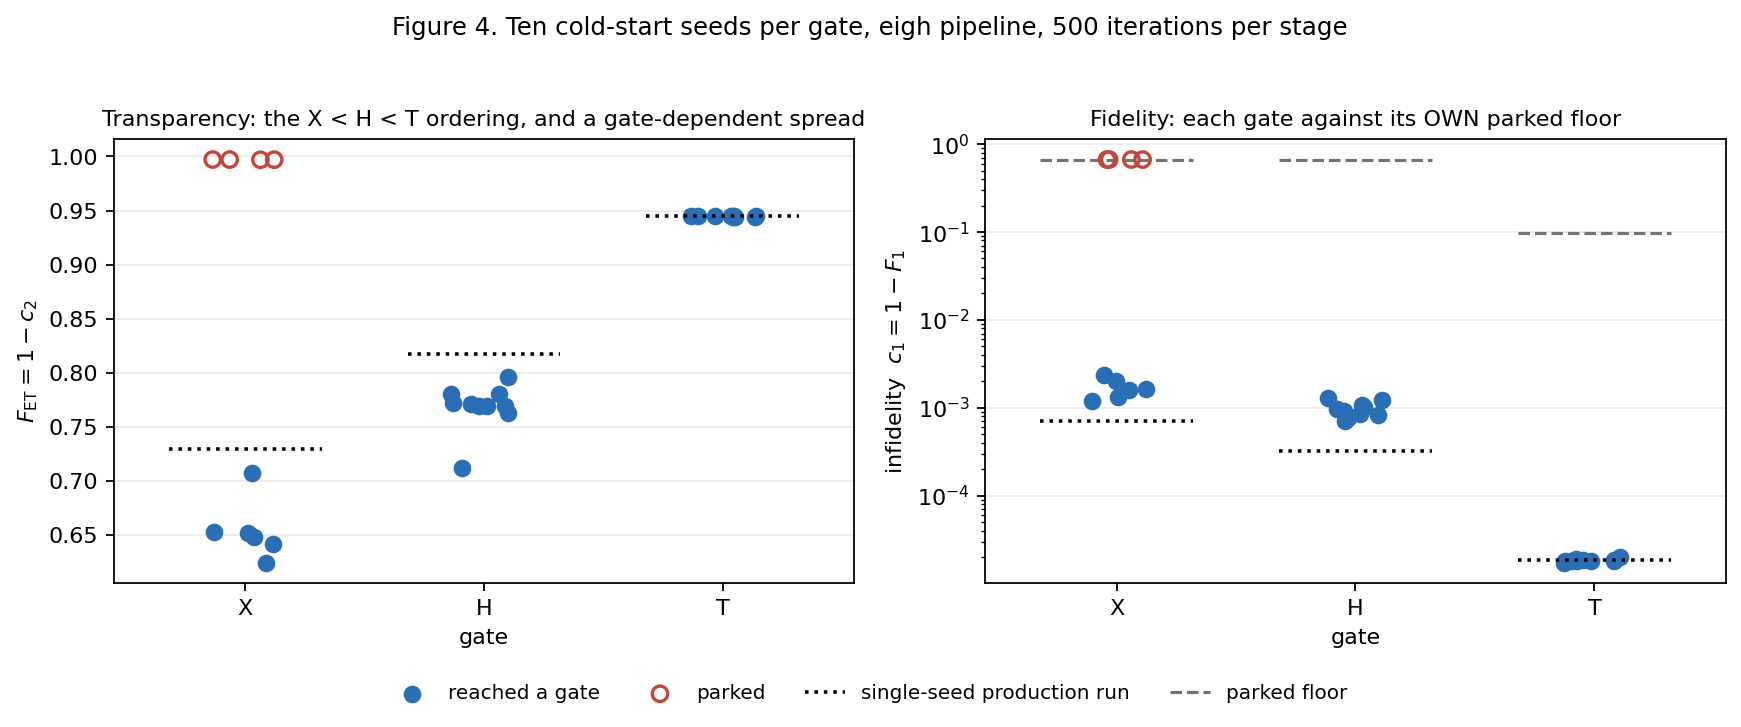

In [32]:
if not MS_HAVE:
    print("no multi-seed artefacts on disk; nothing to report")
else:
    # Figure 4. Saved then re-displayed with show(), the same pattern as Figure 3:
    # EST.diagnostics and EST.subspace_evolution call matplotlib.use("Agg") internally,
    # so an inline-rendered figure would depend on cell execution order.
    ms["c1"] = 1.0 - ms["F1_trained"]

    # The single-seed production runs of section 2.5, for reference only: they are the
    # JAX pipeline at 2000 it/stage, not this section's eigh pipeline at 500.
    prod = {}
    for g in MS_HAVE:
        t = RUNS[(g, "est")]["stages"][-1]["terms"][str(RUNS[(g, "est")]["trunc_list"][0])]
        prod[g] = {"F_ET_trained": 1 - t["c2"], "c1": t["c1"]}

    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))
    jit = np.random.default_rng(0)
    xpos = {g: i for i, g in enumerate(MS_HAVE)}

    panels = [("F_ET_trained", r"$F_{\mathrm{ET}} = 1 - c_2$",
               "Transparency: the X < H < T ordering, and a gate-dependent spread", False),
              ("c1", r"infidelity  $c_1 = 1 - F_1$",
               "Fidelity: each gate against its OWN parked floor", True)]

    for ax, (col, ylab, title, logy) in zip(axes, panels):
        for g in MS_HAVE:
            d = ms[ms.gate == g]
            x = xpos[g] + jit.uniform(-0.14, 0.14, len(d))
            y = d[col].to_numpy()
            conv = (d["regime"] == "gate").to_numpy()
            first = (g == MS_HAVE[0])
            ax.scatter(x[conv], y[conv], s=48, color=EST_COLOR, zorder=3,
                       label="reached a gate" if first else None)
            ax.scatter(x[~conv], y[~conv], s=48, facecolors="none", edgecolors=ORD_COLOR,
                       linewidths=1.5, zorder=3, label="parked" if first else None)
            ax.hlines(prod[g][col], xpos[g] - 0.32, xpos[g] + 0.32, color="k", ls=":",
                      lw=1.6, zorder=4,
                      label="single-seed production run" if first else None)
            if logy:   # the parked floor only means anything on the fidelity panel
                ax.hlines(1 - PARKED[g], xpos[g] - 0.32, xpos[g] + 0.32, color="0.45",
                          ls="--", lw=1.4, zorder=2,
                          label="parked floor" if first else None)
        if logy:
            ax.set_yscale("log")
        ax.set_xticks(list(xpos.values()))
        ax.set_xticklabels(MS_HAVE)
        ax.set_xlim(-0.55, len(MS_HAVE) - 0.45)
        ax.set_xlabel("gate")
        ax.set_ylabel(ylab)
        ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.25, axis="y")

    # One figure-level legend: a per-axis one collides with the reference lines.
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9, frameon=False,
               bbox_to_anchor=(0.5, -0.045))
    fig.suptitle("Figure 4. Ten cold-start seeds per gate, eigh pipeline, 500 iterations per stage",
                 fontsize=11)
    fig.tight_layout(rect=(0, 0.02, 1, 0.95))
    fig4_path = os.path.join(FIG_DIR, "fig4_multiseed.png")
    fig.savefig(fig4_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig4_path, width=980)

**Figure 4. Ten cold starts per gate.** Left, $F_{\mathrm{ET}}$; right, infidelity $c_1$ on a log
axis. Filled markers reached a gate, open markers parked. The dotted line is each gate's
single-seed production run from [§2.5](#2.5) (JAX, 2000 it/stage) and the dashed line on the
right is that gate's parked floor from Table 14. The four parked X seeds sit exactly on their
floor on the right and near $F_{\mathrm{ET}} = 1$ on the left, which is the whole pathology in
one picture: perfect transparency, no gate.

<a id="9.1"></a>
### 9.1 What this says about the H-vs-X gap

[§6.1](#6.1) reports H reaching $F_{\mathrm{ET}} = 0.818$ against X's $0.730$ and calls the
$0.088$ gap gate-dependent with no identified cause. Both numbers were single draws, and this
section's own X spread ($0.083$) is the same size as the gap — so the obvious objection was that
§6.1 compared two lucky seeds. **It did not.**

| | X | H | T |
|---|---|---|---|
| reached a gate | 6/10 | 10/10 | 10/10 |
| $F_{\mathrm{ET}}$ mean (converged) | 0.6544 | 0.7683 | 0.94464 |
| $F_{\mathrm{ET}}$ sd | 0.0279 | 0.0218 | 0.000190 |
| $F_{\mathrm{ET}}$ min-max | 0.6243 - **0.7071** | **0.7119** - 0.7961 | 0.9444 - 0.9449 |
| $F_1$ sd | $4.5\times10^{-4}$ | $1.9\times10^{-4}$ | $8.7\times10^{-7}$ |

The X and H samples **do not overlap at all**: X's best seed reaches $0.7071$, H's worst is
$0.7119$. Welch $t = +8.56$, $p = 1.6\times10^{-5}$; Mann-Whitney separates them perfectly
($p = 1.2\times10^{-4}$). The gap of seed means is $+0.114$, wider than the $0.088$ at one seed
each and $4.7\times$ the pooled within-gate sd of $0.024$. All three pairwise orderings are
non-overlapping and large — T$-$X is $17.4\times$ its pooled sd and T$-$H is $11.4\times$ — so
**X $<$ H $<$ T on transparency is a real ordering**, not an artefact of which seeds were drawn.

Two limits on how far that carries. This section trains at **500 iterations per stage on the
eigh pipeline**, not 2000 on JAX, so it replicates the *ordering and rough magnitude*, not the
number $0.088$ itself. And the budget is not neutral: each gate's production run sits above every
one of its own ten screen seeds, by $+0.0756$ (X), $+0.0492$ (H) and $+0.0006$ (T). The shift is
in the same direction for all three and does not close the gap, but it is large enough on X and H
that a 500-iteration screen should not be read as a converged pulse. T is the exception — at
$+0.0006$, T at 500 iterations has already arrived where T at 2000 does, which is one more way
of saying T is the easy gate ([limitation 5](#10)).

What remains unexplained is unchanged: neither iteration count ([limitation 1](#10)) nor seed
luck accounts for the gap, and the ordering tracks something about the targets themselves — X
needs the most population transfer, T the least — that this replication measures but does not
explain.

### Promoting a winner

Done in [§9.2](#9.2): a **cold start** at 2000 it/stage on the eigh pipeline, tagged
`best2000`, not a warm restart from the 500-it pre-image. A warm start from
`x_<g>_est_multiseed.npy` via `--init-x` remains the right way to *continue* a screen pulse;
that is not what was run. `--init` (physical-pulse `deramp`) is still the wrong way: it
returns a pre-image outside `hard_bound=60` for all three gates, and on T it cannot recover
the cavity columns `CONTROL_MASK` zeroed ([limitation 5](#10)).


<a id="9.2"></a>
### 9.2 Full-budget cold starts of the screen winners

The 500-it screen in this section is a ranking, not a delivered pulse ([§9.1](#9.1)). The three
winners — X seed 6, H seed 6, T seed 1 — were retrained from a **cold start** at the production
budget, 2000 iterations per stage, on the eigh + analytic-adjoint pipeline of [§8](#8). That is
the same recipe as [§2.5](#2.5)'s headline `est` runs, except for the seed and the gradient
backend.

This is **not** a warm restart from `x_<g>_est_multiseed.npy`. A warm start would continue a
500-it pulse for another 2000 it/stage; a cold start at the same seed with 2000 it/stage is a
different L-BFGS-B trajectory from the same $x_0$. The three commands, run concurrently
(`OMP_NUM_THREADS=2`; eigh is numpy, so this does not hit the XLA-saturation failure of
[§3](#3)):

```
OMP_NUM_THREADS=2 python EST/train_est_eigh.py --gate X --variant est \
    --maxiter 2000 --seed 6 --tag best2000
OMP_NUM_THREADS=2 python EST/train_est_eigh.py --gate H --variant est \
    --maxiter 2000 --seed 6 --tag best2000
OMP_NUM_THREADS=2 python EST/train_est_eigh.py --gate T --variant est \
    --maxiter 2000 --seed 1 --tag best2000
```

Outputs are tagged `best2000`, so they cannot clobber `u_<g>_est.npy`, [§8](#8)'s
`u_X_est_eigh.npy`, or the 500-it `u_<g>_est_seed<n>.npy`. Only the `est` variant was trained —
there is no matching `ord` at these seeds — so Figures 5a--c are EsT-only, the three transcribed
metrics of Figures 2a--c without the Ord overlay.

Wall clock was 0.85 h (X), 0.85 h (H), 0.49 h (T); 0.85 h in parallel on a 10-core machine.
All six stages stopped on `maxiter`. This cell does not retrain (`RUN_TRAINING` stays `False`).


In [33]:
# §9.2 comparison table: best2000 vs the 500-it screen of the same seed vs
# the seed-0 JAX production run. JSON only; Eqs. 6-8 are the next cell.
BEST2000_SEEDS = {"X": 6, "H": 6, "T": 1}
BEST2000_TAG = "best2000"

def _b2_json(g):
    return os.path.join(LOG_DIR, f"est_{g}_est_{BEST2000_TAG}.json")

def _b2_pulse(g):
    return os.path.join(PULSE_DIR, f"u_{g}_est_{BEST2000_TAG}.npy")

have_b2 = [g for g in GATES
           if os.path.exists(_b2_json(g)) and os.path.exists(_b2_pulse(g))]
missing_b2 = [g for g in GATES if g not in have_b2]
if missing_b2:
    print("best2000 artefacts missing for:", ", ".join(missing_b2))
    print("generate with:")
    for g in missing_b2:
        print(f"  OMP_NUM_THREADS=2 python EST/train_est_eigh.py --gate {g} "
              f"--variant est --maxiter 2000 --seed {BEST2000_SEEDS[g]} "
              f"--tag {BEST2000_TAG}")

def _terms(info, stage):
    key = str(info["trunc_list"][0])
    return info["stages"][stage]["terms"][key]

def _row(g, source, pipeline, info, seed):
    s1, s2 = info["stages"]
    t1, t2 = _terms(info, 0), _terms(info, 1)
    return {
        "gate": g, "seed": seed, "source": source, "pipeline": pipeline,
        "maxiter": info["maxiter"],
        "F1": 1 - t2["c1"], "F_ET": 1 - t2["c2"], "F_ET_s1": 1 - t1["c2"],
        "nit": f"{s1['nit']}+{s2['nit']}",
        "hours": (s1["seconds"] + s2["seconds"]) / 3600.0,
    }

rows_b2 = []
for g in have_b2:
    b2 = json.load(open(_b2_json(g)))
    rows_b2.append(_row(g, "best2000", "eigh", b2, b2["seed"]))
    scr_path = os.path.join(TABLE_DIR, "est_multiseed_cache",
                            f"{g}_seed{BEST2000_SEEDS[g]}.json")
    if os.path.exists(scr_path):
        scr = json.load(open(scr_path))
        rows_b2.append(_row(g, "screen 500-it", "eigh", scr["info"],
                            BEST2000_SEEDS[g]))
    prod = json.load(open(os.path.join(LOG_DIR, f"est_{g}_est.json")))
    rows_b2.append(_row(g, "production", "JAX expm", prod, prod["seed"]))

if rows_b2:
    tbl_b2 = pd.DataFrame(rows_b2)
    display(tbl_b2.style.format(
        {"F1": "{:.6f}", "F_ET": "{:.4f}", "F_ET_s1": "{:.4f}",
         "hours": "{:.3f}"}).hide(axis="index"))
else:
    print("no best2000 artefacts on disk; nothing to report")


gate,seed,source,pipeline,maxiter,F1,F_ET,F_ET_s1,nit,hours
X,6,best2000,eigh,2000,0.999102,0.7442,0.7818,2000+2000,0.849
X,6,screen 500-it,eigh,500,0.997960,0.7071,0.7563,500+500,0.210
X,0,production,JAX expm,2000,0.999285,0.7300,0.7290,2000+2000,2.886
H,6,best2000,eigh,2000,0.999437,0.8133,0.8316,2000+2000,0.852
H,6,screen 500-it,eigh,500,0.999029,0.7961,0.8288,500+500,0.220
H,0,production,JAX expm,2000,0.999675,0.8175,0.8268,2000+2000,5.132
T,1,best2000,eigh,2000,0.999982,0.9453,0.9213,2000+2000,0.491
T,1,screen 500-it,eigh,500,0.999982,0.9449,0.9195,500+500,0.127
T,0,production,JAX expm,2000,0.999982,0.9452,0.9154,2000+2000,1.865


**Table 16. Screen winners retrained cold at 2000 it/stage, against the 500-it screen of the
same seed and against the seed-0 JAX production run.** $F_{\mathrm{ET,s1}}$ is stage 1, before
the $w_2{=}0.1,\,w_3{=}0$ polish. All six `best2000` stages stopped on `maxiter`. Numbers are
the training cost's own $1-c_1$ / $1-c_2$, which the eigh re-score of the next cell reproduces
to $\sim 10^{-8}$.


In [34]:
# Eqs. 6-8 on the best2000 pulses, scored the same way §5 scores everything else.
FIG5 = {}
FIG5_CSV = os.path.join(TABLE_DIR, "est_fig5_best2000.csv")
EVAL_TRUNCS_B2 = (16, 18, 20, 22, 24, 28)

if not have_b2:
    print("no best2000 pulses; skip figures")
    met_b2 = pd.DataFrame()
else:
    need = (REGENERATE_FIGURES or not os.path.exists(FIG5_CSV)
            or any(not os.path.exists(os.path.join(FIG_DIR, f"fig5_best2000_{g}.png"))
                   for g in have_b2))
    fig_rows = []
    for g in have_b2:
        u = np.load(_b2_pulse(g))
        seed = BEST2000_SEEDS[g]
        u_scr = np.load(os.path.join(PULSE_DIR, f"u_{g}_est_seed{seed}.npy"))
        if need:
            r = diagnostics.analyze(u, gate=g, n_c=N_C)
            r_scr = diagnostics.analyze(u_scr, gate=g, n_c=N_C)
            scan = diagnostics.truncation_scan(u, g, trunc_list=EVAL_TRUNCS_B2)
            spread = max(scan.values()) - min(scan.values())
            held = [scan[n] for n in EVAL_TRUNCS_B2 if n != N_C]
            lin = os.path.join(FIG_DIR, f"fig5_best2000_{g}.png")
            logp = os.path.join(FIG_DIR, f"fig5_best2000_{g}_log.png")
            diagnostics.plot_fig1({"est": r}, lin, scale="linear")
            diagnostics.plot_fig1({"est": r}, logp, scale="log")
            print(f"figure (linear) -> {lin}")
            print(f"figure (log   ) -> {logp}")
            fig_rows.append({
                "gate": g, "seed": seed,
                "F1": r["F1"], "F1_screen": r_scr["F1"],
                "max_active_fock": r["max_active_fock"],
                "trunc_spread": spread,
                "F_heldout_mean": float(np.mean(held)),
                "delta_qec_mean": float(r["delta_qec"].mean()),
                "delta_qec_mean_screen": float(r_scr["delta_qec"].mean()),
                "leakage_mean": float(r["leakage"].mean()),
                "leakage_mean_screen": float(r_scr["leakage"].mean()),
                "leakage_final": float(r["leakage"][-1]),
                "eta_0L_mean": float(r["eta_0L"].mean()),
                "eta_0L_mean_screen": float(r_scr["eta_0L"].mean()),
                "eta_avg_mean": float(r["eta_avg"].mean()),
                "eta_avg_mean_screen": float(r_scr["eta_avg"].mean()),
                "c2_integrand_mean": float(r["c2_integrand"].mean()),
            })
        FIG5[g] = os.path.join(FIG_DIR, f"fig5_best2000_{g}.png")
    if fig_rows:
        met_b2 = pd.DataFrame(fig_rows)
        met_b2.to_csv(FIG5_CSV, index=False)
        print(f"table  -> {FIG5_CSV}")
    else:
        met_b2 = pd.read_csv(FIG5_CSV)
    # Production Eqs. 6-8 from the §5 tables, joined for the display.
    prod_bits = []
    for g in have_b2:
        sfx = "" if g == "X" else f"_{g}"
        p = pd.read_csv(os.path.join(TABLE_DIR, f"est_fig1_metrics{sfx}.csv"))
        p = p[(p.gate == g) & (p.variant == "est")].copy()
        p["source"] = "production"
        prod_bits.append(p[["gate", "F1", "delta_qec_mean", "leakage_mean",
                            "eta_0L_mean", "eta_avg_mean", "max_active_fock",
                            "trunc_spread"]])
    show_m = met_b2[["gate", "F1", "delta_qec_mean", "leakage_mean",
                     "eta_0L_mean", "eta_avg_mean", "max_active_fock",
                     "trunc_spread", "leakage_final",
                     "delta_qec_mean_screen", "leakage_mean_screen",
                     "eta_0L_mean_screen"]].copy()
    display(show_m.style.format({
        "F1": "{:.6f}",
        "delta_qec_mean": "{:.4e}", "delta_qec_mean_screen": "{:.4e}",
        "leakage_mean": "{:.4f}", "leakage_mean_screen": "{:.4f}",
        "eta_0L_mean": "{:.4e}", "eta_0L_mean_screen": "{:.4e}",
        "eta_avg_mean": "{:.4f}", "leakage_final": "{:.4f}",
        "trunc_spread": "{:.2e}",
    }).hide(axis="index"))


figure (linear) -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig5_best2000_X.png
figure (log   ) -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig5_best2000_X_log.png
figure (linear) -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig5_best2000_H.png
figure (log   ) -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig5_best2000_H_log.png
figure (linear) -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig5_best2000_T.png
figure (log   ) -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig5_best2000_T_log.png
table  -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/tables/est_fig5_best2000.csv


/Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/EST/diagnostics.py:457: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(frameon=False)


gate,F1,delta_qec_mean,leakage_mean,eta_0L_mean,eta_avg_mean,max_active_fock,trunc_spread,leakage_final,delta_qec_mean_screen,leakage_mean_screen,eta_0L_mean_screen
X,0.999102,3.5591e-01,0.2445,1.3758e-01,0.1834,11,1.19e-04,0.3976,2.8861e-01,0.2792,1.6962e-01
H,0.999437,1.2267e-01,0.1729,2.3366e-01,0.1960,9,1.53e-06,0.1923,2.2140e-01,0.1885,2.4591e-01
T,0.999982,7.0364e-28,0.0541,2.0070e-14,0.0363,4,4.93e-14,0.1201,8.8461e-28,0.0544,2.4432e-14


**Table 17. Eqs. 6--8 on the `best2000` pulses**, scored through `EST/diagnostics.py`'s eigh
propagator, the same path as Table 9. `_screen` columns are the 500-it pulse of the *same*
seed. Held-out $C_1$ spread is $1.2\times10^{-4}$ (X), $1.5\times10^{-6}$ (H),
$5\times10^{-14}$ (T) — all below the $10^{-3}$ alarm. $L(T)$ is the endpoint the average hides
([limitation 3](#10)).


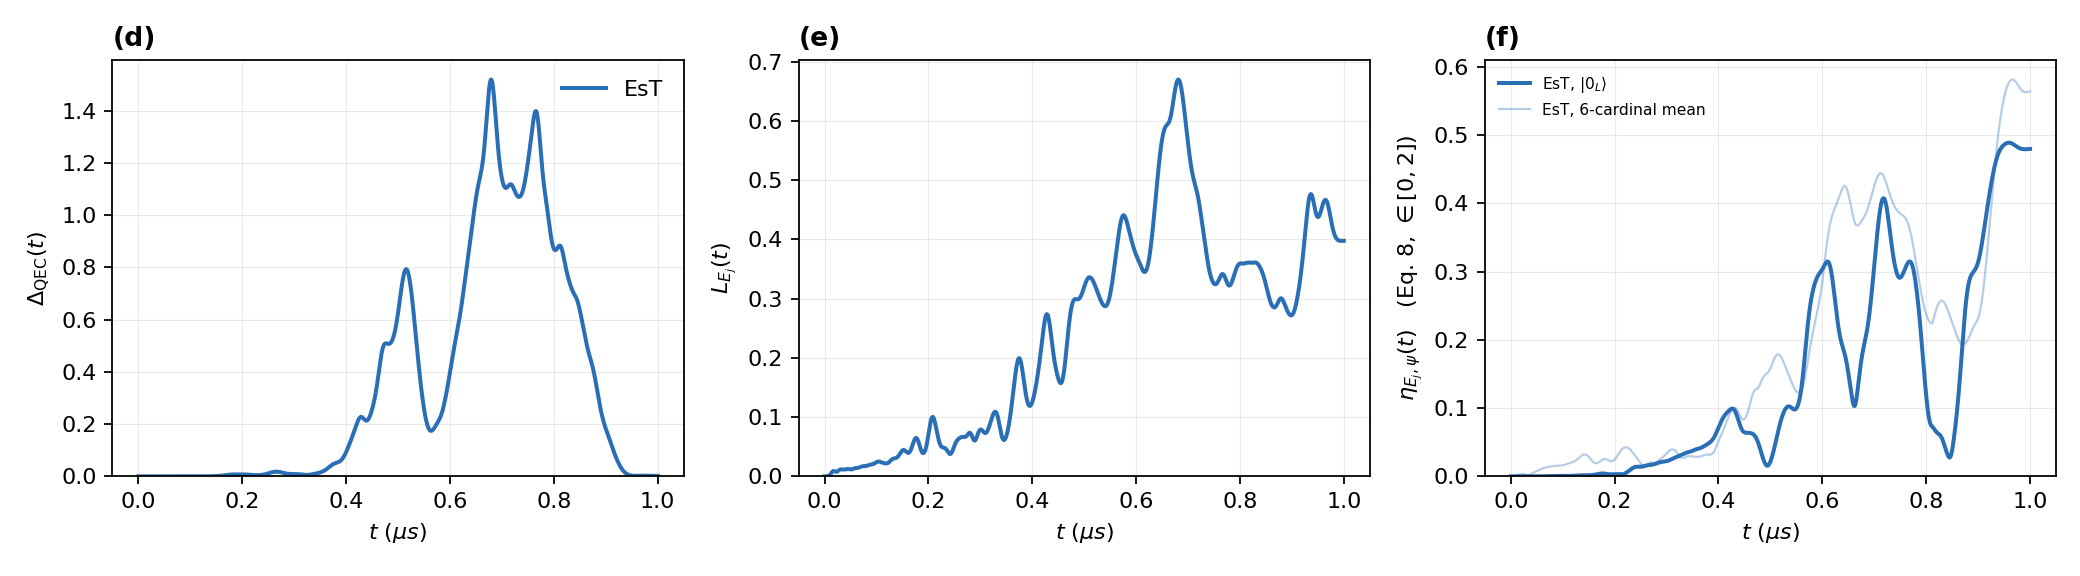

In [35]:
show(FIG5["X"], width=900)


**Figure 5a. X gate, seed 6, eigh, 2000 it/stage: $\Delta_{\mathrm{QEC}}$, $L_{E_j}$,
$\eta_{E_j,\psi}$ against time, EsT only, linear axes.** Same three panels as Figure 2a, no Ord
overlay (no matching `ord` was trained at this seed). 1.0 us pulse. $\Delta_{\mathrm{QEC}}$
returns to near zero at $t=T$ after a mid-gate peak of $\sim 1.5$, which the time-average of
0.356 does not show; $L$ does not, and ends at $L(T)=0.398$, the same endpoint leak as the
seed-0 JAX pulse (0.396).


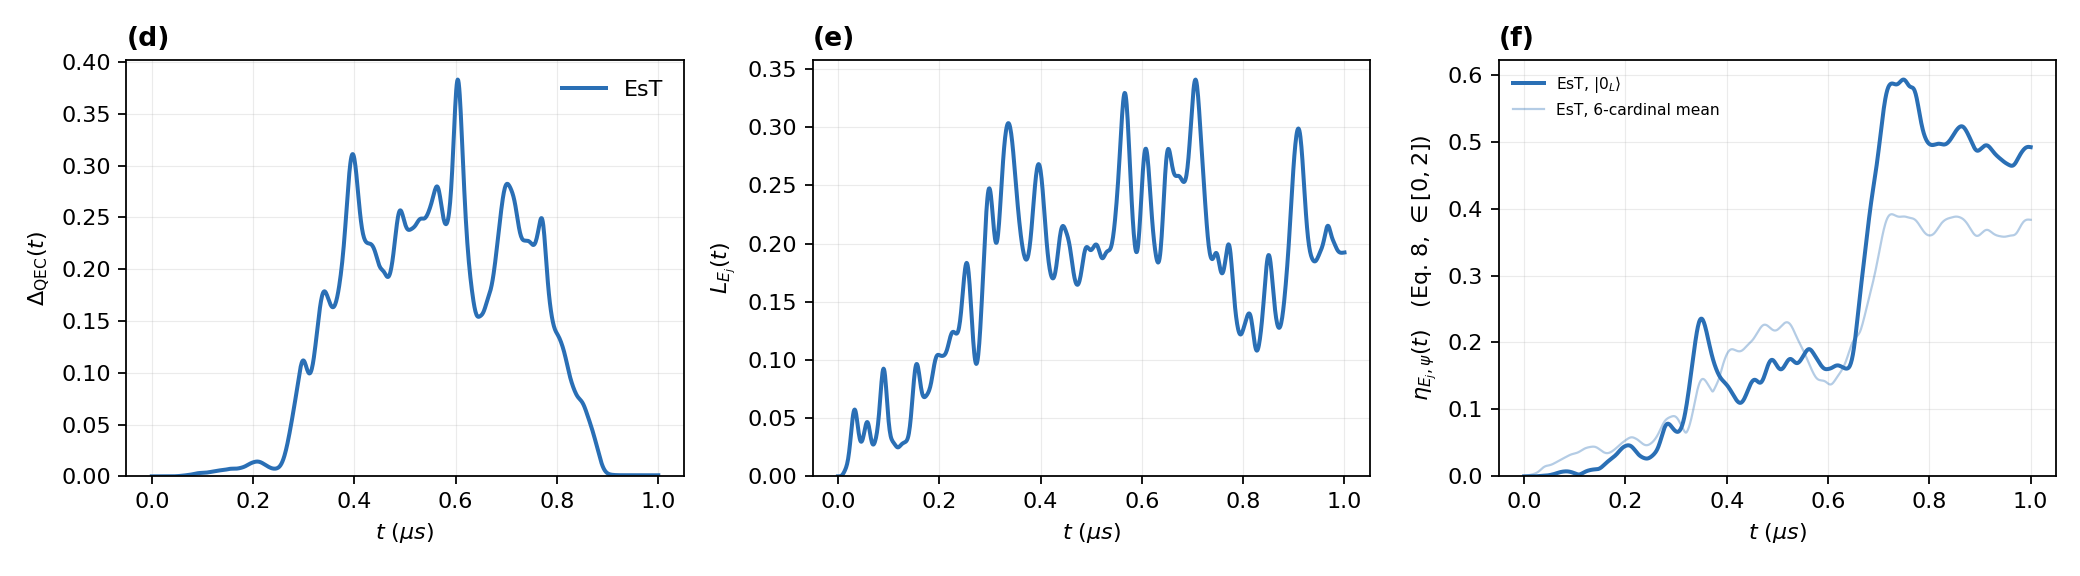

In [36]:
show(FIG5["H"], width=900)


**Figure 5b. H gate, seed 6, same axes.** $\Delta_{\mathrm{QEC}}$ is the metric this seed
improved most against its own 500-it screen (0.123 against 0.221) and against the seed-0 JAX
pulse (0.151). $L$ is unchanged against production (0.173 against 0.172). $\eta(|0_L\rangle)$
goes the other way (0.234 against production 0.198). The H-vs-X split across metrics in
Figure 2b is still a split, not a sweep.


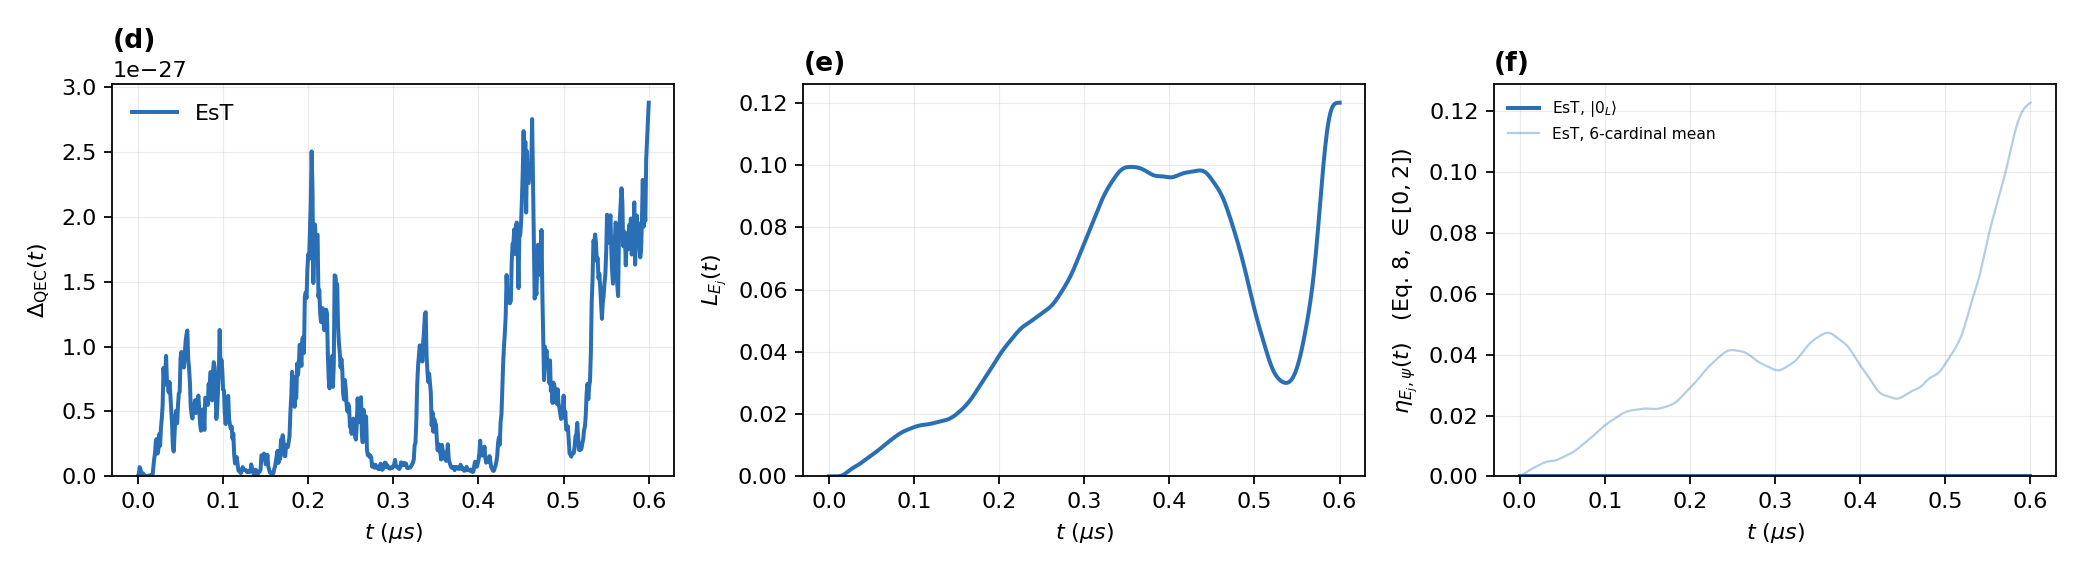

In [37]:
show(FIG5["T"], width=900)


**Figure 5c. T gate, seed 1, same axes.** 0.6 us, transmon-only. $\Delta_{\mathrm{QEC}}$ and
$\eta(|0_L\rangle)$ sit at numerical zero for this pulse too ($7\times10^{-28}$ and
$2\times10^{-14}$), the same machine-precision transparency a diagonal transmon-only gate
already had at 500 it and at the seed-0 JAX run. Only $L$ is a real number, 0.054, identical to
production. The 6-cardinal $\eta$ mean in panel (f) is the one that moves; $|0_L\rangle$ does
not, because a $Z$-rotation leaves $|0_L\rangle$ fixed.


**What the extra budget did.** Four pre-registered questions, then two things the numbers
showed that the questions did not ask.

1. **Did $4\times$ the screen budget move $F_{\mathrm{ET}}$ the way the seed-0 JAX ladder did?**
   X's 600$\to$2000 JAX ladder was $+0.051$. Here X seed 6 went $0.707\to 0.744$ ($+0.037$), H
   $0.796\to 0.813$ ($+0.017$), T $0.9449\to 0.9453$ ($+0.0004$). Same direction, smaller on X
   than the 600-it ladder, and T is the predicted null: it had already arrived at 500 it
   ([§9.1](#9.1)).
2. **Does the H-vs-X gap survive at a common 2000-it eigh budget on the best seeds?** Yes.
   $0.813$ against $0.744$, a gap of $0.069$. Narrower than the screen's $0.089$ and the
   production pair's $0.088$, because X gained more from the extra iterations than H did. The
   ordering $X < H < T$ holds. Both X and H still stopped on `maxiter`, so these are still
   lower bounds.
3. **T.** $+4\times10^{-4}$, inside the screen's $5.4\times10^{-4}$ band. Not a result, a
   confirmation that promoting T had nothing to find.
4. **Held-out $C_1$.** All three pulses plateau. X's spread $1.2\times10^{-4}$ is the largest
   and is an order below the $10^{-3}$ alarm.

**Stage 2 spent transparency to buy $F_1$.** That is the schedule $(w_2,w_3)=(0.1,\,0)$, and
it fired. X dropped $0.782\to 0.744$ in stage 2; H dropped $0.832\to 0.813$. The 500-it screen
did the same on these seeds ($0.756\to 0.707$, $0.829\to 0.796$). T went the other way
($0.921\to 0.945$), which is the easy-gate signature again. Stage 1 of this X run, at
$F_{\mathrm{ET}}=0.782$, is the most transparent X pulse in the repository — and is not the
pulse that was saved, because stage 2 is in the recipe.

**Against the headline seed-0 JAX pulses, this is not a ranking.** X's $F_{\mathrm{ET}}=0.744$
beats production's $0.730$ and H's $0.813$ loses to production's $0.818$. Both differences sit
inside the screen's seed spread ($0.083$ / $0.084$), which is [limitation 4](#10)'s whole
point, and the two pipelines find different basins from a $10^{-11}$ gradient disagreement
([§8.3](#8.3)). Eqs. 6--8 split besides: X improved $L$ (0.244 against production 0.258) and
$\eta(|0_L\rangle)$ (0.138 against 0.169) and got *worse* on $\Delta_{\mathrm{QEC}}$ (0.356
against 0.156), at a higher max active Fock (11 against 9). H improved $\Delta_{\mathrm{QEC}}$
(0.123 against 0.151) with $L$ unchanged. None of this replaces the summary table. The
headline pulses remain the seed-0 JAX set; these three are the screen winners run out to the
same iteration budget on the faster pipeline.

$L(T)$ did not move on X (0.398 against production 0.396). The endpoint-leak of
[limitation 3](#10) is not a seed-0 accident.


<a id="10"></a>
# 10. Limitations

**1. Iteration count does not explain the H-vs-X gap.** The obvious suspect was training time,
and it was tested directly. X's cold-start ladder in $F_{\mathrm{ET}}$ runs
$0.679$ (600 it) $\to 0.730$ (2000 it), with a 1000-iteration warm restart reaching $0.736$ in
between, so 3.3x the iterations bought $+0.051$, and the 2000-it cold run does not even clear
the warm restart. H is fixed at $0.818$ under the identical schedule. That leaves $0.088$, i.e.
**63% of the original gap, unexplained by iteration count**. Caveat in both directions: both
2000-it stage-1 runs stopped on `maxiter` (Table 6), so $0.730$ and $0.818$ are lower bounds and
a longer stage 1 could narrow *or* widen the gap.

The other obvious alternative -- that the gap is an artefact of comparing two single seeds --
is now ruled out too ([§9](#9), [§6.1](#6.1)): ten cold starts per gate separate X and H with no
overlap whatsoever, at a gap of seed means ($+0.114$) wider than the $0.088$ quoted here. So the
gap is neither iteration count nor seed luck, and its cause remains unidentified.

One comparison a reader will reach for and should not: the paper's Table II "ET fidelity"
(X/EsT $0.843$, no qubit errors) is a master-equation **end-of-gate** fidelity, whereas
$F_{\mathrm{ET}} = 1 - C_2$ is a **time-averaged** overlap. The $0.730$ above is a
different quantity. $C_2$ also retains its own deviation from the paper's printed
Eq. (C2) ([§2.3](#2.3), deviation 1), which the transcription of Eqs. 6--8 did not touch.

**2. The comparison is not like-for-like, except for T.** Max active Fock level is 9 (X EsT)
and 10 (H EsT) against 8 for both Ord pulses, so **every X/H ratio in [§4](#4)--[§6](#6) is
provisional**: those EsT pulses are being scored across a wider Fock spread than the controls
they are compared to. `diagnostics.py` prints the mismatch automatically whenever it fires, and
it fired for both X and H in [§5](#5). T is the one gate where it does not fire: both its
variants sit at `max_active_fock = 4`. That removes this particular caveat from T's own
EsT:Ord ratios, but does not make them comparable to X/H's; see limitation 5.

**3. The gate finishes leaking, and the cause is unknown.**

*On the time-average this replication matches the published gate.* That part is not a
limitation; it is here only to set the scale for the part that is. $L$ transfers between the two
implementations with nothing in the way — the paper prints it,

$$
L(t) \;=\; 1 - \operatorname{Tr}\!\big[\,P_E(t)\,\rho(t)\,\big],
\qquad \rho(0) \;=\; \tfrac{1}{2} I_E \,,
$$

and `diagnostics.leakage_Ej` computes exactly that, because it averages over the six error-space
Bloch cardinals and those six average to $\tfrac{1}{2} I_E$. Digitising Fig. 1e of the paper
(pixel extraction from the PDF in `sources/`; 400 and 600 dpi agree to $0.002$):

| $L$, X gate, lossless | here | Roy *et al.* |
|---|---|---|
| EsT, time-averaged | 0.258 | 0.22 |
| Ord, time-averaged | 0.740 | 0.61 |
| Ord : EsT | 2.87 | 2.74 |

This replication leaks $1.17\times$ **more** than the published gate, and separates the two
variants by $2.87\times$ against their $2.74\times$. Both sit on the same floor, so $0.258$ is
measuring App. A's obstruction and not an unconverged run.

**These numbers changed, and the reason was a bug.** Until Eqs. 6--8 were transcribed,
`_instantaneous_error_basis` was handed the $(T, n, 6)$ *cardinal* stack rather than the two
evolved code words. But $a$ restricted to the code space has **rank 2** — measured, the singular
values of $a\,P_C(t)$ are $[2.449,\,2.449,\,0,\,0,\,0,\,0]$ at every step — so `np.linalg.qr`
returned six orthonormal columns of which four were an arbitrary completion *outside* the error
space, and projecting onto them absorbed genuine leakage. Every $L$ in this notebook was
therefore an under-estimate: X/EsT read $0.148$ against the correct $0.258$, and T/EsT
$2.8\times10^{-6}$ against $0.054$.

The correction moved this replication **toward** the paper on the one metric that can be
compared to it: the ratio went $3.15\times \to 2.87\times$ against their $2.74\times$, and the
sign of the absolute discrepancy flipped from "we leak less than the published gate" (which was
never a comfortable thing for a less-converged replication to claim) to "we leak slightly more".
`DiagnosticsTest` now pins both the rank and the direction of the error.

**The limitation is the endpoint.** Time-averaging hides where the two pulses actually differ.
At $t = T$, the one instant when QEC runs:

| $L$ at $t = T$, X gate | EsT | Ord | ratio |
|---|---|---|---|
| here | 0.396 | 0.824 | $2.1\times$ |
| Roy *et al.* | 0.013 | 0.862 | $66\times$ |

Their gate finishes transparent; this one finishes leaking. **Update ([§11](#11)):** that was the objective, not the device. Adding a terminal error-space fidelity term ($w_{\rm err}=0.3$, X, seed 6) brings $L(T)$ to $0.0049$ at $F_1 = 0.9995$ and unchanged $F_{\rm ET}$; single seed. Measured on the delivered pulses,
the evolved error cardinals end at only $0.589$ overlap with the ideal gate applied in the error
basis, against $C_1 = 0.999$ in the code space: the optimizer drives the code space home and
leaves the error space where it lands. H/est ends far better ($L(T) = 0.118$, error-basis
overlap $0.851$) but has no published counterpart to be scored against.

**The objective does not explain it, which is the uncomfortable part.** App. C's cost function is
$C_{\mathrm{tot}} = \sum_i w_i C_i$ over exactly three terms — terminal code-space fidelity,
$1 - F_{\mathrm{ET,avg}}$, and velocity variance — at
$\vec{w} = (1,\; 0.6\text{–}0.75,\; 5\text{–}10)$ for stage 1 and $(1,\; 0.1,\; 0)$ for stage 2.
`SCHEDULES["est"]` is $(1,\, 0.7,\, 7)$ then $(1,\, 0.1,\, 0)$: the same three terms at the same
weights. Nor is the endpoint *under*-weighted here — Eq. (C2) sums $i = 0 \dots N-1$ and
**excludes** $t = T$, while `et_cost` averages over all $N+1$ steps and includes it.

Three candidates remain, none tested.

1. **A term the paper describes but never writes.** §III and App. C 1 both say the EsT gate
   optimises "fidelity of operation in both code *and error* space", yet no error-space fidelity
   term appears anywhere in Eqs. (C1)–(C8). If their released code carries one the paper does not
   print, that would explain the endpoint directly — and it is the same term limitation 5 needs
   for the `LE` variant.
2. **The $C_2$ normalisation deviation of [§2.3](#2.3).** Dividing by $N_{\mathrm{norm}}^2$
   instead of the printed $N_{\mathrm{norm}}$ reweights time steps by $1/\bar{n}(t)$ rather than
   $1/\sqrt{\bar{n}(t)}$ — a different effective schedule across the pulse. That deviation was
   justified on boundedness and never checked for what it does to the endpoint.
   **Now checked ([Appendix A](#A)): it does not explain the endpoint.** Retraining X at seed 0 with Eq. (C2)
   as printed, together with the printed $C_3$ and weights $(1, 0.6, 6)$, gives $L(T) = 0.470$. That is
   against $0.396$ for the delivered pulse and $0.013$ in the paper, so it moves *away* from the published
   gate. The error-basis overlap at $T$ falls from $0.589$ to $0.411$.

   The printed form instead buys photon number: max active Fock 13, peak $\langle n\rangle_C$ 4.4. Two
   caveats: it is a single seed, and the form change is confounded with the weight change.
3. **Basin.** Their Adam-on-Dynamiqs against L-BFGS-B here, which [§9](#9) shows moves
   $F_{\mathrm{ET}}$ by $0.08$ on seed alone.

Two caveats on the tables above. The comparison is against the paper's *delivered* pulse, whose
EsT and Ord variants were matched on max active Fock level — limitation 2 says ours are not. And
T's $L = 0.054$ is the easy gate speaking (limitation 5), not evidence that T sits closer to the
floor.

Until one of the three is settled, every transparency claim in [§4](#4)–[§6](#6) is about
**average** transparency, not about correctability when the gate ends.

**4. Replicates exist only for the `est` variant at the headline configuration.** Every run
in [§2.5](#2.5)--[§8](#8) is seed 0 trained at $n_c = 20$, and no *headline* configuration was
repeated. [§9](#9) samples ten cold starts per gate at **500 it/stage on eigh**, so the `est`
variant has a measured seed distribution; [§9.2](#9.2) then retrains the three winners cold at
2000 it/stage on the same pipeline, which lifts the budget hole for those three pulses only.
Two holes stand. (a) The **`ord` controls were never replicated** -- `multiseed_est.py`
hardcodes `variant="est"` -- so **every EsT:Ord ratio in [§4](#4)--[§6](#6) still carries no
error bar**, and neither does any absolute number in the summary table. (b) The headline JAX
pulses are still a single seed; §9.2's 2000-it pulses are eigh, a different basin
([§8.3](#8.3)), and are not a substitute. Truncation is still $n_c = 20$ throughout, though
§9's held-out re-score at $n_c \in \{16,18,22,24,28\}$ now covers all three gates, and §9.2's
winners plateau on that check.

What §9 does establish is that the spread is **large where it matters**: converged-seed
$F_{\mathrm{ET}}$ ranges over $0.083$ (X) and $0.084$ (H), so a difference of a few times
$10^{-3}$ between two single-seed $F_{\mathrm{ET}}$ values is not a ranking. $F_1$ is far
tighter (sd $4.5\times10^{-4}$ and $1.9\times10^{-4}$). For comparison, the main cat-code
track's own penalty sweep found a $\sim 10^{-3}$ noise floor from basin effects alone under
comparable conditions.

**5. T is trained but is not a controlled comparison to X/H.** T uses a shorter gate ($N=600$
against $1000$), a transmon-only `CONTROL_MASK`, and a diagonal target unitary with no
population transfer to shape, none of the "identical schedule, different target" structure
that makes the H-vs-X comparison in [§6.1](#6.1) meaningful. Its Ord baseline is also
qualitatively different: `ord` converges on `pgtol` in 16 iterations rather than exhausting the
2000-iteration budget (Table 6), so T's EsT:Ord ratios (Table 9) partly reflect how little
transparency-scrambling a diagonal phase gate needs in the first place, not a categorically
better EsT solution.

**Under the transcribed Eqs. 6 and 8, T stops producing a ratio at all.** Both its variants sit
at machine zero on $\Delta_{\mathrm{QEC}}$ ($\sim\!10^{-27}$) and on $\eta(|0_L\rangle)$
($\sim\!10^{-14}$), because a diagonal gate driven through the transmon alone does not mix Fock
levels: the Knill--Laflamme matrices stay exactly proportional to $P_C$, and the $|0_L\rangle$
Bloch vector is invariant in both subspaces. Only $L$ (6.97x) and the six-cardinal $\eta$
(5.81x) still separate them. The previously headline **80.97x on $L$ was an artifact of the
rank-2 basis bug** (limitation 3) and does not survive its fix; the pre-transcription 7.12x on
$\eta$ was measuring a phase Eq. 8 quotients out. Neither number should be quoted again.

[§9](#9) sharpens this limitation twice over rather than relieving it. **T's parked floor is
$F_1 = 0.902$, not $1/3$** (Table 14): a do-nothing pulse already scores $0.902$ on T, because a
diagonal phase gate leaves $\pm Z$ invariant and moves the other four cardinals by only $\pi/4$.
So T's headline $F_1 = 0.99998$ is measured against $0.902$ where X's and H's are measured
against $1/3$, and **the three gates' raw $F_1$ values are not on a common scale**; the
normalised gate progress of [§9](#9) is. And **T is very nearly seed-independent** — ten cold
starts land inside a $5.4\times10^{-4}$ band in $F_{\mathrm{ET}}$, roughly 150x tighter than X or
H, at $0.0006$ from the 2000-iteration production run — which is one more measurement of the same
underlying fact, that T is the easy gate, rather than evidence its solution is better found.

A correction on the warm-restart caveat, which was stated too strongly before T was trained.
`deramp` **does** round-trip T: `constrain(deramp(u)) == u` to $2.4\times10^{-14}$, and the
assertion inside `deramp` passes. What is true is that it is **not injective** for T — the
recovered pre-image has identically zero cavity columns, whereas the optimizer's actual `x` held
cavity values up to $59.9$ there, frozen junk that `CONTROL_MASK` zeroes on the way out. Separately,
and *not* specific to T, `deramp` returns a pre-image outside the default `hard_bound=60` for all
three gates ($79.5$, $88.1$, $90.7$ for X, H, T), which `_check_box` refuses. Either reason alone
means a warm restart needs `--init-x`, not `--init` ([§2.4](#2.4)). The **`LE` control variant is not
implemented** (it needs an error-space terminal-fidelity term, a new cost function rather than
a reweighting), and neither is the **AQEC recovery pulse** behind the paper's Figs. 4--5. So
this replication covers the transparency claim and not the end-to-end correction claim built on
top of it.

**6. The two-pipeline comparison is one seed, one gate, one variant.** [§8](#8) compares the
`expm`/autodiff and `eigh`/analytic-adjoint pipelines on X/`est` alone, at seed 0. The `ord`
control was never retrained on the second pipeline, so no EsT:Ord ratio in this document mixes
backends, and none should be constructed across them until it is. The efficiency result (3.90x
per gradient call) is a property of the two implementations and is reproducible on demand via
`EST/bench_propagators.py`; the *quality* difference (Table 12) is a single draw from the basin
noise of limitation 4 and carries no error bar at all. [§9](#9) puts a number on that: the
$0.008$ in $F_{\mathrm{ET}}$ that separates the two pipelines at one seed each is an order of
magnitude inside the converged-seed spread of either gate ($0.083$ on X, $0.084$ on H). **The
Table 12 comparison is not resolvable**, and no amount of care in that section makes it so; only
replicating both pipelines across seeds would.


<a id="11"></a>
# 11. Extra cost terms for end-of-gate transparency

The X pulses of [§5](#5) and [§9.2](#9.2) are transparent on average but not at the end. The
§9.2 pulse (seed 6) finishes at $L(T) = 0.398$, against $0.013$ in the paper
([limitation 3](#10)). QEC runs at $t = T$, so the endpoint is the number that matters. The
objective explains the gap. $C_1$ is terminal on the code space, but nothing is terminal on the
error space: $C_2$ is a time average. App. C of the paper (p. 14) lists extra cost terms that
"can be employed in the same framework". This section adds three, trains X with each, and asks
two questions: which term closes the endpoint leak, and what does it cost elsewhere?

<a id="11.1"></a>
### 11.1 Method

**Three terms**, added on top of $C_1$–$C_4$ in the eigh + hand-derived-adjoint pipeline of
[§8](#8) (`EST/grape_eigh.py`):

| term | definition | type | weight (both stages) |
|---|---|---|---|
| $C_{\rm err}$ | $1-\frac16\sum_j \lvert\langle U_{\rm ideal}E_j \mid U(T) \mid \psi_{E_j}\rangle\rvert^2$: $C_1$ applied to the error cardinals | terminal | $w_{\rm err} = 0.3$ |
| $C_5$ | $\big\langle \big(\Delta\bar n_L(t)/(\bar n_0+\bar n_1)\big)^2 \big\rangle_t$, with $\Delta\bar n_L$ from Eq. A7 | running | $w_5 = 30$ |
| $C_6$ | $\sum_k \lVert u_{k+1}-u_k\rVert^2$, the cat-code smoothness penalty | pulse | $w_6 = 5\times10^{-6}$ (half the cat-code value) |

**Table 18. The extra cost terms.** Each term keeps its weight in both stages; $C_1$–$C_4$ keep
the [§2.5](#2.5) schedule (Table 18b). $1 - C_{\rm err}$ on `u_X_est` is $0.589$, the error-basis overlap
quoted in limitation 3, so $C_{\rm err}$ trains exactly the quantity that limitation reports.
The $[0,1]$ normalization of $C_5$ is this repo's choice; the paper gives none.

**Weights in each stage.** Every run minimizes $C = \sum_i w_i C_i$ in two L-BFGS-B stages. The
weights $w_i$ play the role of the penalty $\lambda$'s in the cat-code track. Each tuple below is
$(w_1, w_2, w_3, w_4;\ w_{\rm err}, w_5, w_6)$, the weights on
$(C_1, C_2, C_3, C_4;\ C_{\rm err}, C_5, C_6)$:

| run | iterations per stage | stage 1 | stage 2 |
|---|---|---|---|
| baseline (`est_best2000`, [§9.2](#9.2)) | 2000 | $(1,\ 0.7,\ 7,\ 1;\ 0,\ 0,\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ 0,\ 0,\ 0)$ |
| `est_err` | 2000 | $(1,\ 0.7,\ 7,\ 1;\ \mathbf{0.3},\ 0,\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ \mathbf{0.3},\ 0,\ 0)$ |
| `est_dn` | 2000 | $(1,\ 0.7,\ 7,\ 1;\ 0,\ \mathbf{30},\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ 0,\ \mathbf{30},\ 0)$ |
| `est_err_dn` | 2000 | $(1,\ 0.7,\ 7,\ 1;\ \mathbf{0.3},\ \mathbf{30},\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ \mathbf{0.3},\ \mathbf{30},\ 0)$ |
| `est_all` | 2000 | $(1,\ 0.7,\ 7,\ 1;\ \mathbf{0.3},\ \mathbf{30},\ \mathbf{5\times10^{-6}})$ | $(1,\ 0.1,\ 0,\ 1;\ \mathbf{0.3},\ \mathbf{30},\ \mathbf{5\times10^{-6}})$ |
| scan control ([§9](#9) screen, each seed) | 500 | $(1,\ 0.7,\ 7,\ 1;\ 0,\ 0,\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ 0,\ 0,\ 0)$ |
| scan, $C_{\rm err}$ alone | 500 | $(1,\ 0.7,\ 7,\ 1;\ \mathbf{w_{\rm err}},\ 0,\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ \mathbf{w_{\rm err}},\ 0,\ 0)$, $\ w_{\rm err} \in \{0.3, 1, 3\}$ |
| scan, $C_5$ alone | 500 | $(1,\ 0.7,\ 7,\ 1;\ 0,\ \mathbf{w_5},\ 0)$ | $(1,\ 0.1,\ 0,\ 1;\ 0,\ \mathbf{w_5},\ 0)$, $\ w_5 \in \{1, 3, 6, 10, 15, 30\}$ |

**Table 18b. Objective weights per stage.** The full-run rows are read from each run's
`logs/est_X_<run>.json` sidecar, and the scan rows from `logs/est_X_est_{err,dn}_smoke500_seed<s>_w*.json`
(seed 6's cells from the original scan: `..._smoke500_w*.json`). Every scan row is run at
each of the six seeds.
Bold marks the weights this section adds. Only $w_2$ and $w_3$ change between stages:
- **Stage 1** trains transparency: $w_2 = 0.7$ on $C_2$ and $w_3 = 7$ on $C_3$.
- **Stage 2** finishes the gate: $w_2$ drops to $0.1$ and $w_3$ to $0$.

The extra weights $w_{\rm err}$, $w_5$ and $w_6$ are the same in both stages. $w_1 = w_4 = 1$
throughout. `est_all`'s $w_6$ is `DEFAULT_W_SMOOTH` in `EST/train_est_eigh.py`; the command below
passes no `--w-smooth`.

Two properties of $C_5$ matter below:
- **It is necessary, not sufficient.** It constrains only the $Z$ part of the $(a,a)$ term of
  $\Delta_{\rm QEC}$.
- **It is small** ($\sim10^{-2}$), because a linear drive shifts $\bar n_0$ and $\bar n_1$
  equally and only the nonlinearities separate them. That is why its weight is large.

**Correctness.** The three hand-derived gradients agree with central finite differences and
with JAX autodiff to a relative $10^{-8}$ (`EST/test_grape_eigh.py`, 34 tests). With the extra
weights at zero, the objective is bit-identical to before.

**Protocol.**
1. **Weight scan** (Figure 6a). X, 500 it/stage, over the six seeds of [§9](#9) that reach a
   gate: 0, 2, 4, 5, 6 and 8 (seeds 1, 3, 7 and 9 park, Table 15). $w_{\rm err} \in \{0.3, 1, 3\}$
   and $w_5 \in \{1, 3, 6, 10, 15, 30\}$, each term alone: 54 runs. Each seed's control is its
   own §9 screen pulse, at the same budget. The scan was first run at seed 6 alone with
   $w_5 \in \{3, 10, 30, 100\}$; seed 6 reuses those runs where the weight is still on the grid,
   and $w_5 = 100$ has left it.
2. **Selection.** Take the largest weight that still reaches the gate ($c_1 \le 3\times$ the
   control's), improves its own target, and costs at most $0.05$ in $F_{\rm ET}$. **The last
   condition was added after the seed-6 scan.** Without it, that scan's rule picked
   $w_{\rm err} = 3$ and $w_5 = 100$, which damage transparency. Over six seeds, the gate condition
   must hold on every seed against its own control, and the other two compare seed means.
3. **Training.** Four cold starts at seed 6, 2000 it/stage, with the same pipeline and the same
   $C_1$–$C_4$ weights per stage as the §9.2 baseline (Table 18b): `est_err` (+ $C_{\rm err}$), `est_dn` (+ $C_5$), `est_err_dn` (both) and
   `est_all` (both + $C_6$).

```
python EST/smoke_new_terms.py commands > scan.sh && sh scan.sh   # the six-seed scan, 6 jobs at a time
python EST/smoke_new_terms.py summarize   # -> tables/est_newterms_smoke_X_6seeds.csv

for v in est_err est_dn est_err_dn est_all; do
  OMP_NUM_THREADS=2 python EST/train_est_eigh.py --gate X --variant $v --seed 6 \
      --maxiter 2000 --w-err 0.3 --w-dn 30 --tag seed6 &
done; wait
python EST/compare_new_terms.py    # scores every pulse -> tables/est_newterms_X_seed6*
```

In [38]:
# §11 setup, then Figure 6a. Encoding shared by Figures 6a-c: the baseline in near-black and
# the four runs in categorical slots 1-4 (fixed order), each with its own line style, so no
# run is identified by colour alone.
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, NullFormatter
import importlib
from EST import kitten_code, grape_eigh, train_est_eigh, compare_new_terms as cnt
from EST import smoke_new_terms as snt

# Sections 8 and 9 already imported these modules (via compare_propagators and
# multiseed_est). A kernel that ran them before the extra cost terms existed keeps the
# stale copies, and cnt.main() then fails with "build_gate_objective() got an
# unexpected keyword argument 'extra_terms'". Reload in dependency order:
# train_est_eigh binds build_gate_objective by name, so it must follow grape_eigh.
for _mod in (kitten_code, grape_eigh, train_est_eigh, cnt, snt):
    importlib.reload(_mod)

NT_RUNS = ["baseline", "est_err", "est_dn", "est_err_dn", "est_all"]
NT_LABEL = {"baseline": "baseline (§9.2)", "est_err": r"+ $C_{\rm err}$",
            "est_dn": r"+ $C_5$", "est_err_dn": r"+ $C_{\rm err}$ + $C_5$",
            "est_all": r"+ $C_{\rm err}$ + $C_5$ + $C_6$"}
NT_COLOR = {"baseline": "#1f1f1f", "est_err": "#2a78d6", "est_dn": "#eb6834",
            "est_err_dn": "#1baf7a", "est_all": "#eda100"}
NT_LS = {"baseline": "-", "est_err": "-", "est_dn": "--", "est_err_dn": "-.", "est_all": ":"}
# The 500-it scan over the six §9 seeds that reach a gate. The seed-6-only scan it
# replaced stays frozen in tables/est_newterms_smoke_X_seed6.csv.
NT_SCAN_CSV = snt.CSV_PATH
NT_CHOSEN = {"err": 0.3, "dn": 30.0}      # the weights the §11.2 full runs use

nt_missing = [v for v in NT_RUNS[1:]
              if not os.path.exists(os.path.join(PULSE_DIR, f"u_X_{v}_seed6.npy"))]
nt_have = not nt_missing
nt_scan_have = os.path.exists(NT_SCAN_CSV)
if not nt_have:
    print("§11.2 full runs missing; generate with:")
    for v in NT_RUNS[1:]:
        print(f"  OMP_NUM_THREADS=2 python EST/train_est_eigh.py --gate X --variant {v} "
              "--seed 6 --maxiter 2000 --w-err 0.3 --w-dn 30 --tag seed6")
    print("  python EST/compare_new_terms.py")
if not nt_scan_have:
    print("§11.1 six-seed weight scan missing; generate with:")
    print("  python EST/smoke_new_terms.py commands > scan.sh && sh scan.sh")
    print("  python EST/smoke_new_terms.py summarize")

if nt_have:
    if REGENERATE_FIGURES or not (os.path.exists(cnt.CSV_PATH)
                                  and os.path.exists(cnt.TRACES_PATH)):
        cnt.main()
    nt = pd.read_csv(cnt.CSV_PATH)
    ntr = np.load(cnt.TRACES_PATH)

if nt_scan_have:
    scan = pd.read_csv(NT_SCAN_CSV)
    scan_ctrl = scan[scan.term == "control"]
    # The selection rule re-applied to the six-seed scan (seed means, gate on every seed).
    _, scan_pick, scan_pick_rev = snt.apply_rule(scan)

    SCAN_METRICS = [("L_T", r"$L(T)$   (lower is better)"),
                    ("F_ET", r"$F_{\rm ET}$   (higher is better)"),
                    ("delta_qec_mean", r"mean $\Delta_{\rm QEC}$   (lower is better)"),
                    ("eta0_mean", r"mean $\eta(|0_L\rangle)$   (lower is better)")]
    SCAN_ROWS = [("err", "est_err", r"$C_{\rm err}$ alone", r"weight $w_{\rm err}$"),
                 ("dn", "est_dn", r"$C_5$ alone", r"weight $w_5$")]
    # (pick, marker, size, edge colour, line width): full-run weight, then both rules.
    MARKS = lambda term: [(NT_CHOSEN[term], "o", 260, "k", 1.8),
                          (scan_pick[term], "s", 170, "0.45", 1.4),
                          (scan_pick_rev[term], "D", 120, "#b0197e", 1.4)]

    fig, axes = plt.subplots(2, 4, figsize=(16.0, 6.6))
    jit = np.random.default_rng(0)
    for r, (term, run, row_name, wlab) in enumerate(SCAN_ROWS):
        d = scan[scan.term == term].sort_values(["weight", "seed"])
        grid = np.sort(d.weight.unique())
        # Same multiplicative jitter in every column, so one seed sits at the same x.
        xj = d.weight.to_numpy() * 10 ** jit.uniform(-0.03, 0.03, len(d))
        for c, (col, title) in enumerate(SCAN_METRICS):
            ax = axes[r, c]
            ax.axhspan(scan_ctrl[col].min(), scan_ctrl[col].max(), color="0.55",
                       alpha=0.14, lw=0, zorder=0)
            ax.axhline(scan_ctrl[col].mean(), color="0.55", ls="--", lw=1.4, zorder=1)
            ax.scatter(xj, d[col], s=18, color=NT_COLOR[run], alpha=0.35, lw=0, zorder=2)
            mean = d.groupby("weight")[col].mean()
            ax.plot(mean.index, mean.values, color=NT_COLOR[run], lw=2, marker="o", ms=7,
                    zorder=3)
            for w, mk, size, ec, lw in MARKS(term):
                if w is not None and w in mean.index:
                    ax.scatter([w], [mean[w]], s=size, marker=mk, facecolors="none",
                               edgecolors=ec, linewidths=lw, zorder=4)
            ax.set_xscale("log")
            ax.set_xticks(grid)
            ax.xaxis.set_major_formatter(FormatStrFormatter("%g"))
            ax.xaxis.set_minor_formatter(NullFormatter())
            ax.set_xlabel(wlab)
            ax.grid(alpha=0.25)
            if r == 0:
                ax.set_title(title, fontsize=10)
        axes[r, 0].set_ylabel(row_name, fontsize=11)

    handles = [Line2D([], [], color="0.3", lw=2, marker="o", ms=6, label="seed mean"),
               Line2D([], [], ls="", marker="o", ms=5, color="0.3", alpha=0.35,
                      label="individual seeds"),
               Line2D([], [], color="0.55", ls="--", lw=1.4,
                      label="control mean (band: min-max over seeds)"),
               Line2D([], [], ls="", marker="o", ms=13, mfc="none", mec="k", mew=1.8,
                      label="weight used for the full runs"),
               Line2D([], [], ls="", marker="s", ms=10, mfc="none", mec="0.45", mew=1.4,
                      label="pick of the original rule"),
               Line2D([], [], ls="", marker="D", ms=8, mfc="none", mec="#b0197e", mew=1.4,
                      label="pick of the revised rule")]
    fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Figure 6a. Weight scan: X gate, seeds "
                 + ", ".join(str(s) for s in snt.SEEDS) + ", 500 it/stage", fontsize=11)
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    fig6a_path = os.path.join(FIG_DIR, "fig6a_newterms_scan_X.png")
    fig.savefig(fig6a_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig6a_path, width=1100)
    print("six-seed picks  original rule:", scan_pick, "  revised rule:", scan_pick_rev)

§11.1 six-seed weight scan missing; generate with:
  python EST/smoke_new_terms.py commands > scan.sh && sh scan.sh
  python EST/smoke_new_terms.py summarize
scored baseline    stage1  F1=0.944255 F_ET=0.7818 F_err(T)=0.3665 L(T)=0.4779
scored baseline    final   F1=0.999102 F_ET=0.7442 F_err(T)=0.5379 L(T)=0.3976
scored est_err     stage1  F1=0.974386 F_ET=0.7387 F_err(T)=0.9322 L(T)=0.1175
scored est_err     final   F1=0.999499 F_ET=0.7496 F_err(T)=0.9963 L(T)=0.0049
scored est_dn      stage1  F1=0.969516 F_ET=0.7072 F_err(T)=0.3258 L(T)=0.5614
scored est_dn      final   F1=0.999091 F_ET=0.7177 F_err(T)=0.3369 L(T)=0.5886
scored est_err_dn  stage1  F1=0.971756 F_ET=0.7005 F_err(T)=0.8433 L(T)=0.2034
scored est_err_dn  final   F1=0.997083 F_ET=0.6018 F_err(T)=0.9818 L(T)=0.0219
scored est_all     stage1  F1=0.975388 F_ET=0.6884 F_err(T)=0.8830 L(T)=0.1596
scored est_all     final   F1=0.997737 F_ET=0.6136 F_err(T)=0.9820 L(T)=0.0277

table  -> /Users/ziyi_dong_mac/Documents/GitHub/Qub

**Figure 6a. Weight scan (X, seeds 0, 2, 4, 5, 6, 8, 500 it/stage).** Top row: $C_{\rm err}$
alone. Bottom row: $C_5$ alone. The columns are leakage at the end of the gate $L(T)$,
time-averaged transparency $F_{\rm ET}$, time-averaged $\Delta_{\rm QEC}$, and the time-averaged
trajectory mismatch $\eta(|0_L\rangle)$ of Eq. 8. Faint dots are individual seeds and the bold
line is their mean. The dashed line is the mean of the six controls with no extra terms, and the
grey band spans them. The ring marks the weight used for the full runs; the square and diamond
mark the original and revised rules' picks on this scan, both applied to seed means.

> **Pending re-run.** The bullets below still quote the original seed-6-only scan
> (`tables/est_newterms_smoke_X_seed6.csv`) and will be rewritten from the six-seed table.

- **$C_{\rm err}$ removes the endpoint leak at the smallest weight** ($L(T)$
  $0.549 \to 0.011$). Larger weights gain nothing at $t = T$ and cost $F_{\rm ET}$
  ($0.687 \to 0.445$).
- **$C_5$ lowers $\Delta_{\rm QEC}$** ($0.289 \to 0.147$ at $w_5 = 30$) but never lowers $L(T)$.
  At $w_5 = 100$ it raises $L(T)$ to $0.845$.

<a id="11.2"></a>
### 11.2 Results

The comparison has five pulses: the §9.2 baseline and the four runs. All share seed, budget
(2000 it/stage, every stage stopped on `maxiter`) and pipeline. All are scored the same way: the
training report at $n_c = 20$, and Eqs. 6–8 through the independent eigh propagator.

In [39]:
# Table 19: scalar metrics, final pulses first, then the stage-1 pulses.
if nt_have:
    T19_COLS = ["run", "stage", "F1", "F_ET", "F_err_T", "L_mean", "L_tail", "L_T",
                "dqec_mean", "eta0_mean", "eta0_tail", "c6", "oob_max", "max_active_fock"]
    t19 = (nt.assign(_run=nt.run.map({r: i for i, r in enumerate(NT_RUNS)}),
                     _stage=(nt.stage == "stage1"))
             .sort_values(["_stage", "_run"])[T19_COLS])
    display(t19.style.format({
        "F1": "{:.5f}", "F_ET": "{:.3f}", "F_err_T": "{:.3f}", "L_mean": "{:.3f}",
        "L_tail": "{:.3f}", "L_T": "{:.4f}", "dqec_mean": "{:.3f}", "eta0_mean": "{:.3f}",
        "eta0_tail": "{:.3f}", "c6": "{:.0f}", "oob_max": "{:.1e}"}, na_rep="-")
        .hide(axis="index"))

run,stage,F1,F_ET,F_err_T,L_mean,L_tail,L_T,dqec_mean,eta0_mean,eta0_tail,c6,oob_max,max_active_fock
baseline,final,0.99910,0.744,0.538,0.244,0.408,0.3976,0.356,0.138,0.449,12596,2.3e-03,11
est_err,final,0.99950,0.750,0.996,0.231,0.048,0.0049,0.217,0.221,0.045,11059,4.3e-03,9
est_dn,final,0.99909,0.718,0.337,0.269,0.566,0.5886,0.181,0.174,0.679,11451,2.1e-03,13
est_err_dn,final,0.99708,0.602,0.982,0.379,0.137,0.0219,0.275,0.299,0.131,12822,4.2e-03,11
est_all,final,0.99774,0.614,0.982,0.312,0.093,0.0277,0.248,0.534,0.018,2395,2.1e-04,9
baseline,stage1,0.94426,0.782,0.366,0.207,0.457,0.4779,0.424,0.159,0.648,13940,-,10
est_err,stage1,0.97439,0.739,0.932,0.246,0.198,0.1175,0.138,0.222,0.077,12169,-,9
est_dn,stage1,0.96952,0.707,0.326,0.281,0.512,0.5614,0.174,0.197,0.303,11015,-,10
est_err_dn,stage1,0.97176,0.701,0.843,0.289,0.296,0.2034,0.234,0.189,0.461,16937,-,9
est_all,stage1,0.97539,0.688,0.883,0.274,0.209,0.1596,0.227,0.351,0.169,5411,-,9


**Table 19. Scalar metrics for the final and stage-1 pulses.** The "tail" columns average over
$t \ge 0.9\,T$. `oob_max` is the larger out-of-band energy fraction of the two drives, audited
on final pulses only. For every pulse, the re-scored $F_1$ matches the training cost to
$10^{-14}$, and the held-out-truncation spread is at most $2.4\times10^{-4}$.

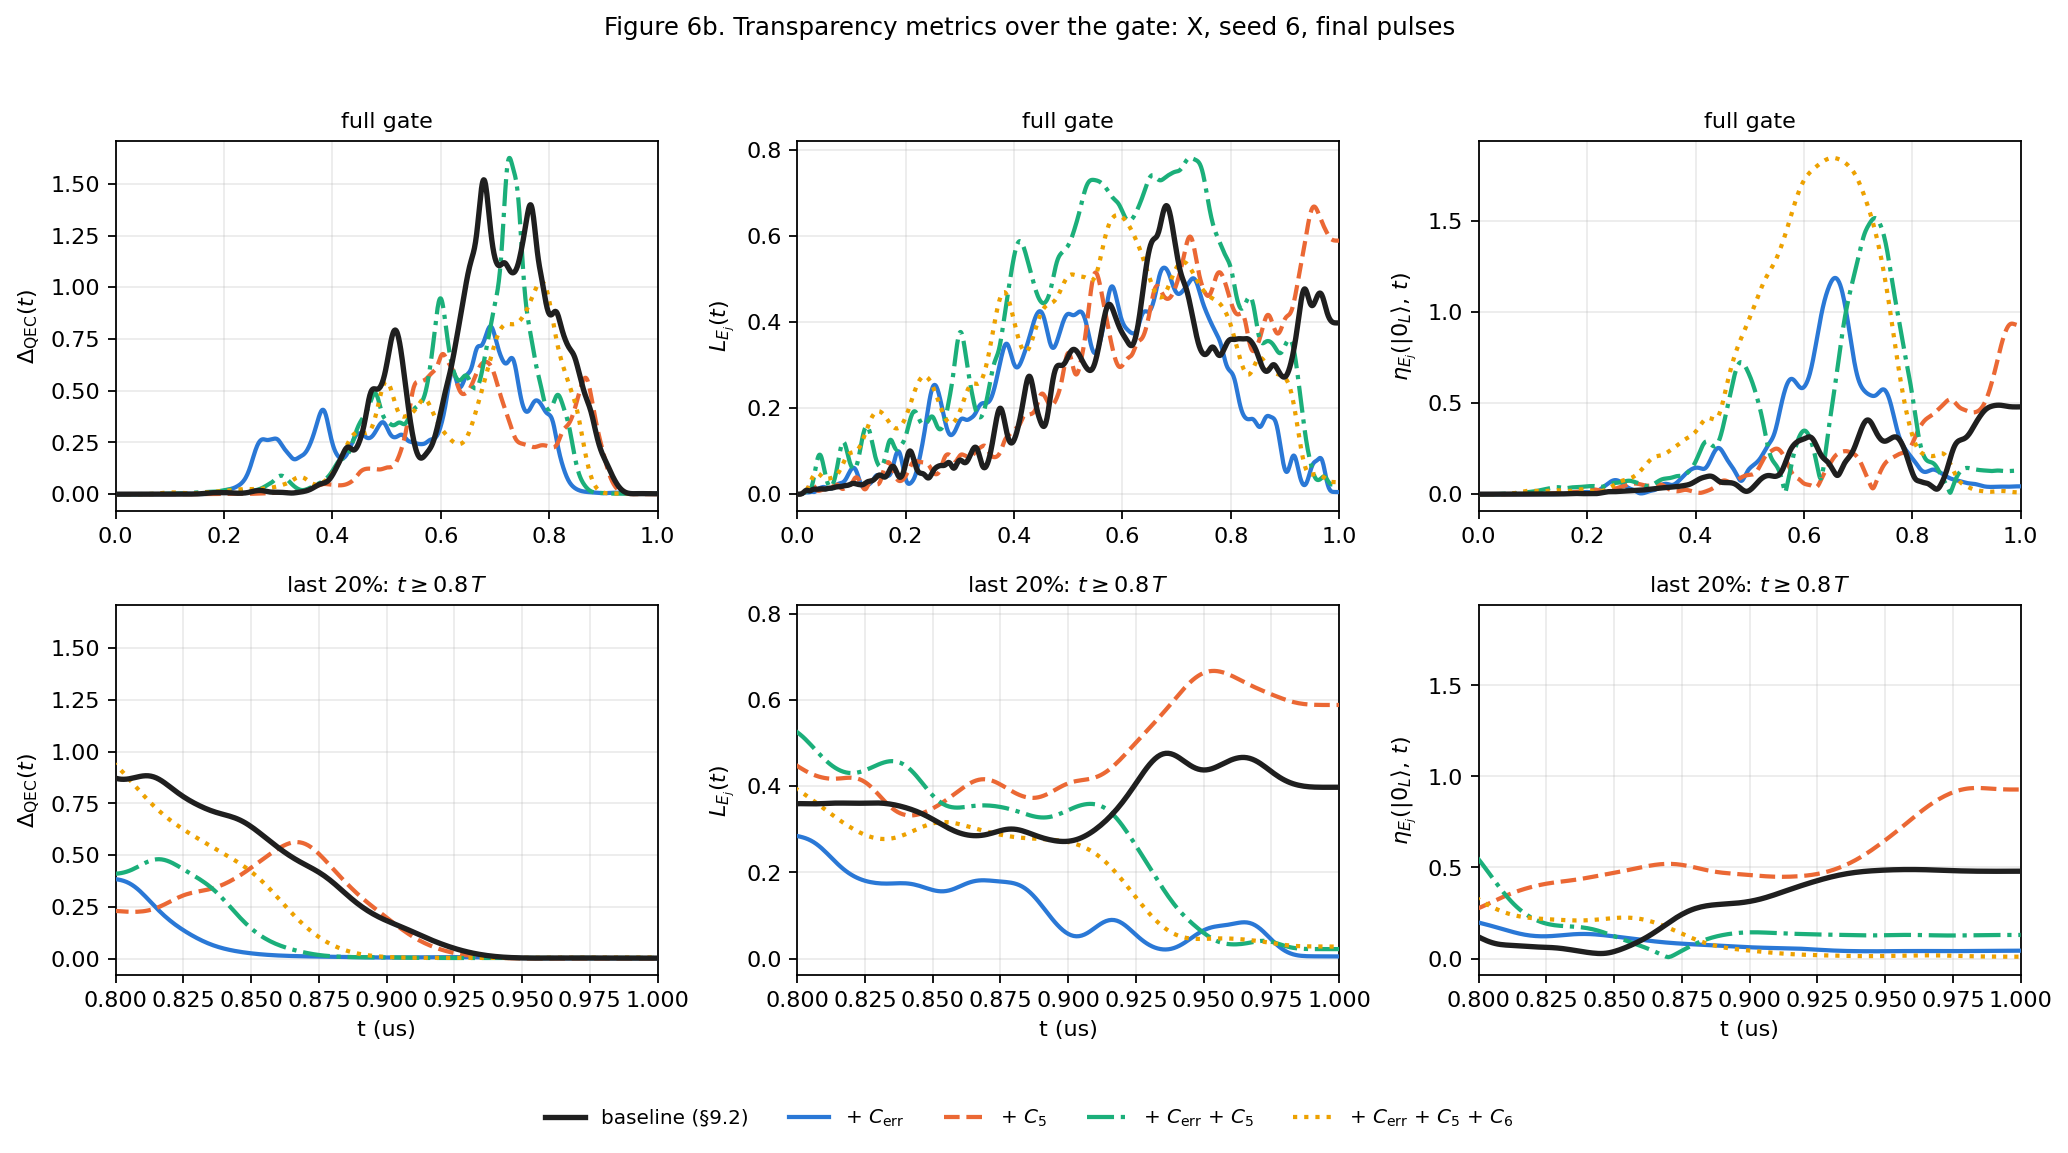

In [40]:
# Figure 6b: Eqs. 6-8 over the gate for the five final pulses; bottom row zooms to the end.
if nt_have:
    TR_COLS = [("dqec", r"$\Delta_{\rm QEC}(t)$"), ("L", r"$L_{E_j}(t)$"),
               ("eta0", r"$\eta_{E_j}(|0_L\rangle,\,t)$")]
    fig, axes = plt.subplots(2, 3, figsize=(13.0, 7.0), sharey="col")
    for c, (key, ylab) in enumerate(TR_COLS):
        for r in range(2):
            ax = axes[r, c]
            for run in NT_RUNS:
                t = ntr[f"{run}/final/t"]
                base = run == "baseline"
                ax.plot(t, ntr[f"{run}/final/{key}"], color=NT_COLOR[run], ls=NT_LS[run],
                        lw=2.4 if base else 1.9, zorder=4 if base else 3,
                        label=NT_LABEL[run])
            T = t[-1]
            ax.set_xlim((0.0 if r == 0 else 0.8 * T), T)
            ax.set_ylabel(ylab)
            ax.grid(alpha=0.25)
            ax.set_title(("full gate" if r == 0 else r"last 20%: $t \geq 0.8\,T$"), fontsize=10)
            if r == 1:
                ax.set_xlabel("t (us)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Figure 6b. Transparency metrics over the gate: X, seed 6, final pulses",
                 fontsize=11)
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    fig6b_path = os.path.join(FIG_DIR, "fig6b_newterms_traces_X.png")
    fig.savefig(fig6b_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig6b_path, width=980)

**Figure 6b. The three transparency metrics of Eqs. 6–8 over the gate, final pulses.**
Columns: $\Delta_{\rm QEC}(t)$, $L_{E_j}(t)$ and $\eta_{E_j}(|0_L\rangle, t)$. Top row: the full
1 us gate. Bottom row: its last 20%. The metrics and propagator are the same as in Figures 2 and 5.

1. **$C_{\rm err}$ fixes the endpoint.** Every run that contains it (blue, green, yellow) drives
   $L$ toward zero over the last 100 ns. `est_err` ends at $L(T) = 0.005$, against $0.398$ for
   the baseline and $0.013$ in the paper. $\eta(|0_L\rangle)$ follows at the end (tail $0.046$
   against $0.450$), but mid-gate it shows larger excursions than the baseline.
2. **$C_5$ acts mid-gate, not at the end.** `est_dn` (orange) lowers the $\Delta_{\rm QEC}$ peak
   but ends with more leakage than the baseline, $L(T) = 0.589$.
3. **The terms do not add.** `est_err_dn` keeps the endpoint gain ($L(T) = 0.022$) but leaks
   more mid-gate than either term alone: mean $L$ is $0.379$, against $0.231$ and $0.269$.

$\Delta_{\rm QEC}$ reaching zero at $t = T$ for every pulse is the artifact noted in [§5](#5):
a gate that lands on the code words has no Knill–Laflamme violation there.

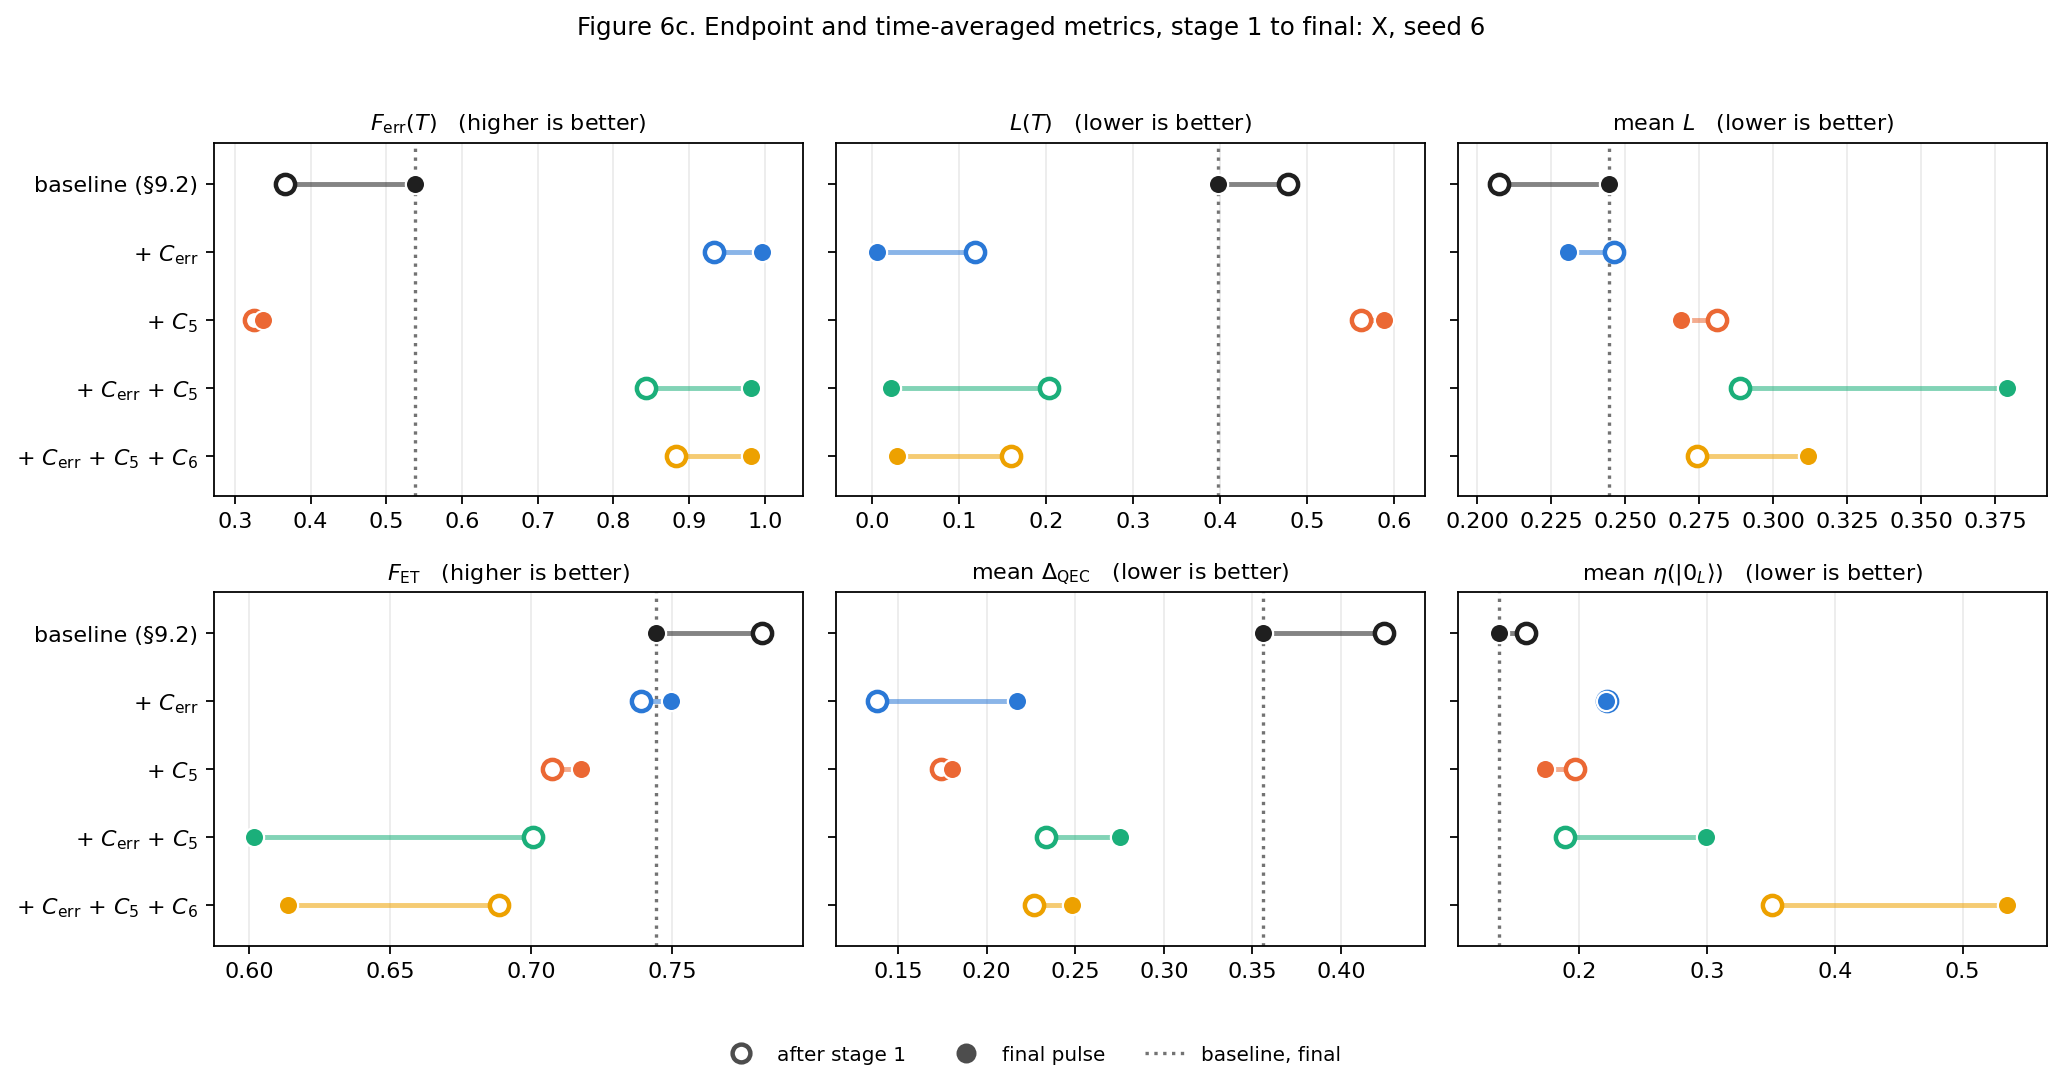

In [41]:
# Figure 6c: endpoint and time-averaged metrics per run, stage 1 (hollow) -> final (filled).
if nt_have:
    DB = [("F_err_T", r"$F_{\rm err}(T)$", "higher"), ("L_T", r"$L(T)$", "lower"),
          ("L_mean", r"mean $L$", "lower"), ("F_ET", r"$F_{\rm ET}$", "higher"),
          ("dqec_mean", r"mean $\Delta_{\rm QEC}$", "lower"),
          ("eta0_mean", r"mean $\eta(|0_L\rangle)$", "lower")]
    ypos = {run: i for i, run in enumerate(reversed(NT_RUNS))}      # baseline on top
    val = lambda run, stage, col: float(nt.loc[(nt.run == run) & (nt.stage == stage), col].iloc[0])

    fig, axes = plt.subplots(2, 3, figsize=(13.0, 6.6), sharey=True)
    for ax, (col, name, better) in zip(axes.ravel(), DB):
        ax.axvline(val("baseline", "final", col), color="0.45", ls=":", lw=1.5, zorder=1)
        for run in NT_RUNS:
            s1, s2, y = val(run, "stage1", col), val(run, "final", col), ypos[run]
            ax.plot([s1, s2], [y, y], color=NT_COLOR[run], lw=2.2, alpha=0.55, zorder=2)
            ax.scatter([s1], [y], s=75, facecolors="white", edgecolors=NT_COLOR[run],
                       linewidths=2.0, zorder=3)
            ax.scatter([s2], [y], s=75, color=NT_COLOR[run], edgecolors="white",
                       linewidths=1.0, zorder=4)
        ax.set_title(f"{name}   ({better} is better)", fontsize=10)
        ax.set_yticks(list(ypos.values()))
        ax.set_yticklabels([NT_LABEL[run] for run in ypos])
        ax.set_ylim(-0.6, len(NT_RUNS) - 0.4)
        ax.margins(x=0.08)
        ax.grid(alpha=0.25, axis="x")
    handles = [Line2D([], [], ls="", marker="o", ms=8, mfc="white", mec="0.3", mew=2,
                      label="after stage 1"),
               Line2D([], [], ls="", marker="o", ms=8, color="0.3", label="final pulse"),
               Line2D([], [], color="0.45", ls=":", lw=1.5, label="baseline, final")]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Figure 6c. Endpoint and time-averaged metrics, stage 1 to final: X, seed 6",
                 fontsize=11)
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    fig6c_path = os.path.join(FIG_DIR, "fig6c_newterms_summary_X.png")
    fig.savefig(fig6c_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig6c_path, width=980)

**Figure 6c. Endpoint and time-averaged metrics for every run.** Each panel is one metric.
A hollow marker is the pulse after stage 1, a filled marker the final pulse. The dotted line is
the baseline's final value.

`est_err` is the only run that beats the baseline at the endpoint without losing on the
averages:

| | $F_{\rm err}(T)$ | $L(T)$ | $F_{\rm ET}$ | mean $L$ | mean $\Delta_{\rm QEC}$ |
|---|---|---|---|---|---|
| `est_err` | $0.996$ | $0.005$ | $0.750$ | $0.231$ | $0.217$ |
| baseline | $0.538$ | $0.398$ | $0.744$ | $0.245$ | $0.356$ |

Its one loss is time-averaged $\eta(|0_L\rangle)$: $0.221$ against $0.138$. That metric is
where every added term costs something, and $C_6$ costs the most (`est_all`: $0.534$).

**Stage 2 differs by run.** In the baseline, stage 2 spends transparency to buy $F_1$
($F_{\rm ET}$ $0.782 \to 0.744$). In `est_err`, the terminal term holds the error trajectory,
and stage 2 improves both $F_{\rm ET}$ ($0.739 \to 0.750$) and $L(T)$ ($0.118 \to 0.005$). The
two combined runs lose $F_{\rm ET}$ in stage 2 ($0.70 \to 0.60$ and $0.69 \to 0.61$).

<a id="11.3"></a>
### 11.3 Final drive waveforms

Figures 6b–c score what the five final pulses do to the state. This subsection compares the
pulses themselves: the $I$ and $Q$ quadratures of the cavity and transmon drives, as delivered
(after the band limit, ramp and control mask). The drive magnitude $\sqrt{I^2+Q^2}$ is left out;
Figures 3 and 7a show it for other pulses.

**All five runs start from the same pre-image.** Seed 6 fixes the cold-start draw
(`EST/train_est_eigh.py`), so only the objective differs between runs.

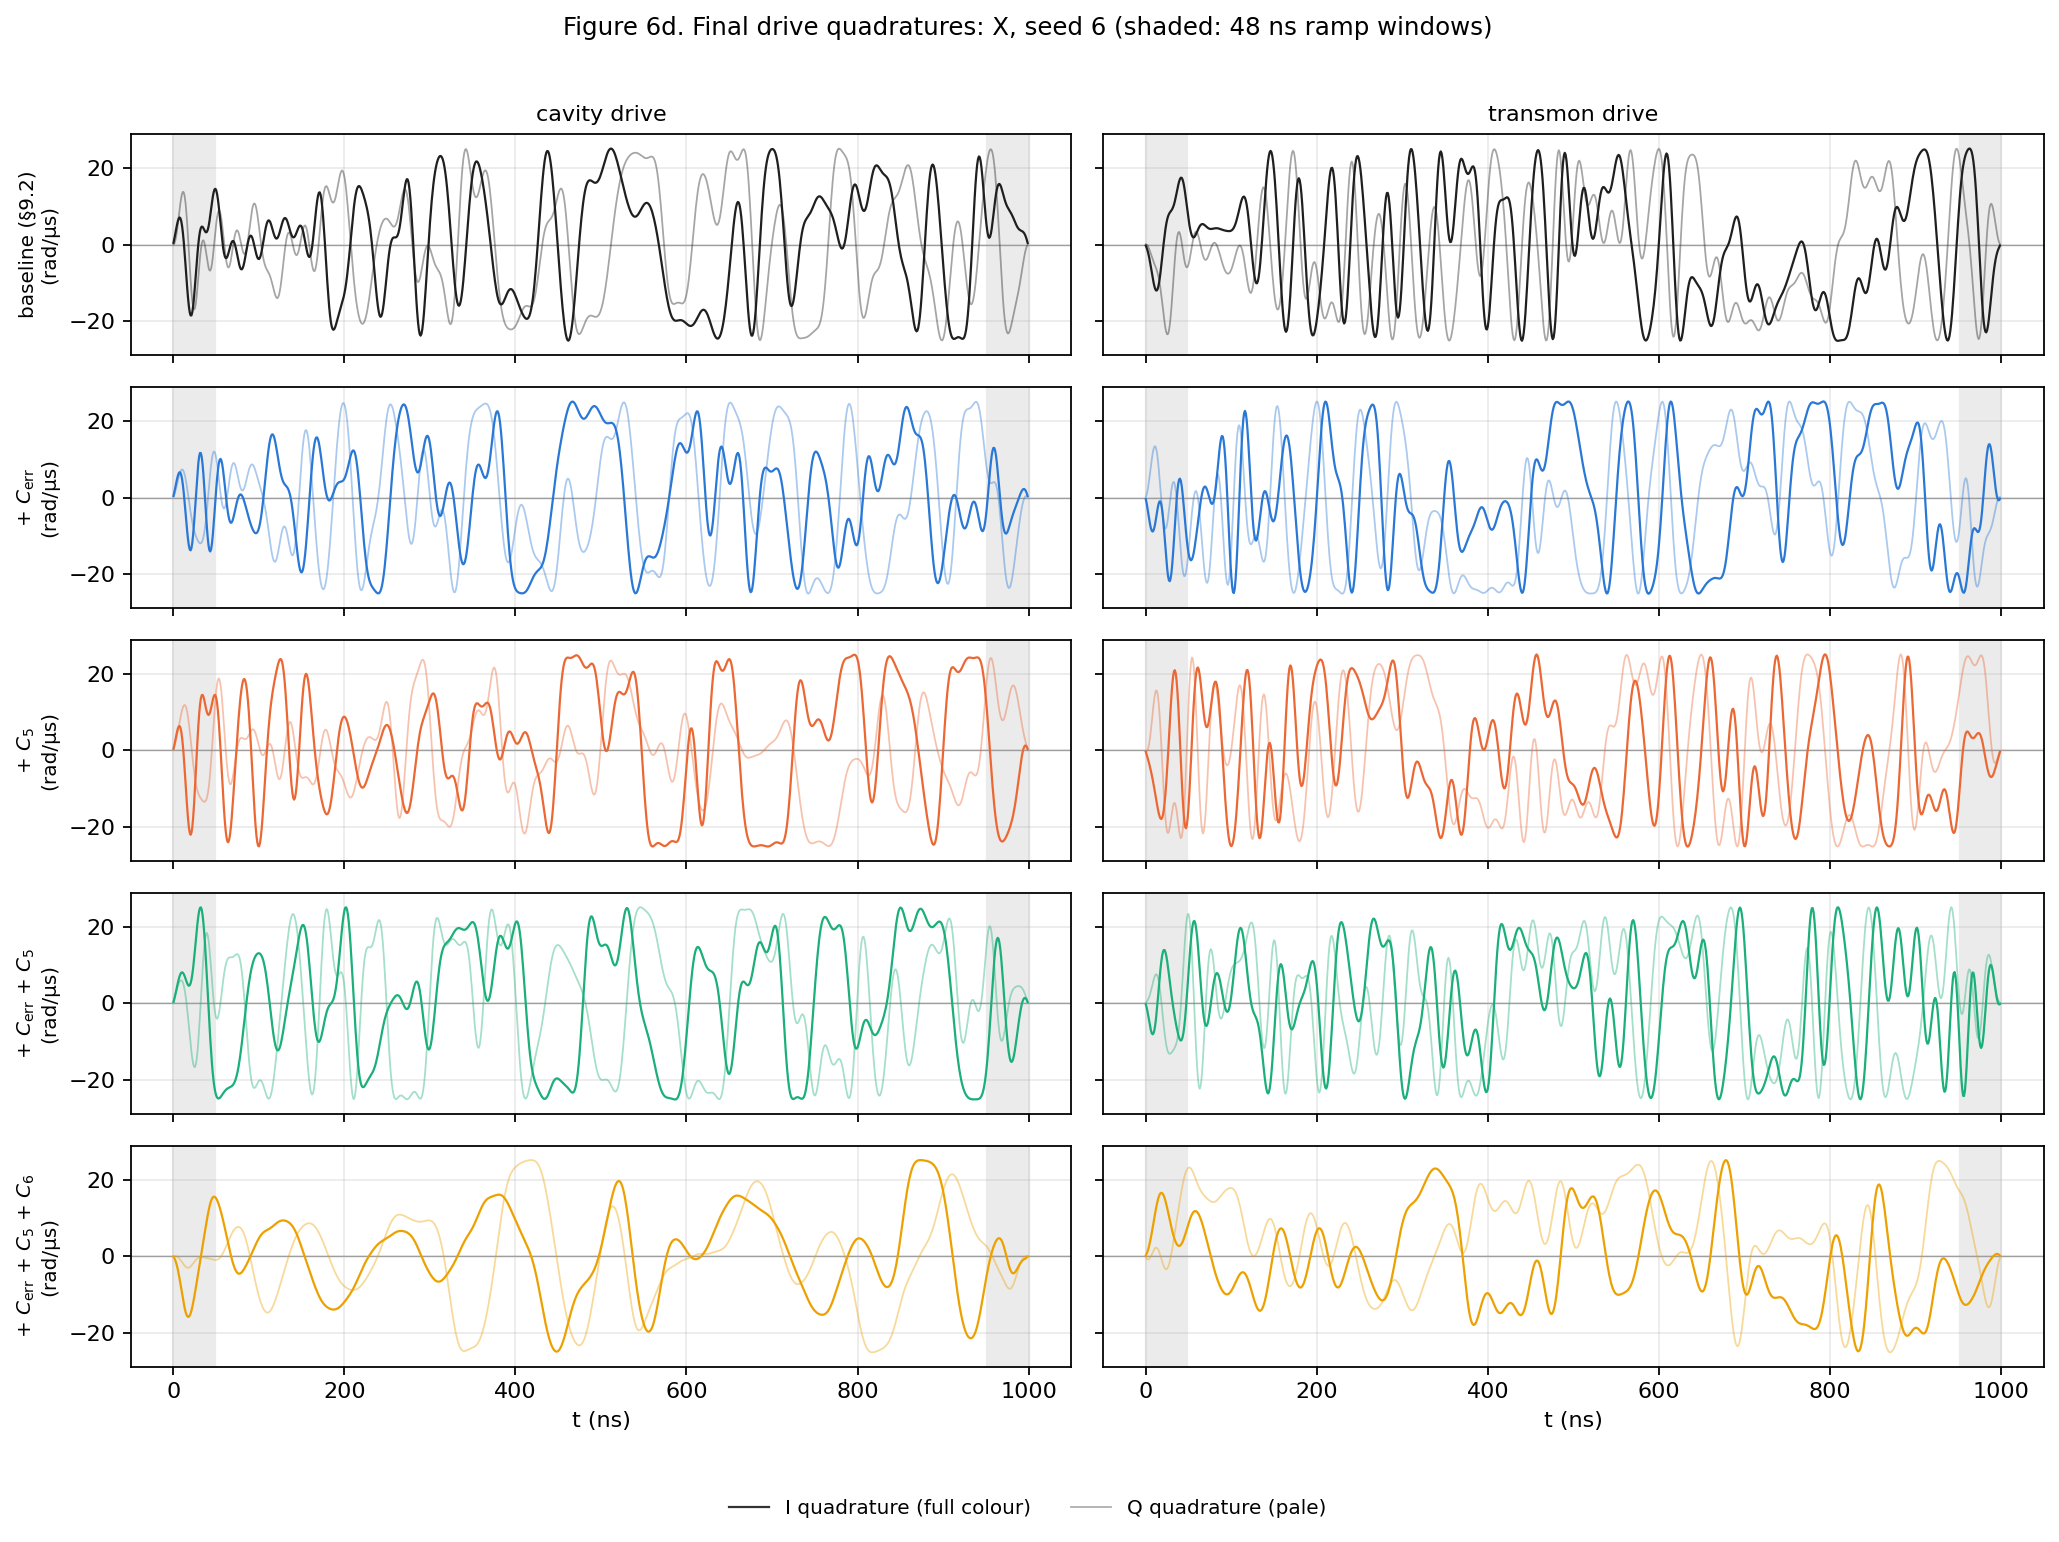

In [42]:
# Figure 6d: the I and Q quadratures of both drives for the five final pulses, one row per run.
# The drive magnitude is deliberately not drawn (Figures 3 and 7a show it); this is the waveform.
if nt_have:
    NT_U = {run: np.load(os.path.join(PULSE_DIR, f"u_X_{stem}.npy")) for run, stem in cnt.RUNS}
    NT_DRIVES = [(0, "cavity"), (2, "transmon")]

    fig, axes = plt.subplots(len(NT_RUNS), 2, figsize=(13.0, 1.9 * len(NT_RUNS)),
                             sharex=True, sharey=True, squeeze=False)
    for r, run in enumerate(NT_RUNS):
        u = NT_U[run]
        N = len(u)
        t_ns = np.arange(N) * device.DT * 1e3
        T_ns = N * device.DT * 1e3
        for c, (lo, name) in enumerate(NT_DRIVES):
            ax = axes[r, c]
            for x0, x1 in ((0.0, device.RAMP_NS), (T_ns - device.RAMP_NS, T_ns)):
                ax.axvspan(x0, x1, color="0.92", zorder=0)
            ax.axhline(0, color="0.6", lw=0.6, zorder=1)
            ax.plot(t_ns, u[:, lo], color=NT_COLOR[run], lw=1.0, zorder=3)
            ax.plot(t_ns, u[:, lo + 1], color=NT_COLOR[run], lw=0.8, alpha=0.4, zorder=2)
            ax.set_ylim(-1.15 * device.EPS_MAX, 1.15 * device.EPS_MAX)
            ax.grid(alpha=0.25)
            if r == 0:
                ax.set_title(f"{name} drive", fontsize=10)
            if c == 0:
                ax.set_ylabel(NT_LABEL[run] + "\n(rad/μs)", fontsize=9)
    for ax in axes[-1]:
        ax.set_xlabel("t (ns)")
    handles = [Line2D([], [], color="0.2", lw=1.0, label="I quadrature (full colour)"),
               Line2D([], [], color="0.2", lw=0.8, alpha=0.4, label="Q quadrature (pale)")]
    fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Figure 6d. Final drive quadratures: X, seed 6 "
                 f"(shaded: {device.RAMP_NS:.0f} ns ramp windows)", fontsize=11)
    fig.tight_layout(rect=(0, 0.03, 1, 0.97))
    fig6d_path = os.path.join(FIG_DIR, "fig6d_newterms_quadratures_X.png")
    fig.savefig(fig6d_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig6d_path, width=980)

**Figure 6d. Delivered drive quadratures of the five final pulses.** Rows: runs, in Table 19's
order. Columns: cavity drive, transmon drive. Full colour: $I$; pale: $Q$. All panels share axes;
shading marks the 48 ns ramp windows.

- **Every run uses the full amplitude range.** Each quadrature of every pulse reaches
  $\pm 25$ rad/μs, the $C_4$ cap.
- **Four of the five waveforms are alike in character but not in detail.** The baseline,
  `est_err`, `est_dn` and `est_err_dn` are fast, near-bang-bang waveforms, with 26–46 zero
  crossings of $I$ per gate. Their shapes do not line up.
- **$C_6$ is the only term that visibly changes the waveform.** `est_all` crosses zero 20 times on
  each drive. Its rms step between samples, $|\varepsilon_{k+1}-\varepsilon_k|$, is 2.3–2.4x smaller than
  `est_err_dn`'s, the same run without $C_6$ (cavity $0.92$ against $2.19$ rad/μs; transmon $1.25$
  against $2.84$).

<a id="11.4"></a>
### 11.4 Conclusion and caveats

**The endpoint leak of limitation 3 is a gap in the objective, not a limit of the device.** One
terminal error-space term ($w_{\rm err} = 0.3$) takes X's $L(T)$ from $0.398$ to $0.005$. Over
the same change, $F_1$ ($0.9995$), $F_{\rm ET}$ ($0.750$) and $\Delta_{\rm QEC}$ ($0.217$) hold
or improve. The other two terms do different jobs:
- **$C_5$ reduces $\Delta_{\rm QEC}$, not leakage.**
- **$C_6$ smooths the pulse, at a cost in $\eta$.** Adding it to `est_err_dn` lowers $C_6$
  5.4x and out-of-band energy from $4.2\times10^{-3}$ to $2.1\times10^{-4}$. $F_{\rm ET}$, mean
  $L$ and mean $\Delta_{\rm QEC}$ improve slightly, but mean $\eta(|0_L\rangle)$ worsens from
  $0.299$ to $0.534$.

Caveats:
- **One seed, one gate, for the full runs.** The 500-it scan of Figure 6a covers six seeds; the
  2000-it runs of §11.2 are seed 6 only. $F_{\rm ET}$ differences below the §9 seed sd ($0.028$)
  are not results; the 80x change in $L(T)$ is.
- **The weights are ballparks.** They were chosen from a single-seed 500-it scan by a rule
  revised after seeing it. The six-seed scan of Figure 6a checks that choice; the full runs were
  not retrained from it. The two terms were never scanned jointly.
- **$L$ here is closed-system and lossless.** It is not the paper's master-equation ET fidelity
  (limitation 1).
- **Every pulse, the baseline included, ends with its raw pre-image at `hard_bound` = 60.** The
  physical amplitude cap ($C_4$) holds.
- **Not yet run:** an `ord` control at seed 6, the H and T gates, and more seeds.

<a id="12"></a>
# 12. Evening out the T-gate drive: stage-2 $C_3$ and $C_6$

Figure 3c's T pulse finishes the gate at the very end. On §9.2's `u_T_est_best2000` (eigh, seed 1,
2000 it/stage), **35% of the transmon drive energy falls in the closing 48 ns ramp window**, the
peak $|\varepsilon_T| = 25.1$ rad/μs sits at $t = 584$ ns, and fidelity to the target is only
$0.912$ when that window opens. Its stage-1 pulse had 9% there. The end-loading is made in
**stage 2**, the stage that drops $w_3$ to 0.

<a id="12.1"></a>
### 12.1 Method

Three stage-2-only changes (`STAGE2_VARIANTS` in `EST/train_est_eigh.py`). Stage 1 is `est`'s
stage 1 in every run, so at the same seed it is the same stage 1, and §9.2's run is the control:

| run | stage 1 $(w_1,w_2,w_3,w_4)$ | stage 2 $(w_1,w_2,w_3,w_4;\,w_6)$ |
|---|---|---|
| control (`est_best2000`) | $(1, 0.7, 7, 1)$ | $(1, 0.1, \mathbf{0}, 1;\ 0)$ |
| `est_c3s2` | same | $(1, 0.1, \mathbf{7}, 1;\ 0)$ |
| `est_d2` | same | $(1, 0.1, 0, 1;\ \mathbf{w_6})$ |
| `est_c3s2_d2` | same | $(1, 0.1, \mathbf{7}, 1;\ \mathbf{w_6})$ |

**Table 20a. The runs.** T gate, seed 1, cold start, 2000 it/stage, eigh + hand-derived adjoint,
$n_c = 20$. $C_6 = \sum_k \lVert u_{k+1}-u_k\rVert^2$ is §11's smoothness term on the physical pulse.

**Choosing $w_6$.** $C_6 \approx 500$ on the control and the whole stage-2 cost is $\approx 5.5\times10^{-3}$,
so §11's X weight means something different here. `est_d2` was screened at
$w_6 \in \{5\times10^{-6}, 2\times10^{-5}, 10^{-4}\}$ (500 it/stage, seed 1; control §9's
`u_T_est_seed1`, the same seed and budget). The rule was fixed before any screen run finished: the **largest**
$w_6$ with $F_1 \ge 0.9999$, less drive energy in the closing ramp window than the control, and
$F_{\rm ET}$ no more than 0.05 below it. It selected $w_6 = 10^{-4}$ (Table 20b), and configs 2 and 3 use that weight.

**What $C_3$ can and cannot see.** $C_3$ penalizes uneven *state speed*, not drive amplitude. On the
control, the mean speed in the closing window is $1.2\times$ the mid-gate speed, so the spike is not a
large speed outlier. `est_c3s2` tests whether holding speed uniform is enough anyway.

**Which transparency metrics can move on T.** $\Delta_{\rm QEC}$ and $\eta(|0_L\rangle)$ are at
machine zero for *every* T pulse ([§5](#5), Figure 5c): a diagonal gate driven through the transmon
alone cannot make them anything else. Table 21 and Figure 7c therefore compare what can move: $F_{\rm ET}$,
$L_{E_j}$, the six-cardinal $\eta$, the map mismatch $\mathcal{M}$ ([§4](#4)), and $F_{\rm err}(T)$.

```
python EST/stage2_t.py commands   # the seven training commands
python EST/stage2_t.py scan       # Table 20b
python EST/stage2_t.py compare    # Table 21, Figures 7a-c
```

In [43]:
# §12 setup, then Tables 20b and 21. Encoding shared by Figures 7a-c: the control in near-black,
# the three runs in fixed categorical slots, each with its own line style.
import importlib
from EST import grape_eigh, train_est_eigh, compare_new_terms, stage2_t
for _mod in (grape_eigh, train_est_eigh, compare_new_terms, stage2_t):
    importlib.reload(_mod)     # train_est_eigh binds build_gate_objective by name: after grape_eigh

S2_RUNS = [label for label, _ in stage2_t.FULL_RUNS]
S2_LABEL = {"control": r"control: stage 2 $w_3 = 0$ (§9.2)", "c3s2": r"stage 2 keeps $w_3 = 7$",
            "d2": r"stage 2 + $C_6$", "c3s2_d2": r"stage 2 $w_3 = 7$ + $C_6$"}
S2_COLOR = {"control": "#1f1f1f", "c3s2": "#2a78d6", "d2": "#eb6834", "c3s2_d2": "#1baf7a"}
S2_LS = {"control": "-", "c3s2": "-", "d2": "--", "c3s2_d2": "-."}

_scan_files = [stage2_t._paths(stage2_t._scan_stem(w))[0] for w in stage2_t.SCAN_W6]
if all(os.path.exists(p) for p in _scan_files) and (
        REGENERATE_FIGURES or not os.path.exists(stage2_t.SCAN_CSV)):
    stage2_t.scan()
if REGENERATE_FIGURES or not os.path.exists(stage2_t.CSV_PATH):
    stage2_t.compare()

if os.path.exists(stage2_t.SCAN_CSV):
    s2scan = pd.read_csv(stage2_t.SCAN_CSV)
    display(s2scan[["run", "w6", "selected", "gate_ok", "end_ok", "et_ok", "F1", "F_ET",
                    "E_ramp_end", "t_peak_ns", "c6", "L_T"]]
            .style.format({"w6": "{:g}", "F1": "{:.6f}", "F_ET": "{:.4f}", "E_ramp_end": "{:.3f}",
                           "t_peak_ns": "{:.0f}", "c6": "{:.0f}", "L_T": "{:.4f}"}, na_rep="-")
            .hide(axis="index"))

s2 = pd.read_csv(stage2_t.CSV_PATH)
s2tr = np.load(stage2_t.TRACES_PATH)
s2_have = [r for r in S2_RUNS if ((s2.run == r) & (s2.stage == "final")).any()]
T21_COLS = ["run", "stage", "F1", "F_ET", "c3", "c6", "E_0_100", "E_ramp_end", "t50_ns", "t90_ns",
            "t_peak_ns", "peak_eps_T", "v_ramp_end_over_mid", "F_before_ramp_end", "F_err_T",
            "L_mean", "L_T", "eta_avg_mean", "eta_avg_tail", "eta_avg_T", "M_mean", "M_T",
            "oob_transmon", "heldout_spread", "stage1_dx_vs_control"]
t21 = (s2.assign(_run=s2.run.map({r: i for i, r in enumerate(S2_RUNS)}), _stage=(s2.stage == "stage1"))
         .sort_values(["_stage", "_run"])[[c for c in T21_COLS if c in s2]])
display(t21.style.format({
    "F1": "{:.6f}", "F_ET": "{:.4f}", "c3": "{:.4f}", "c6": "{:.0f}", "E_0_100": "{:.3f}",
    "E_ramp_end": "{:.3f}", "t50_ns": "{:.0f}", "t90_ns": "{:.0f}", "t_peak_ns": "{:.0f}",
    "peak_eps_T": "{:.2f}", "v_ramp_end_over_mid": "{:.2f}", "F_before_ramp_end": "{:.4f}",
    "F_err_T": "{:.4f}", "L_mean": "{:.4f}", "L_T": "{:.4f}", "eta_avg_mean": "{:.4f}",
    "eta_avg_tail": "{:.4f}", "eta_avg_T": "{:.4f}", "M_mean": "{:.2e}", "M_T": "{:.2e}",
    "oob_transmon": "{:.4f}",
    "heldout_spread": "{:.1e}", "stage1_dx_vs_control": "{:.1e}"}, na_rep="-").hide(axis="index"))
print("final pulses present:", s2_have)

control   final   F1=0.999982 F_ET=0.9449 c3=0.2016 L(T)=0.1164 eta6=0.0371 M(T)=8.27e-03 E_end=0.369 t_peak=582ns c6=420
w6=5e-06  final   F1=0.999978 F_ET=0.9436 c3=0.1905 L(T)=0.0966 eta6=0.0383 M(T)=7.39e-03 E_end=0.193 t_peak=584ns c6=58
w6=2e-05  final   F1=0.999972 F_ET=0.9421 c3=0.2007 L(T)=0.0770 eta6=0.0354 M(T)=5.49e-03 E_end=0.131 t_peak=582ns c6=41
w6=0.0001 final   F1=0.999936 F_ET=0.9392 c3=0.2140 L(T)=0.0480 eta6=0.0268 M(T)=1.80e-03 E_end=0.072 t_peak=304ns c6=34

table -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/tables/est_stage2_T_seed1_scan.csv
selected w6: 0.0001
control   stage1  F1=0.965907 F_ET=0.9213 c3=0.0107 L(T)=0.1211 eta6=0.0413 M(T)=6.16e-03 E_end=0.092 t_peak=56ns c6=489
control   final   F1=0.999982 F_ET=0.9453 c3=0.2017 L(T)=0.1201 eta6=0.0363 M(T)=8.33e-03 E_end=0.354 t_peak=584ns c6=526
c3s2      stage1  F1=0.965907 F_ET=0.9213 c3=0.0107 L(T)=0.1211 eta6=0.0413 M(T)=6.16e-03 E_end=0.092 t_peak=56ns c6=489
c3s2      final   F1=0.979411 

run,w6,selected,gate_ok,end_ok,et_ok,F1,F_ET,E_ramp_end,t_peak_ns,c6,L_T
control,0,False,-,-,-,0.999982,0.9449,0.369,582,420,0.1164
est_d2,5e-06,False,True,True,True,0.999978,0.9436,0.193,584,58,0.0966
est_d2,2e-05,False,True,True,True,0.999972,0.9421,0.131,582,41,0.0770
est_d2,0.0001,True,True,True,True,0.999936,0.9392,0.072,304,34,0.0480


run,stage,F1,F_ET,c3,c6,E_0_100,E_ramp_end,t50_ns,t90_ns,t_peak_ns,peak_eps_T,v_ramp_end_over_mid,F_before_ramp_end,F_err_T,L_mean,L_T,eta_avg_mean,eta_avg_tail,eta_avg_T,M_mean,M_T,oob_transmon,heldout_spread,stage1_dx_vs_control
control,final,0.999982,0.9453,0.2017,526,0.155,0.354,458,587,584,25.13,1.22,0.9119,0.8735,0.0541,0.1201,0.0363,0.0987,0.1229,3.73e-03,8.33e-03,0.0751,4.9e-14,-
c3s2,final,0.979411,0.8725,0.0103,428,0.399,0.134,231,569,56,22.12,0.91,0.8225,0.7780,0.1249,0.2223,0.0741,0.0942,0.0378,6.40e-03,1.30e-02,0.0175,3.9e-14,-
d2,final,0.999936,0.9392,0.2140,34,0.033,0.071,351,511,304,6.74,0.34,0.9722,0.9499,0.0605,0.0480,0.0268,0.0474,0.0605,5.42e-03,1.80e-03,0.0002,1.9e-14,-
c3s2_d2,final,0.977956,0.8578,0.0088,127,0.258,0.208,308,580,12,17.44,0.91,0.8656,0.9531,0.1412,0.0353,0.0509,0.0261,0.0558,1.67e-03,9.91e-05,0.0118,1.2e-14,-
control,stage1,0.965907,0.9213,0.0107,489,0.517,0.092,93,538,56,22.16,0.92,0.8880,0.8239,0.0778,0.1211,0.0413,0.0467,0.1002,4.73e-03,6.16e-03,0.0275,3.2e-14,0.0e+00
c3s2,stage1,0.965907,0.9213,0.0107,489,0.517,0.092,93,538,56,22.16,0.92,0.8880,0.8239,0.0778,0.1211,0.0413,0.0467,0.1002,4.73e-03,6.16e-03,0.0275,3.2e-14,0.0e+00
d2,stage1,0.965907,0.9213,0.0107,489,0.517,0.092,93,538,56,22.16,0.92,0.8880,0.8239,0.0778,0.1211,0.0413,0.0467,0.1002,4.73e-03,6.16e-03,0.0275,3.2e-14,0.0e+00
c3s2_d2,stage1,0.965907,0.9213,0.0107,489,0.517,0.092,93,538,56,22.16,0.92,0.8880,0.8239,0.0778,0.1211,0.0413,0.0467,0.1002,4.73e-03,6.16e-03,0.0275,3.2e-14,0.0e+00


final pulses present: ['control', 'c3s2', 'd2', 'c3s2_d2']


**Table 20b. The $w_6$ screen** (T, seed 1, 500 it/stage, `est_d2`; control §9's `u_T_est_seed1`).
All three weights pass all three criteria, so the rule takes the largest, $w_6 = 10^{-4}$, which is
the top of the pre-set grid ([§12.3](#12.3)). Closing-window energy falls monotonically
(36.9% → 19.3% → 13.1% → 7.2%), and so do $L(T)$ (0.116 → 0.048) and $\mathcal{M}(T)$
($8.3\times10^{-3} \to 1.8\times10^{-3}$), while $F_{\rm ET}$ goes 0.9449 → 0.9392.

**Table 21. All four runs at 2000 it/stage**, final pulses first. `stage1_dx_vs_control` is exactly
0.0 for every run: the three variants' stage-1 pre-image is bit-identical to the control's, so every
difference here is made in stage 2. Only the control and `est_d2` reach the gate. Both $w_3 = 7$
runs stop on `maxiter` at $F_1 \approx 0.98$.

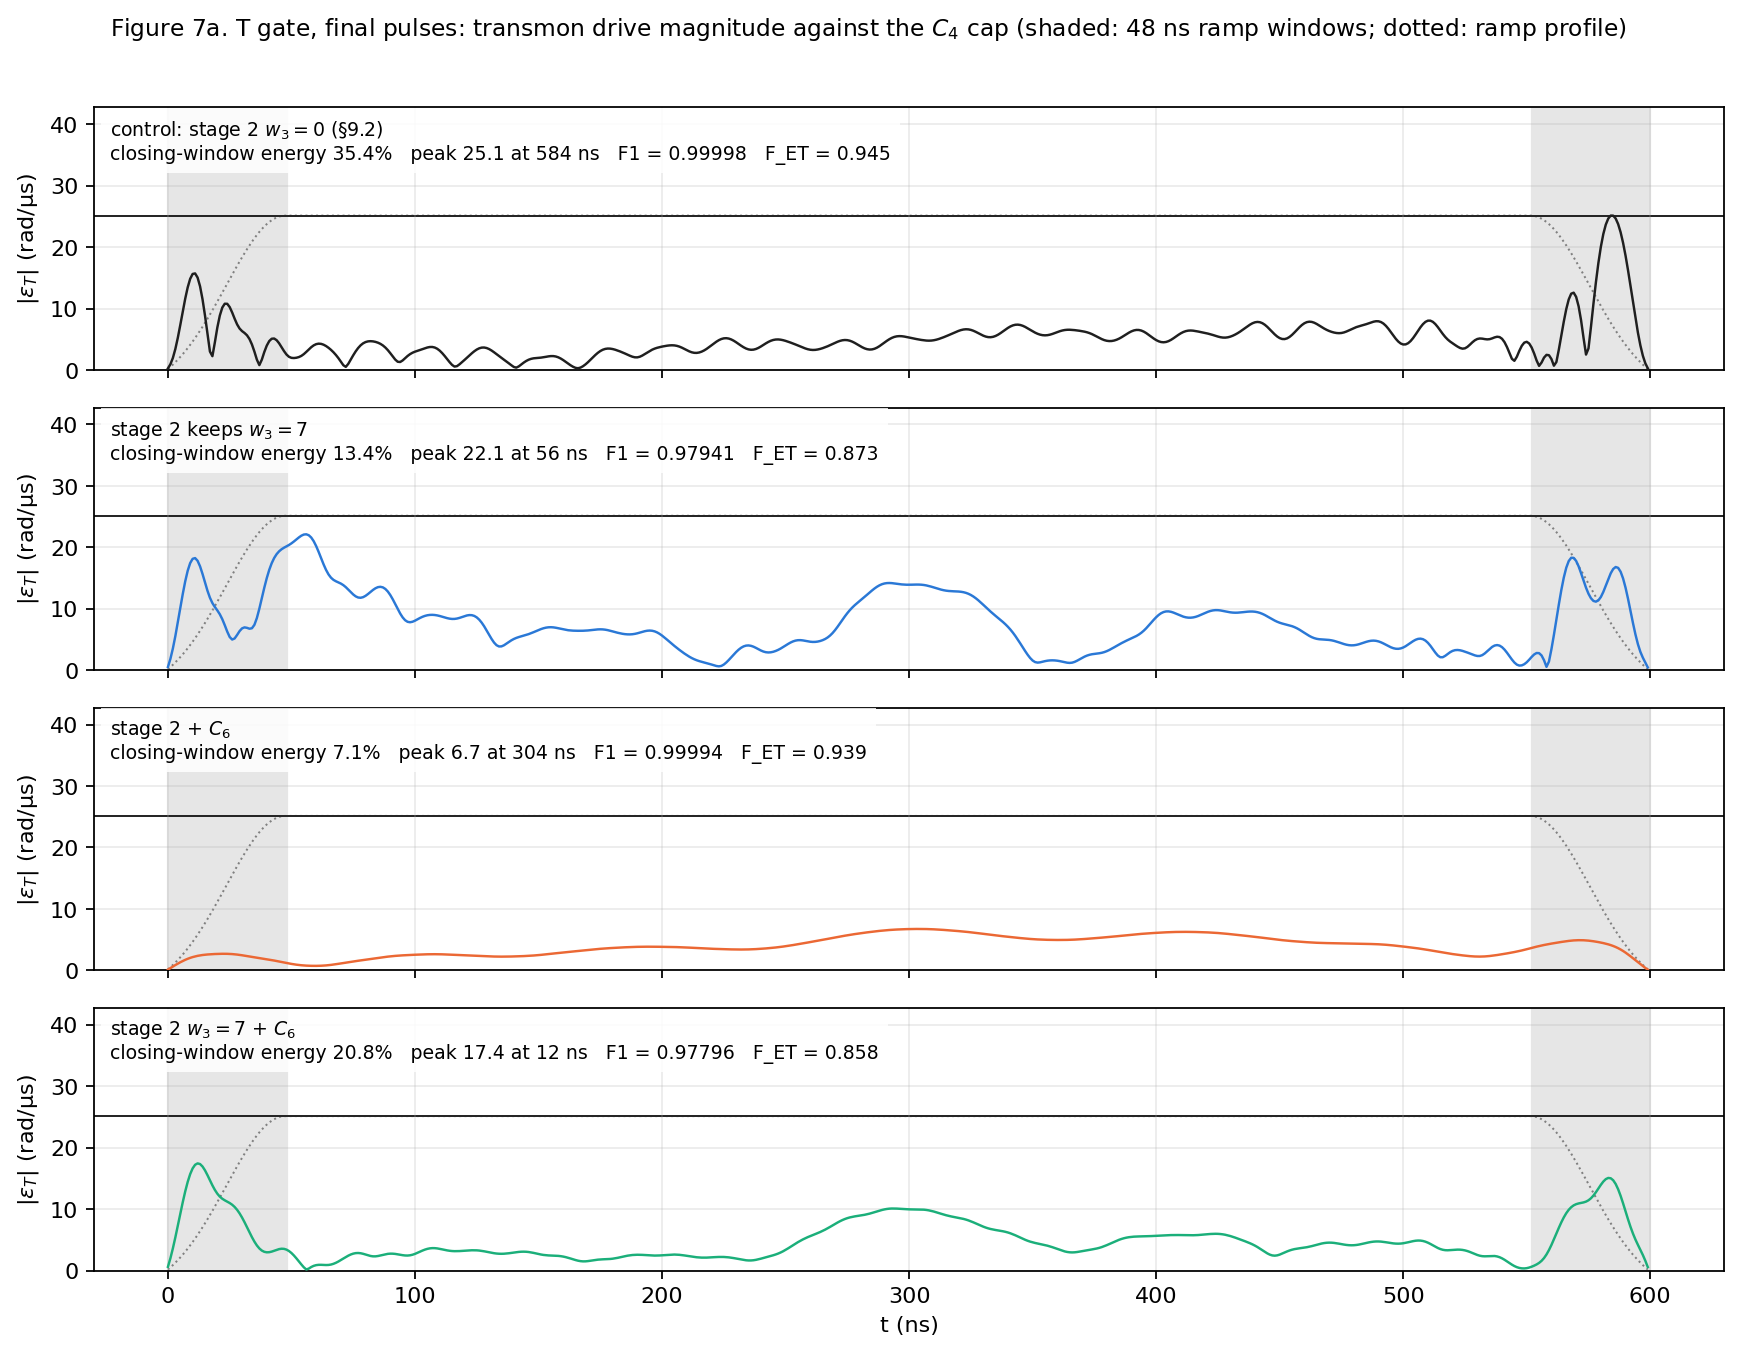

In [44]:
# Figure 7a: the transmon drive magnitude of every final pulse, one row each, same axes.
if s2_have:
    N_RAMP12 = int(round(device.RAMP_NS * 1e-3 / device.DT))
    fig, axes = plt.subplots(len(s2_have), 1, figsize=(11.0, 2.15 * len(s2_have)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, run in zip(axes[:, 0], s2_have):
        eps = s2tr[f"{run}/final/eps_T"]
        N = len(eps)
        t_ns = np.arange(N) * device.DT * 1e3
        T_ns = N * device.DT * 1e3
        for x0, x1 in ((0.0, device.RAMP_NS), (T_ns - device.RAMP_NS, T_ns)):
            ax.axvspan(x0, x1, color="0.9", zorder=0)
        ax.plot(t_ns, device.ramp_envelope(N, device.DT) * device.EPS_MAX, color="0.5", lw=0.9,
                ls=":", zorder=1)
        ax.axhline(device.EPS_MAX, color="0.15", lw=0.9, zorder=1)
        ax.plot(t_ns, eps, color=S2_COLOR[run], lw=1.1, zorder=3)
        r = s2[(s2.run == run) & (s2.stage == "final")].iloc[0]
        ax.text(0.01, 0.96, f"{S2_LABEL[run]}\nclosing-window energy {r.E_ramp_end:.1%}   "
                f"peak {r.peak_eps_T:.1f} at {r.t_peak_ns:.0f} ns   F1 = {r.F1:.5f}   "
                f"F_ET = {r.F_ET:.3f}", transform=ax.transAxes, va="top", fontsize=8.5,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
        ax.set_ylim(0, device.EPS_MAX * 1.7)
        ax.set_ylabel(r"$|\varepsilon_T|$ (rad/μs)")
        ax.grid(alpha=0.25)
    axes[-1, 0].set_xlabel("t (ns)")
    fig.suptitle("Figure 7a. T gate, final pulses: transmon drive magnitude against the $C_4$ cap "
                 "(shaded: 48 ns ramp windows; dotted: ramp profile)", fontsize=10.5)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig7a_path = os.path.join(FIG_DIR, "fig7a_stage2_waveforms_T.png")
    fig.savefig(fig7a_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig7a_path, width=900)

**Figure 7a. Transmon drive magnitude, final pulses.**
- **Control (black):** small and flat mid-gate, then a spike to the cap at 584 ns, with 35.4% of the
  energy in the closing window.
- **`est_d2` (orange) is the only even drive.** Nothing exceeds 6.7 rad/μs, the largest feature is
  mid-gate, and it tapers cleanly into both ramp windows. It puts 7.1% of its energy in a window that is
  8% of the gate. Out-of-band transmon energy falls from 7.5% to 0.016%.
- **Both $w_3 = 7$ runs (blue, green) move the spike rather than remove it.** The peak migrates to the
  opening window (56 ns and 12 ns), and a second burst remains at the end. Their closing-window
  fractions (13.4%, 20.8%) are below the control's only because they never make the final correction:
  see $F_1$.

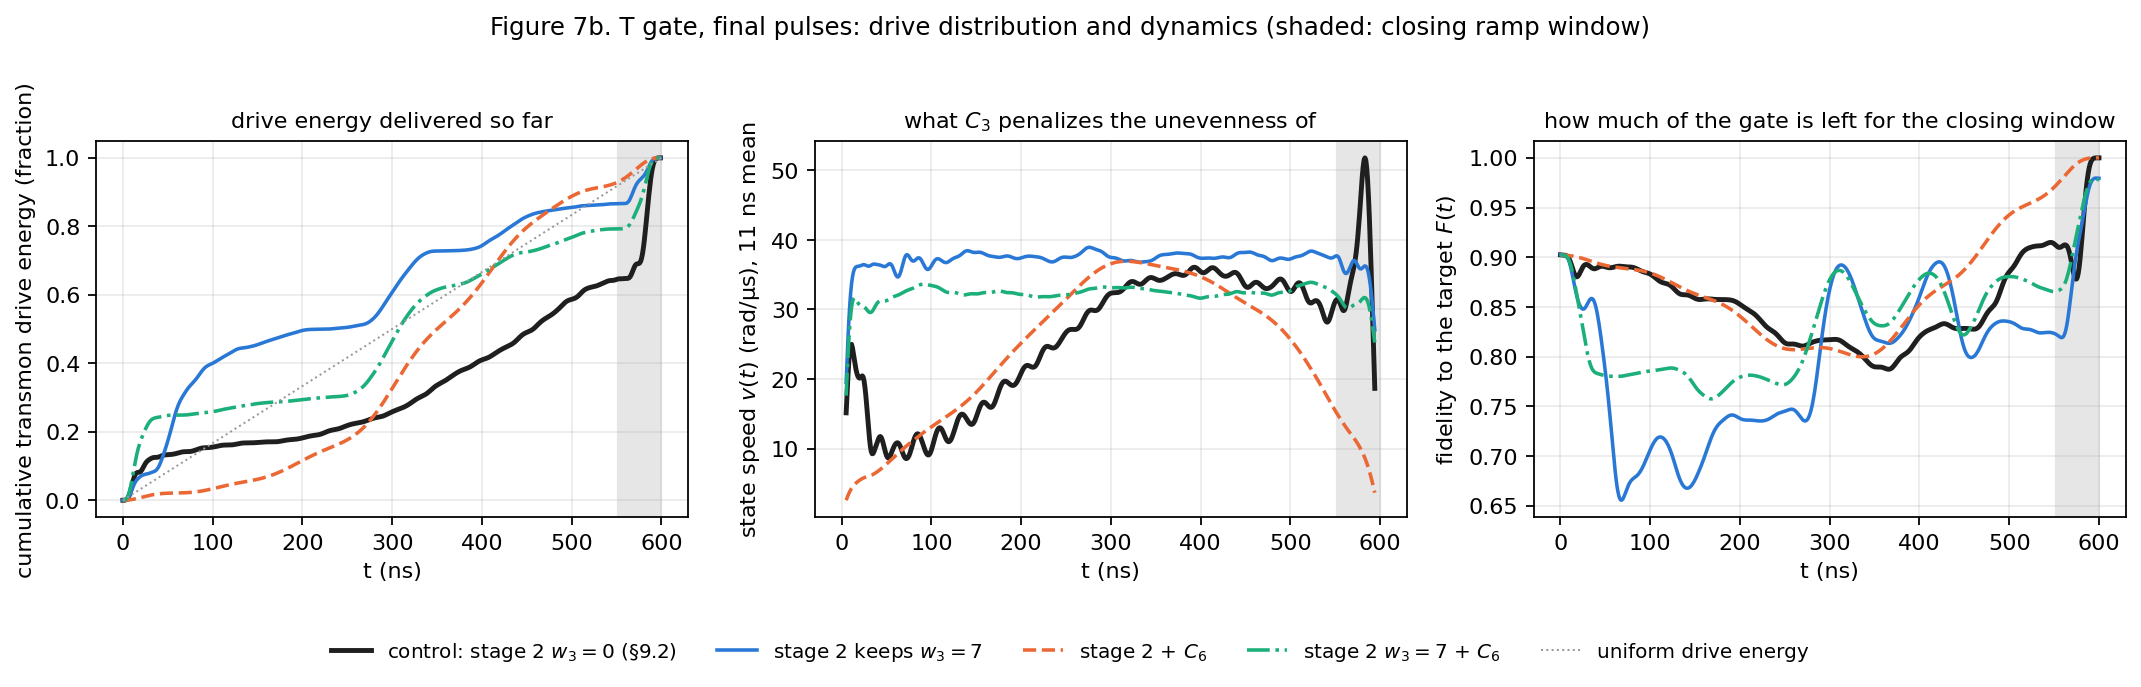

In [45]:
# Figure 7b: when the drive is spent, how fast the state moves, and when the gate is done.
if s2_have:
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharex=True)
    for run in s2_have:
        kw = dict(color=S2_COLOR[run], ls=S2_LS[run], lw=2.2 if run == "control" else 1.6,
                  label=S2_LABEL[run])
        cum = s2tr[f"{run}/final/E_cum"]
        t_ns = np.arange(len(cum)) * device.DT * 1e3
        axes[0].plot(t_ns, cum, **kw)
        v = s2tr[f"{run}/final/v"]
        k = 11                                             # 11 ns running mean, for legibility only
        axes[1].plot(t_ns[k // 2:len(v) - k // 2], np.convolve(v, np.ones(k) / k, mode="valid"), **kw)
        F = s2tr[f"{run}/final/F"]
        axes[2].plot(np.arange(len(F)) * device.DT * 1e3, F, **kw)
    T_ns = len(cum) * device.DT * 1e3
    for ax in axes:
        ax.axvspan(T_ns - device.RAMP_NS, T_ns, color="0.9", zorder=0)
        ax.grid(alpha=0.25)
        ax.set_xlabel("t (ns)")
    axes[0].plot([0, T_ns], [0, 1], color="0.6", lw=0.9, ls=":", label="uniform drive energy")
    axes[0].set_ylabel("cumulative transmon drive energy (fraction)")
    axes[1].set_ylabel("state speed $v(t)$ (rad/μs), 11 ns mean")
    axes[2].set_ylabel("fidelity to the target $F(t)$")
    axes[0].set_title("drive energy delivered so far", fontsize=10)
    axes[1].set_title("what $C_3$ penalizes the unevenness of", fontsize=10)
    axes[2].set_title("how much of the gate is left for the closing window", fontsize=10)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.06))
    fig.suptitle("Figure 7b. T gate, final pulses: drive distribution and dynamics "
                 "(shaded: closing ramp window)", fontsize=11)
    fig.tight_layout(rect=(0, 0.05, 1, 0.95))
    fig7b_path = os.path.join(FIG_DIR, "fig7b_stage2_distribution_T.png")
    fig.savefig(fig7b_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig7b_path, width=900)

**Figure 7b. Energy, speed and progress.**
- **Left:** the control's vertical step in the shaded window is the 35% it delivers in the last 48 ns.
  `est_d2` has the smallest step and follows the uniform diagonal most closely after 300 ns.
- **Middle, the key panel.** $C_3$ does exactly what it is built for: both $w_3 = 7$ runs hold the
  state speed flat at 32–38 rad/μs ($C_3$ = 0.010 and 0.009). `est_d2` has the *least* uniform speed of
  the four ($C_3 = 0.214$, a hump peaking near 300 ns) and the most even drive. **Uniform speed through
  Hilbert space and an even drive are different properties.** On T they pull in opposite directions.
- **Right:** the control is at $F = 0.912$ when the closing window opens and makes up the rest there.
  `est_d2` is already at 0.972 and has climbed steadily since 300 ns. The two $w_3 = 7$ runs dip to
  $F \approx 0.66$ and $0.76$ early on, moving at uniform speed *away* from the target, and never get
  past 0.98.

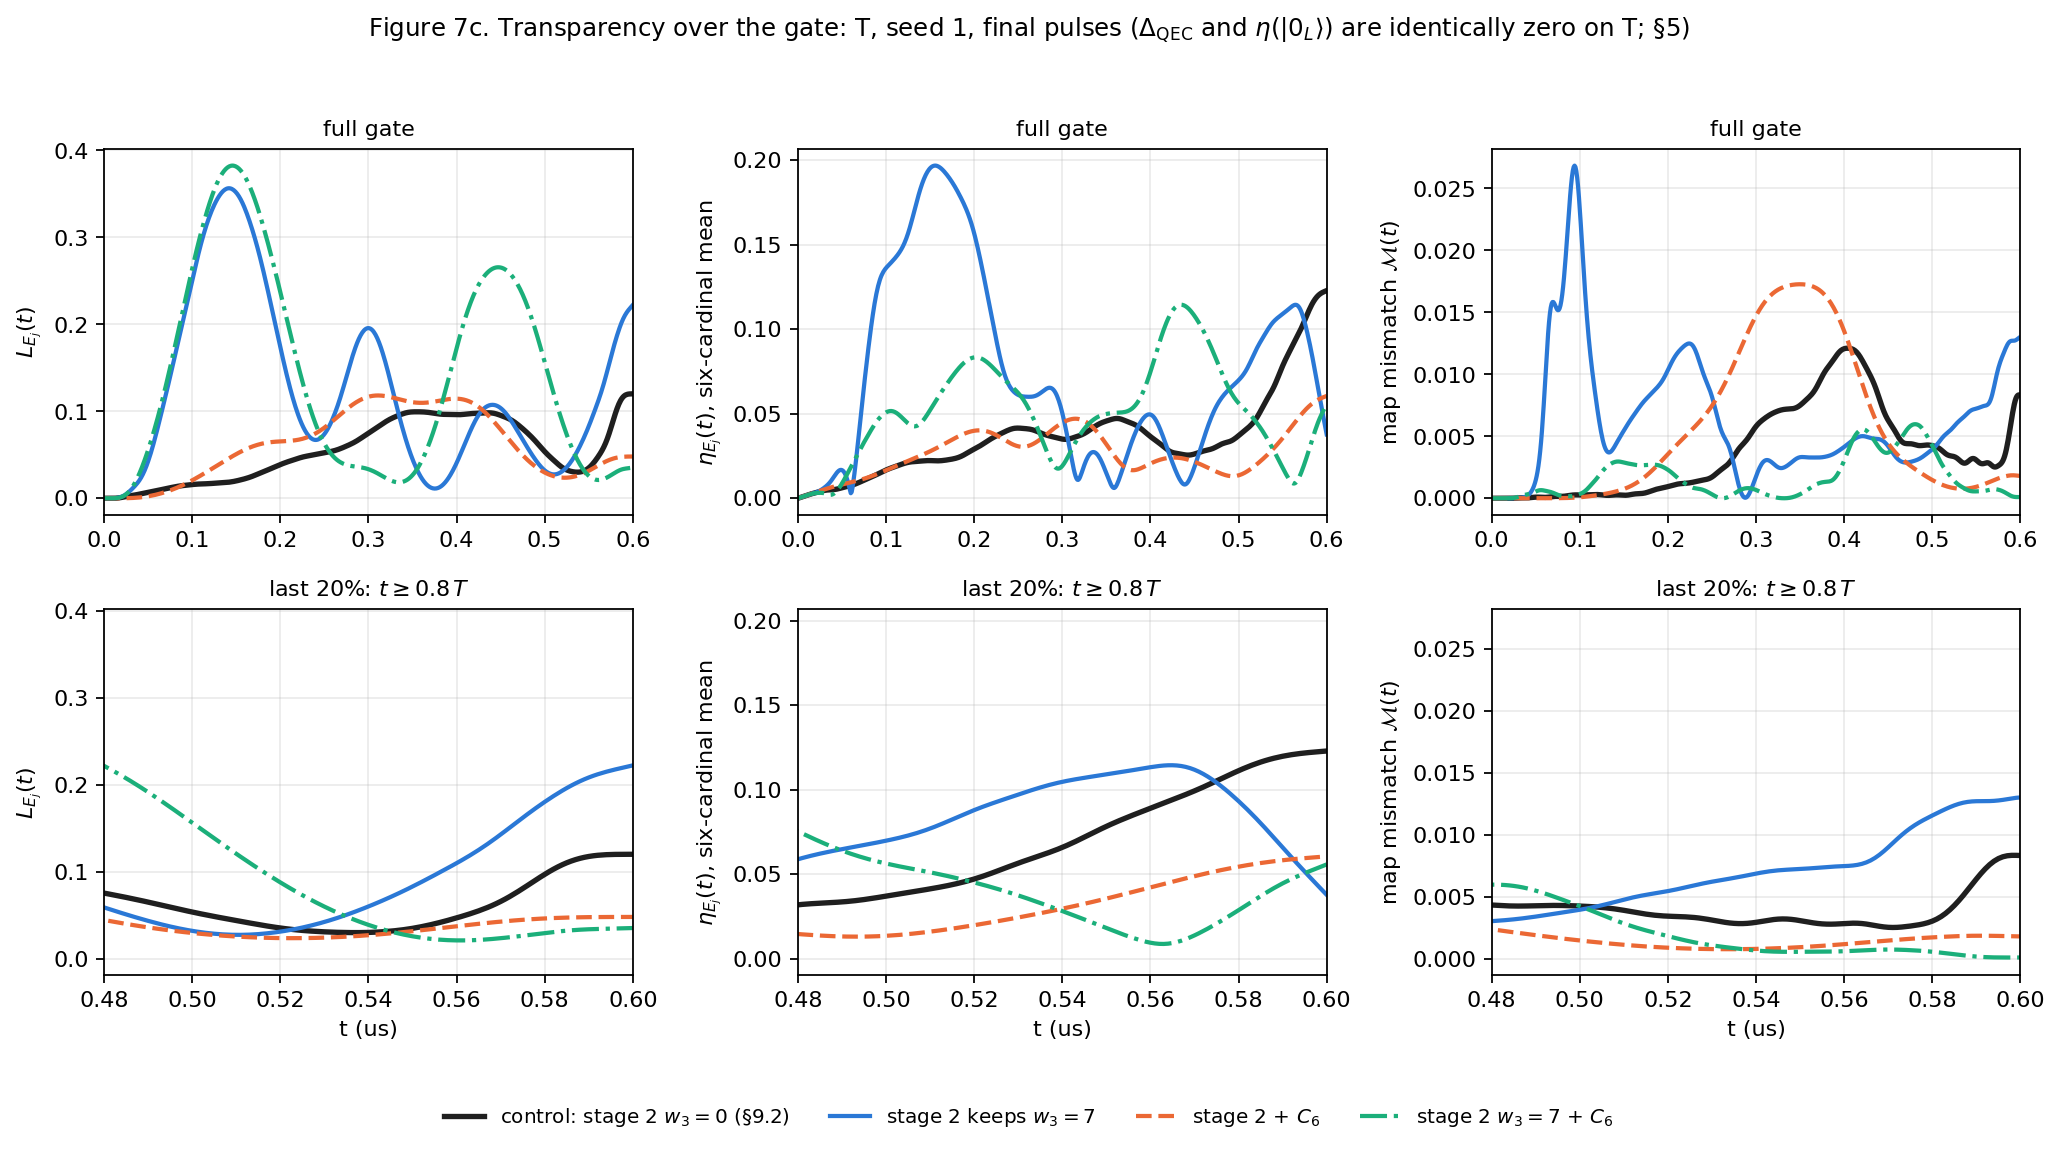

In [46]:
# Figure 7c: the transparency metrics that CAN move on T, over the gate; bottom row zooms to
# the end. Delta_QEC and eta(|0_L>) are machine zero for every T pulse (§5), so they are not drawn.
if s2_have:
    TR12 = [("L", r"$L_{E_j}(t)$"), ("eta_avg", r"$\eta_{E_j}(t)$, six-cardinal mean"),
            ("M", r"map mismatch $\mathcal{M}(t)$")]
    fig, axes = plt.subplots(2, 3, figsize=(13.0, 7.0), sharey="col")
    for c, (key, ylab) in enumerate(TR12):
        for r in range(2):
            ax = axes[r, c]
            for run in s2_have:
                y = s2tr[f"{run}/final/{key}"]
                t = np.arange(len(y)) * device.DT
                ax.plot(t, y, color=S2_COLOR[run], ls=S2_LS[run],
                        lw=2.4 if run == "control" else 1.9, label=S2_LABEL[run])
            T = t[-1]
            ax.set_xlim((0.0 if r == 0 else 0.8 * T), T)
            ax.set_ylabel(ylab)
            ax.grid(alpha=0.25)
            ax.set_title(("full gate" if r == 0 else r"last 20%: $t \geq 0.8\,T$"), fontsize=10)
            if r == 1:
                ax.set_xlabel("t (us)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    fig.suptitle("Figure 7c. Transparency over the gate: T, seed 1, final pulses "
                 r"($\Delta_{\rm QEC}$ and $\eta(|0_L\rangle)$ are identically zero on T; §5)", fontsize=11)
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    fig7c_path = os.path.join(FIG_DIR, "fig7c_stage2_traces_T.png")
    fig.savefig(fig7c_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    show(fig7c_path, width=900)

**Figure 7c. Transparency over the gate.**
- **At the end (bottom row), `est_d2` beats the control on all three:** $L(T)$ 0.120 → 0.048,
  six-cardinal $\eta(T)$ 0.123 → 0.061, $\mathcal{M}(T)$ $8.3\times10^{-3} \to 1.8\times10^{-3}$. The
  control's rise in $L$ and $\eta$ over the last ~40 ns coincides with its drive spike.
- **Mid-gate it pays a little:** $\mathcal{M}$ peaks at 0.017 near 0.35 μs (control 0.012), and mean
  $L$ rises from 0.054 to 0.061.
- **The $w_3 = 7$ runs leak heavily early** ($L$ peaks at 0.36–0.38 near 0.15 μs), which is their
  time-averaged $F_{\rm ET}$ loss in Table 21. `est_c3s2_d2` finishes with the lowest $L(T)$ (0.035) and
  $\mathcal{M}(T)$ ($10^{-4}$) of any run, but on a pulse that is not the gate ($F_1 = 0.978$).

<a id="12.2"></a>
### 12.2 Results: is the drive still concentrated at $t = T$?

| | control | `est_c3s2` | `est_d2` | `est_c3s2_d2` |
|---|---|---|---|---|
| $F_1$ | 0.99998 | **0.97941** | 0.99994 | **0.97796** |
| stage-2 stop | maxiter | maxiter | pgtol (343 it) | maxiter |
| drive energy in the closing 48 ns | 35.4% | 13.4% | **7.1%** | 20.8% |
| peak $\lvert\varepsilon_T\rvert$ (rad/μs) | 25.1 at 584 ns | 22.1 at 56 ns | **6.7 at 304 ns** | 17.4 at 12 ns |
| $C_6$ | 526 | 428 | **34** | 127 |
| $C_3$ (speed unevenness) | 0.202 | 0.010 | 0.214 | 0.009 |
| $F_{\rm ET}$ | **0.945** | 0.873 | 0.939 | 0.858 |
| $L$ mean / at $T$ | **0.054** / 0.120 | 0.125 / 0.222 | 0.061 / 0.048 | 0.141 / 0.035 |
| six-cardinal $\eta$ mean / at $T$ | 0.036 / 0.123 | 0.074 / 0.038 | **0.027** / 0.061 | 0.051 / 0.056 |
| $\mathcal{M}$ mean / at $T$ | $3.7\times10^{-3}$ / $8.3\times10^{-3}$ | $6.4\times10^{-3}$ / $1.3\times10^{-2}$ | $5.4\times10^{-3}$ / $1.8\times10^{-3}$ | $1.7\times10^{-3}$ / $9.9\times10^{-5}$ |
| $F_{\rm err}(T)$ | 0.874 | 0.778 | 0.950 | 0.953 |
| transmon out-of-band fraction | 7.5% | 1.7% | **0.016%** | 1.2% |
| transmon pre-image entries at the box | 55 | 227 | **0** | 104 |

**Table 22. The answer in one table** (final pulses, $n_c = 20$, eigh propagator; Table 21 has the rest).
Bold marks the best among the runs that reach the gate ($F_1 \ge 0.9999$).

1. **Stage-2 $C_6$ ($w_6 = 10^{-4}$) evens out the drive and keeps the gate.** The end spike is gone,
   the largest drive is 27% of the cap and sits mid-gate, and stage 2 converges on gradient tolerance
   rather than running out of iterations. The pulse is also *more* transparent at the end: $L(T)$ is 2.5×
   lower, $\mathcal{M}(T)$ 4.6× lower, and $F_{\rm err}(T)$ rises from 0.874 to 0.950. So the closing spike
   was not a harmless correction; it was where the control's end-of-gate leak came from. The price is
   $F_1$ 0.99998 → 0.99994 and $F_{\rm ET}$ 0.945 → 0.939.
2. **Keeping $w_3 = 7$ in stage 2 does not produce a gate.** $7 \times C_3 \approx 0.072$ outweighs
   everything stage 2 can trade against it, so stage 2 barely moves off stage 1 ($C_1$ 0.034 → 0.021)
   and stops on `maxiter`. The drive is not evened out but re-concentrated at the start: the peak is at
   56 ns, with 40% of the energy in the first 100 ns. Every time-averaged transparency metric gets worse.
3. **Both together inherits that failure.** Adding $C_6$ cuts $C_6$ 3.4× against `est_c3s2` and gives
   the best endpoint numbers of any run, but at $F_1 = 0.978$.
4. **Why $C_3$ could not help.** It holds the *state speed* uniform, and it succeeds (Figure 7b,
   middle), yet the pulse with the least uniform speed has the most even drive. Uniform motion through
   Hilbert space is a property of the trajectory, not of the waveform.

<a id="12.3"></a>
### 12.3 Caveats

- **Single seed (1), single gate.**
- **$w_3 = 7$ is negative at this weight only.** A smaller stage-2 $w_3$ was not tried and might
  finish the gate.
- **$w_6 = 10^{-4}$ is the top of the pre-set grid.** All three screened weights passed, so a larger one
  may pass too. The grid was not widened after the results.
  - The choice is robust to the stage-1 budget: the 500-it screen and the 2000-it run reach the same
    drive distribution (7.2% vs 7.1% closing-window energy, peak 6.74 at 304 ns in both) from stage-1
    pulses 52% apart.
- **The control and the shared stage 1 are box-constrained.** Their raw pre-images have 55 and 127
  transmon entries pinned at `hard_bound = 60`, against none for `est_d2`. $C_4$ caps the physical
  amplitude either way, but the control is a box-constrained optimum. Part of `est_d2`'s gain may be
  $C_6$ pulling the pre-image off the box.
- **The two $w_3 = 7$ runs stopped on `maxiter`.** Their numbers are where L-BFGS-B was at 2000
  iterations, not converged values.
- **$C_3$ is the repo's normalized form** ([§2.1](#2.1)). The printed form is either inert or favours
  parking, and was not used.
- **$\Delta_{\rm QEC}$ and $\eta(|0_L\rangle)$ are not reported**, because they are identically zero on T
  ([§5](#5)).
- **Nothing was promoted.** The new pulses are
  `pulses/est/{u,x}_T_est_{c3s2,d2,c3s2_d2}_best2000[_stage1|_stage2].npy`. `u_T_est.npy` and
  `u_T_est_best2000.npy` are unchanged, and `est_d2` has not been given any delivered-pulse name.

<a id="A"></a>
# Appendix A. The printed cost function: X, seed 0

*Moved here from the main text: training with the cost function exactly as printed gave no improvement.*

Every pulse above was trained with the two deviations of [§2.3](#2.3):
- $C_2$ divides by $N_{\mathrm{norm}}^2$.
- $C_3$ is the velocity variance normalized by $\mathrm{mean}(v)^2$.

[Limitation 3](#10) names the first as one candidate for X's end-of-gate leakage ($L(T) = 0.396$ here, against $0.013$ in the paper). It also notes the deviation was "never checked for what it does to the endpoint". This section checks it directly. X is retrained cold, at the same seed (0) and the same budget (2000 it/stage) as the delivered `u_X_est`, with App. C's equations **as printed**:

| | repo form (`est`, everything above) | paper form (`paper`, this section) |
|---|---|---|
| $C_2$ | $\lvert\langle\psi_E\lvert a\rvert\psi_C\rangle\rvert^2 / N_{\mathrm{norm}}^2$, over $t_0 \dots t_N$ | $\lvert\langle\psi_E\lvert a\rvert\psi_C\rangle\rvert^2 / N_{\mathrm{norm}}$, over $t_0 \dots t_{N-1}$ (Eq. C2) |
| $C_3$ | $\mathrm{Var}_t(v)/\mathrm{mean}_t(v)^2$ | raw $\mathrm{Var}_t(v)$, $v = \tfrac{2}{\Delta t}\arccos\lvert\langle\psi_i\vert\psi_{i+1}\rangle\rvert$ at $\Delta t = 1$ ns, radians (Eqs. C4–C7) |
| stage 1 $(w_1, w_2, w_3)$ | $(1, 0.7, 7)$ | $(1, 0.6, 6)$ |
| stage 2 | $(1, 0.1, 0)$ | $(1, 0.1, 0)$ |

Reproduce with:

```bash
python EST/train_est.py --gate X --variant paper --seed 0 --maxiter 2000
```

`--variant paper` passes `grape_jax.PAPER_COST_FORM`; every default is unchanged, and `PaperCostFormTest` pins that.

**What to expect before looking.** Three things follow from the equations and were measured on the existing seed-0 pulses before training:

1. **The printed $C_2$ is unbounded below.** By Cauchy–Schwarz, $\lvert\langle\psi_E\lvert a\rvert\psi_C\rangle\rvert^2 / N_{\mathrm{norm}} \le N_{\mathrm{norm}} = \sqrt{\langle n\rangle} \approx 1.5$ on this code. So "$F_{\mathrm{ET}}$" can exceed 1, and the cost **rewards photon number** as well as transparency. It already reads $C_2 = -0.073$ on `u_X_est_stage1`. Watch $\langle n\rangle$, the max active Fock level and the truncation spread.
2. **The printed $C_3$ is nearly inert.** In (rad/ns)² it is $7\times10^{-5}$ on the trained stage-1 pulse and $1\times10^{-3}$ at the random start, so $w_3 C_3 \le 0.006$. Stage 1 is therefore effectively $C_1 + 0.6\,C_2 + C_4$. It does not let parking win either ([§2.3](#2.3)).
3. **Leaving out $t = T$ is a $1/1001$ reweighting**, included only because it is what Eq. (C2) says.

**The confound.** This run changes the cost form *and* the stage-1 weights ($0.7 \to 0.6$, $7 \to 6$), so a difference against `u_X_est` cannot be assigned to either alone. It is a test of "the paper as printed" against "this replication", not a single-factor ablation.

Two further rules for reading the tables below:
- **Compare transparency across the two runs only with shared metrics.** Eqs. 6–8 do not involve either cost form, so they are shared. The logged `c2`/`c3` are each in their own form.
- **A difference counts only if it clears the seed spread.** It must exceed what seed choice alone produces ([§9](#9)), which the last cell measures.

In [47]:
# Appendix A -- the paper-literal X pulse against the seed-0 repo-form EsT pulse and the Ord control.
import jax
import jax.numpy as jnp

P10_PATH = os.path.join(PULSE_DIR, "u_X_paper.npy")
HAVE_PAPER = os.path.exists(P10_PATH)
if not HAVE_PAPER:
    print("pulses/est/u_X_paper.npy not found -- train it with\n"
          "  python EST/train_est.py --gate X --variant paper --seed 0 --maxiter 2000")
else:
    P10 = {"est": np.load(os.path.join(PULSE_DIR, "u_X_est.npy")),
           "ord": np.load(os.path.join(PULSE_DIR, "u_X_ord.npy")),
           "paper": np.load(P10_PATH)}
    RUN10 = {"paper": load_run("X", "paper"), "est": load_run("X", "est")}
    LABEL10 = {"est": "EsT, repo form", "ord": "Ord", "paper": "EsT, paper form"}

    # 1) The training trace, each run in its OWN cost form -- so c2/c3 are not comparable
    #    across the two runs (paper c2 can be negative; paper c3 is in (rad/ns)^2).
    rows = []
    for v, info in RUN10.items():
        for st in info["stages"]:
            t = st["terms"][str(info["trunc_list"][0])]
            rows.append({"run": LABEL10[v], "seed": info["seed"], "stage": st["stage"],
                         "weights": "(" + ", ".join(f"{w:g}" for w in st["weights"][:3]) + ")",
                         "nit": st["nit"], "c1": t["c1"], "c2 (own form)": t["c2"],
                         "c3 (own form)": t["c3"], "c4": t["c4"],
                         "max|x|": st["max_abs_preimage"], "hours": st["seconds"] / 3600})
    display(pd.DataFrame(rows).style.format(
        {"c1": "{:.5f}", "c2 (own form)": "{:+.4f}", "c3 (own form)": "{:.3e}",
         "c4": "{:.1e}", "max|x|": "{:.1f}", "hours": "{:.2f}"}).hide(axis="index"))
    print("cost form of the paper run:", RUN10["paper"]["cost_form"])
    print("amplitude cap satisfied   :", RUN10["paper"]["constraints"]["amplitude_cap_satisfied"])

    # 2) Cross-score: every pulse under BOTH cost forms, at n_c = 20. This separates
    #    "a different objective value" from "a different pulse".
    H0_np, Hc_np = device.make_hamiltonian_est(device.N_T, N_C)
    A_np, _ = make_ops(device.N_T, N_C)
    jargs = (jnp.asarray(H0_np, dtype=jnp.complex128),
             jnp.stack([jnp.asarray(h, dtype=jnp.complex128) for h in Hc_np]),
             jnp.asarray(A_np, dtype=jnp.complex128),
             jnp.asarray(kitten_code.cardinals(device.N_T, N_C), dtype=jnp.complex128),
             jnp.asarray(kitten_code.error_cardinals(device.N_T, N_C), dtype=jnp.complex128),
             jnp.asarray(kitten_code.gate_target("X", device.N_T, N_C), dtype=jnp.complex128),
             device.DT)
    FORMS10 = {"repo":  ({}, (1.0, 0.7, 7.0, 1.0)),
               "paper": (grape_jax.PAPER_COST_FORM, (1.0, 0.6, 6.0, 1.0))}
    rows = []
    for fname, (form, W) in FORMS10.items():
        terms = jax.jit(grape_jax.make_cost_terms(*jargs, **form))
        for v, u in P10.items():
            t = {k: float(x) for k, x in terms(jnp.asarray(u)).items()}
            rows.append({"pulse": LABEL10[v], "cost form": fname, **t,
                         "stage-1 C_tot": sum(w * t[k] for w, k in zip(W, ("c1", "c2", "c3", "c4")))})
    xs10 = pd.DataFrame(rows)
    xs10.to_csv(os.path.join(TABLE_DIR, "est_paper_X_costforms.csv"), index=False)
    display(xs10.style.format({"c1": "{:.5f}", "c2": "{:+.4f}", "c3": "{:.3e}", "c4": "{:.1e}",
                               "stage-1 C_tot": "{:+.4f}"}).hide(axis="index"))


run,seed,stage,weights,nit,c1,c2 (own form),c3 (own form),c4,max|x|,hours
"EsT, paper form",0,1,"(1, 0.6, 6)",2000,0.02588,-0.1894,8.533e-04,4.2e-05,60.0,3.63
"EsT, paper form",0,2,"(1, 0.1, 0)",2000,0.00205,-0.1188,1.750e-03,4.6e-06,60.0,2.03
"EsT, repo form",0,1,"(1, 0.7, 7)",2000,0.04294,+0.2710,9.495e-03,4.5e-05,60.0,1.40
"EsT, repo form",0,2,"(1, 0.1, 0)",2000,0.00071,+0.2700,1.477e-01,4.5e-06,60.0,1.49


cost form of the paper run: {'c2_norm_power': 1, 'c2_include_endpoint': False, 'c3_normalize': False, 'c3_dt': 1.0}
amplitude cap satisfied   : True


pulse,cost form,c1,c2,c3,c4,stage-1 C_tot
"EsT, repo form",repo,0.00071,+0.2700,1.477e-01,4.5e-06,+1.2238
Ord,repo,0.00000,+0.8060,1.197e-01,0.0e+00,+1.4021
"EsT, paper form",repo,0.00205,+0.2819,1.341e-01,4.6e-06,+1.1379
"EsT, repo form",paper,0.00071,-0.0623,1.367e-03,4.5e-06,-0.0284
Ord,paper,0.00000,+0.7209,9.012e-04,0.0e+00,+0.4380
"EsT, paper form",paper,0.00205,-0.1188,1.750e-03,4.6e-06,-0.0587


### A.1 The run, and what it optimised

**Both stages ran to `maxiter`.**

| stage | iterations | cost evaluations | hours | c₁ | c₂ | c₃ (rad/ns)² |
|---|---|---|---|---|---|---|
| 1 | 2000 | 2182 | 3.6 | 0.026 | $-0.189$ | $8.5\times10^{-4}$ |
| 2 | 2000 | 2193 | 2.0 | 0.0021 | $-0.119$ | $1.8\times10^{-3}$ |

$c_2$ is in the paper's own form, so $-0.189$ means "$F_{\mathrm{ET}}$" $= 1.19$.

- **Stage 1** confirms both predictions from the introduction. $C_2$ went well below zero, which only the $N_{\mathrm{norm}}$ normalisation allows. $w_3 C_3 = 0.005$, so the velocity term did essentially nothing.
- **Cost per iteration** was the same as every earlier X run (1.09 evaluations per iteration). The run was slow only because each evaluation was slower, partly because some of it ran on the machine's low-power cores. The hours are therefore not a property of the cost form.

**The pre-image box was touched, but not where it matters.**
- `max|x|` reached the `hard_bound` of 60 in both stages. The final pre-image has 52 entries (1.30%) pinned at the bound.
- **All 52 sit inside the 24-step ramp windows.** There the envelope scales them to about 1% amplitude.
- **The delivered `u_X_est` shows the same pattern:** 15 pinned entries (0.38%), all at the edges.
- **This is not the basin collapse of [`u_Y` seed 42](#10).** It is the ramp-authority loss documented for the main pipeline, but 3.5× more pronounced here.

**Cross-scoring separates "a better optimum of a different objective" from "a better gate":**
- **Under the printed objective,** the paper pulse scores $C_{\mathrm{tot}} = -0.059$ against $-0.028$ for `u_X_est`. The optimiser did find a better point of the objective it was given.
- **Under the repo's bounded $C_2$,** the paper pulse is *less* transparent: $0.282$ against $0.270$.
- **Fidelity:** its infidelity is $2.05\times10^{-3}$, 2.9× the delivered pulse's $7.1\times10^{-4}$.

In [48]:
# Eqs. 6-8, scored exactly as §5 does, plus limitation 3's end-of-gate quantities (§10).
if HAVE_PAPER:
    EVAL_TRUNCS_P10 = (16, 18, 20, 22, 24, 28)
    N_RAMP = int(round(device.RAMP_NS * 1e-3 / device.DT))

    def endpoint_overlap(u, gate="X", n_c=N_C):
        """Mean |<U_ideal E_m | psi_E,m(T)>|^2 over the six error cardinals: the
        'ideal gate applied in the error basis' overlap limitation 3 quotes (0.589 on u_X_est)."""
        H0n, Hcn = device.make_hamiltonian_est(device.N_T, n_c)
        An, _ = make_ops(device.N_T, n_c)
        tgt = An @ kitten_code.gate_target(gate, device.N_T, n_c)
        tgt = tgt / np.linalg.norm(tgt, axis=0, keepdims=True)
        errT = diagnostics.propagate_states(u, H0n, Hcn,
                                            kitten_code.error_cardinals(device.N_T, n_c),
                                            device.DT)[-1]
        return float(np.mean(np.abs(np.sum(tgt.conj() * errT, axis=0)) ** 2))

    def score10(u):
        r = diagnostics.analyze(u, gate="X", n_c=N_C)
        return r, {"delta_qec_mean": r["delta_qec"].mean(), "leakage_mean": r["leakage"].mean(),
                   "eta_0L_mean": r["eta_0L"].mean(), "eta_avg_mean": r["eta_avg"].mean(),
                   "L(T)": r["leakage"][-1], "L last 48 ns": r["leakage"][-N_RAMP:].mean(),
                   "eta_0L(T)": r["eta_0L"][-1], "eta_avg(T)": r["eta_avg"][-1],
                   "error-basis overlap(T)": endpoint_overlap(u)}

    R10, rows = {}, []
    for v, u in P10.items():
        r, m = score10(u)
        R10[v] = r
        scan = diagnostics.truncation_scan(u, "X", trunc_list=EVAL_TRUNCS_P10)
        rows.append({"pulse": LABEL10[v], "F1": r["F1"],
                     "F_heldout_mean": np.mean([scan[n] for n in EVAL_TRUNCS_P10 if n != N_C]),
                     "trunc_spread": max(scan.values()) - min(scan.values()),
                     "max_active_fock": r["max_active_fock"],
                     "F_ET (repo form)": 1.0 - r["c2_integrand"].mean(), **m})
    met10 = pd.DataFrame(rows)
    met10.to_csv(os.path.join(TABLE_DIR, "est_paper_X_metrics.csv"), index=False)
    fmt = {c: "{:.4f}" for c in met10.columns if c not in ("pulse", "max_active_fock")}
    fmt.update({"F1": "{:.6f}", "F_heldout_mean": "{:.6f}", "trunc_spread": "{:.2e}"})
    display(met10.style.format(fmt).hide(axis="index"))

    FIG10 = {}
    for s in ("log", "linear"):
        FIG10[s] = diagnostics.plot_fig1(
            R10, os.path.join(FIG_DIR, "fig1def_paper_X" + ("" if s == "log" else "_linear") + ".png"),
            scale=s)


pulse,F1,F_heldout_mean,trunc_spread,max_active_fock,F_ET (repo form),delta_qec_mean,leakage_mean,eta_0L_mean,eta_avg_mean,L(T),L last 48 ns,eta_0L(T),eta_avg(T),error-basis overlap(T)
"EsT, repo form",0.999285,0.999284,8.03e-06,9,0.7300,0.1561,0.2575,0.1688,0.2087,0.3964,0.3923,0.0913,0.2550,0.5887
Ord,0.999999,0.999999,1.29e-09,8,0.1940,0.4808,0.7399,1.1119,1.1853,0.8238,0.8250,1.5482,1.1642,0.1133
"EsT, paper form",0.997948,0.997935,3.44e-05,13,0.7181,0.1573,0.2660,0.1338,0.2219,0.4704,0.4478,0.1463,0.7823,0.4106


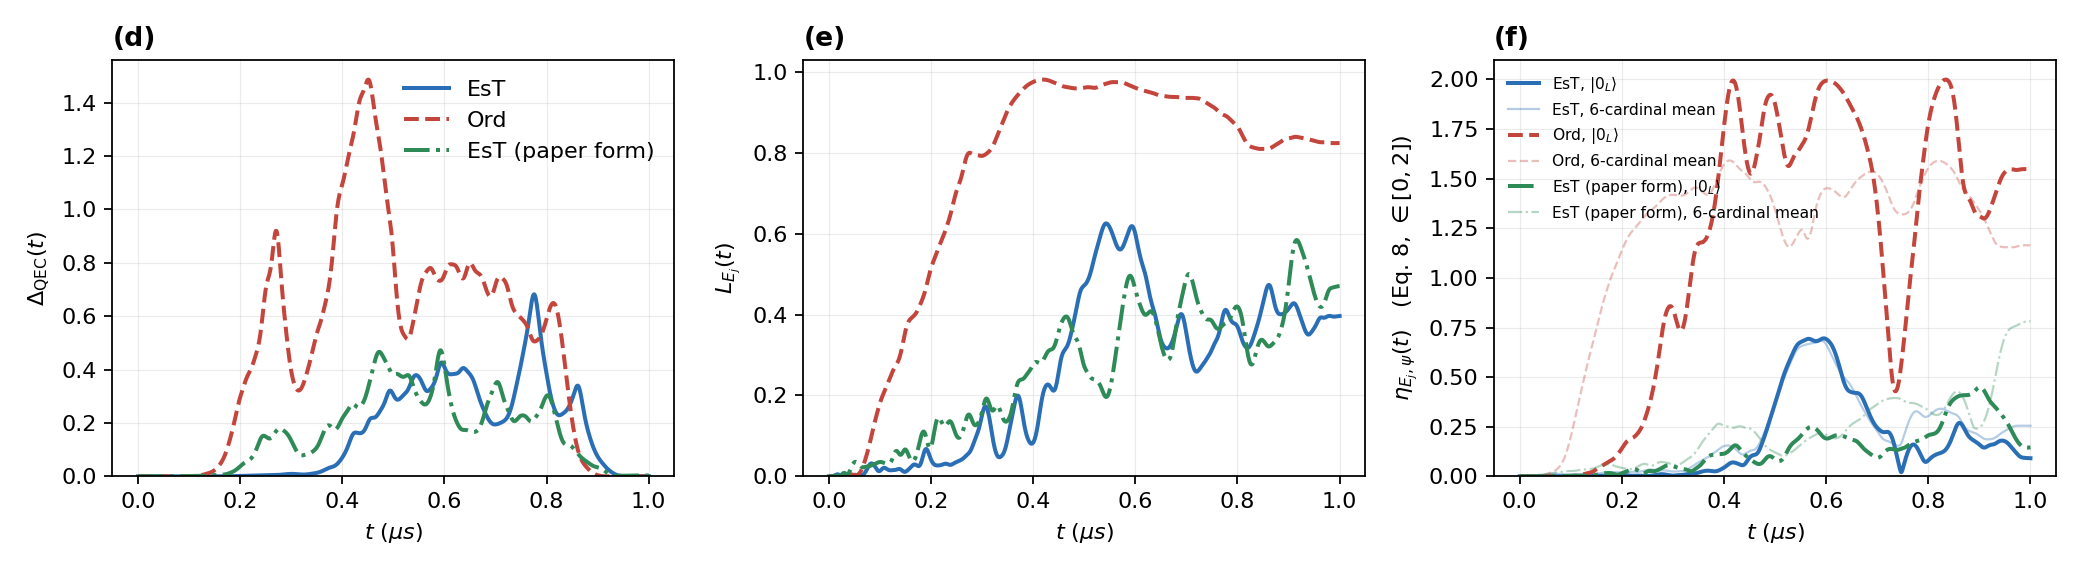

In [49]:
if HAVE_PAPER:
    show(FIG10["linear"], width=900)

**Figure A1. X gate: $\Delta_{\mathrm{QEC}}$, $L_{E_j}$, $\eta_{E_j,\psi}$ against time, paper-form EsT
(green dash-dot) vs repo-form EsT (blue) and Ord (red dashed), linear axes.** Same panels as Figure 2a.
The paper form's $L$ runs lower mid-gate but rises over the last ~100 ns, ending at $L(T) = 0.470$ against 0.396.

### A.2 Transparency: no better on average, worse at the end

**Convergence holds despite the extra photons.**
- The truncation spread is $3.4\times10^{-5}$, well under the $10^{-3}$ criterion, and held-out $F_1 = 0.99794$.
- But the highest active Fock level is **13**, against 9 for `u_X_est` and 8 for Ord. That makes [limitation 2](#10)'s like-for-like problem worse, not better.

**Time-averaged, the two EsT pulses are indistinguishable.** The paper pulse is better on one metric and worse on two, all by small amounts, and ties on the fourth:

| metric | repo form | paper form |
|---|---|---|
| $\Delta_{\mathrm{QEC}}$ | 0.156 | 0.157 |
| $L$ | 0.258 | 0.266 |
| $\eta(\lvert 0_L\rangle)$ | 0.169 | 0.134 |
| $\eta$ (6-card) | 0.209 | 0.222 |

**At the end of the gate, every quantity moves the wrong way:**

| at $t = T$, X gate | EsT, repo form | EsT, paper form | Roy *et al.* |
|---|---|---|---|
| $L(T)$ | 0.396 | **0.470** | 0.013 |
| mean $L$ over the final 48 ns | 0.392 | **0.448** | — |
| $\eta(\lvert 0_L\rangle)$ at $T$ | 0.091 | **0.146** | — |
| $\eta$ (6-card) at $T$ | 0.255 | **0.782** | — |
| error-basis overlap at $T$ | 0.589 | **0.411** | — |

**Figure A1 shows where it goes wrong.** In panel (e), the paper-form $L(t)$ runs *below* the repo-form pulse through the middle of the gate (peak ≈ 0.50 against ≈ 0.62 near $t = 0.55$ μs). It then spikes to ≈ 0.59 at $t \approx 0.92$ μs and finishes at 0.47. In panel (f), its six-cardinal $\eta$ climbs to ≈ 0.78 in the last ~50 ns.

**Stage 2 is where the two runs part.** Scored the same way:

| | stage 1 repo | stage 1 paper | stage 2 repo | stage 2 paper |
|---|---|---|---|---|
| $L$ (mean) | 0.260 | 0.231 | 0.258 | 0.266 |
| $L(T)$ | 0.519 | 0.432 | 0.396 | 0.470 |
| error-basis overlap at $T$ | 0.447 | 0.427 | 0.589 | 0.411 |
| $\Delta_{\mathrm{QEC}}$ (mean) | 0.173 | 0.123 | 0.156 | 0.157 |

- **After stage 1, the paper form looked *better*** on $L$, $L(T)$ and $\Delta_{\mathrm{QEC}}$.
- **The repo form's stage 2** then pulled the error space home: $L(T)$ 0.519 → 0.396, overlap 0.447 → 0.589.
- **The paper form's stage 2 drifted away:** $L(T)$ 0.432 → 0.470, overlap 0.427 → 0.411.
- **A consistent explanation, not a demonstrated one.** At $w_2 = 0.1$ only a small $C_2$ term remains beside $C_1$. Under the bounded form that term can only reward transparency. Under the printed form it rewards photon number just as readily, so it no longer pulls the endpoint toward correctability.

In [50]:
# §4's subspace numbers (table only): does the photon-number incentive of the printed C2 show up?
if HAVE_PAPER:
    S10 = {v: subspace_evolution.analyze_subspace(u, gate="X", n_c=N_C) for v, u in P10.items()}
    sub10 = pd.DataFrame([{"pulse": LABEL10[v],
                           "<n>_C mean": r["nbar_code"].mean(), "<n>_C peak": r["nbar_code"].max(),
                           "<n>_E mean": r["nbar_err"].mean(), "<n>_E peak": r["nbar_err"].max(),
                           "mean |<n>_E - <n>_loss|": r["nbar_track_err"].mean(),
                           "mean M(t)": r["mismatch"].mean(), "M(T)": r["mismatch"][-1]}
                          for v, r in S10.items()])
    sub10.to_csv(os.path.join(TABLE_DIR, "est_paper_X_subspace.csv"), index=False)
    display(sub10.style.format({c: "{:.3f}" for c in sub10.columns if c != "pulse"}).hide(axis="index"))
    FIG10["wave"] = plot_est_waveforms(
        P10["paper"], P10["est"], "X", labels=("EsT, paper form", "EsT, repo form"),
        save_path=os.path.join(FIG_DIR, "fig3_waveforms_paper_X.png"))


pulse,_C mean,_C peak,_E mean,_E peak,mean |_E - _loss|,mean M(t),M(T)
"EsT, repo form",2.146,2.867,2.171,3.457,0.285,0.201,0.027
Ord,2.230,3.241,2.315,3.986,0.618,0.591,0.536
"EsT, paper form",2.523,4.419,2.584,4.831,0.468,0.243,0.312


saved -> /Users/ziyi_dong_mac/Documents/GitHub/Qubit-Drive-GRAPE/figures/est/fig3_waveforms_paper_X.png


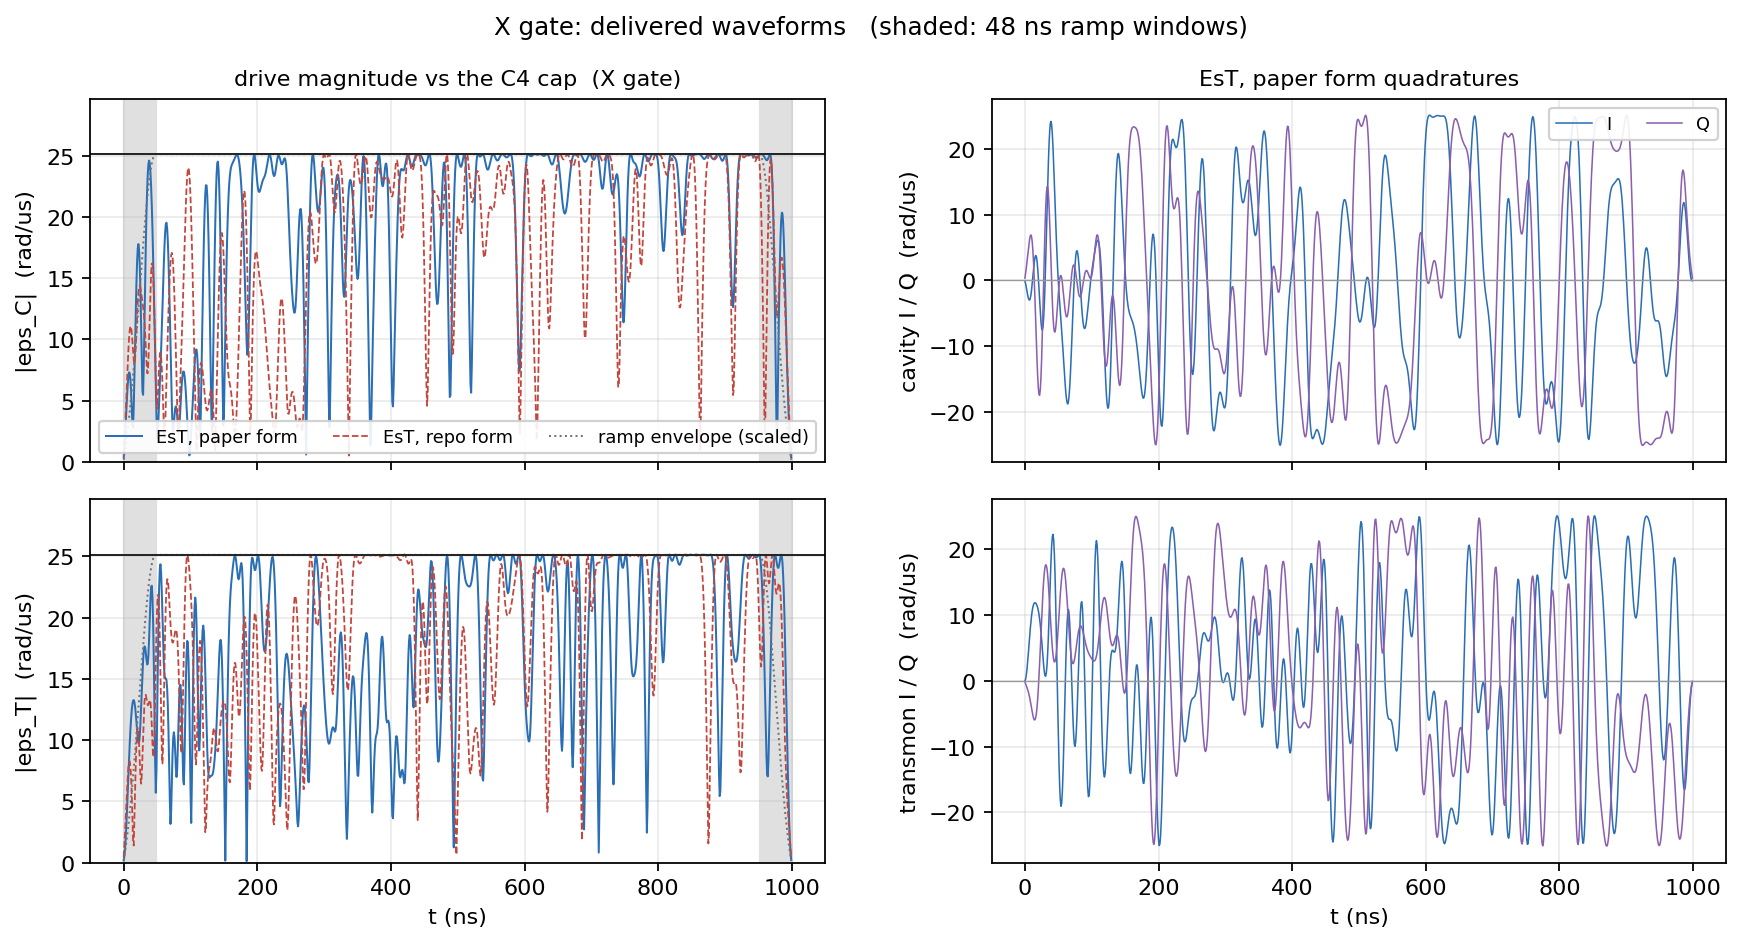

In [51]:
if HAVE_PAPER:
    show(FIG10["wave"], width=880)

**Figure A2. X gate: delivered waveforms, paper-form EsT (blue) vs repo-form EsT (red dashed).**
Left: quadrature-pair magnitude against the $C_4$ cap (solid black), ramp envelope dotted, 48 ns ramp windows
shaded. Right: the paper-form pulse's I/Q quadratures. Its cavity drive sits at the cap for 24% of the gate,
against 11% for the repo form.

### A.3 Where the transparency went: photon number

**The printed $C_2$'s photon-number incentive is fully visible.**

| | repo form | paper form |
|---|---|---|
| code-space $\langle n\rangle_C$, mean / peak | 2.15 / 2.87 | 2.52 / **4.42** |
| error-space $\langle n\rangle_E$, peak | 3.46 | **4.83** |

**Every tracking measure is worse:**
- Mean $\lvert\langle n\rangle_E - \langle n\rangle_{\mathrm{loss}}\rvert$ is **0.468** against 0.285.
- Mean map mismatch $\overline{\mathcal{M}}$ is 0.243 against 0.201.
- At the end of the gate, $\mathcal{M}(T) = 0.312$ against $0.027$, a factor of 11.

**The waveforms (Figure A2) show how the photons were bought: amplitude moves onto the cavity drive.**

| share of the gate at the 25.13 rad/μs $C_4$ cap (≥ 99%) | repo form | paper form |
|---|---|---|
| cavity drive | 11% | **24%** |
| transmon drive | 23% | 15% |

The mean cavity amplitude rises from 0.69 to 0.79 of the cap, while the transmon drive does the reverse.

The cavity drive is the one that changes photon number directly. The printed objective's $C_2$ pays for exactly that, at the transmon drive's expense.

In [52]:
# Is the paper-vs-repo difference bigger than what seed choice alone does?
# Reference: §9's ten X cold starts (repo form, 500 it/stage), parked seeds excluded.
if HAVE_PAPER:
    ms_x = pd.read_csv(os.path.join(TABLE_DIR, "est_multiseed_X.csv"))
    driven = ms_x[ms_x.F1_trained > 0.5].seed.tolist()
    SPREAD_CSV = os.path.join(TABLE_DIR, "est_paper_X_seedspread.csv")
    if REGENERATE_FIGURES or not os.path.exists(SPREAD_CSV):
        spread10 = pd.DataFrame([{"seed": s, **score10(np.load(
            os.path.join(PULSE_DIR, f"u_X_est_seed{s}.npy")))[1]} for s in driven])
        spread10.to_csv(SPREAD_CSV, index=False)
    else:
        spread10 = pd.read_csv(SPREAD_CSV)

    KEYS10 = ["leakage_mean", "L(T)", "L last 48 ns", "eta_0L_mean", "eta_avg_mean",
              "delta_qec_mean", "error-basis overlap(T)"]
    e = met10.set_index("pulse").loc[LABEL10["est"]]
    p = met10.set_index("pulse").loc[LABEL10["paper"]]
    rows = []
    for k in KEYS10:
        lo, hi = spread10[k].min(), spread10[k].max()
        d = p[k] - e[k]
        rows.append({"metric": k, "EsT repo (seed 0)": e[k], "EsT paper (seed 0)": p[k],
                     "paper - repo": d, "seed min": lo, "seed max": hi, "seed range": hi - lo,
                     "|diff| / range": abs(d) / (hi - lo),
                     "resolved": "yes" if abs(d) > hi - lo else "no (within seed range)"})
    verdict10 = pd.DataFrame(rows)
    print(f"seed spread over {len(driven)} driven seeds {driven} "
          f"(parked excluded: {sorted(set(ms_x.seed) - set(driven))})")
    display(verdict10.style.format({c: "{:+.4f}" if c == "paper - repo" else "{:.4f}"
                                    for c in verdict10.columns
                                    if c not in ("metric", "resolved")}).hide(axis="index"))


seed spread over 6 driven seeds [0, 2, 4, 5, 6, 8] (parked excluded: [1, 3, 7, 9])


metric,EsT repo (seed 0),EsT paper (seed 0),paper - repo,seed min,seed max,seed range,|diff| / range,resolved
leakage_mean,0.2575,0.2660,+0.0085,0.2792,0.3333,0.0542,0.1564,no (within seed range)
L(T),0.3964,0.4704,+0.0740,0.5492,0.8067,0.2575,0.2874,no (within seed range)
L last 48 ns,0.3923,0.4478,+0.0555,0.5699,0.7909,0.2211,0.2512,no (within seed range)
eta_0L_mean,0.1688,0.1338,-0.0350,0.1696,0.5466,0.3769,0.0929,no (within seed range)
eta_avg_mean,0.2087,0.2219,+0.0131,0.2354,0.4831,0.2477,0.0530,no (within seed range)
delta_qec_mean,0.1561,0.1573,+0.0012,0.1588,0.4507,0.2919,0.0042,no (within seed range)
error-basis overlap(T),0.5887,0.4106,-0.1781,0.1192,0.3989,0.2798,0.6365,no (within seed range)


### A.4 Verdict

**About the seed-spread yardstick above.** It uses the six driven seeds of [§9](#9)'s ten X cold starts; seeds 1, 3, 7 and 9 parked and are excluded. Those are repo-form pulses at **500** it/stage. They are worse than both 2000-it seed-0 pulses on nearly every end-of-gate quantity ($L(T)$ spans 0.55–0.81), so the range is a generous measure of seed-to-seed variation at a lower budget, not a like-for-like error bar. Measured against it, no single paper-vs-repo difference is resolved. $|\Delta|/\text{range}$ runs from 0.00 ($\Delta_{\mathrm{QEC}}$) to 0.64 (error-basis overlap at $T$).

With that caveat, the answer to "is the printed cost function more error-transparent, with less leakage at the end?":

1. **More error-transparent: no.** Time-averaged $\Delta_{\mathrm{QEC}}$, $L$ and $\eta$ split and move by $\le 0.035$, well inside seed variation. The bounded $F_{\mathrm{ET}}$ is slightly *lower* (0.718 against 0.730).
2. **Less leakage at the end: no, the opposite direction.** All five end-of-gate quantities get worse:
   - $L(T)$ $+0.074$
   - mean $L$ over the final 48 ns $+0.056$
   - $\eta$ (6-card) at $T$ $+0.53$
   - error-basis overlap $-0.178$
   - $\mathcal{M}(T)$ $0.027 \to 0.312$

   The direction is consistent. The size is not resolved at one seed per form.
3. **What it costs:**
   - 2.9× the infidelity ($F_1 = 0.99795$);
   - max active Fock 13 against 9;
   - 3.5× more pre-image entries pinned at the box, all inside the ramp windows;
   - a drive that lives on the amplitude cap.

**For [limitation 3](#10)**, candidate 2 is not the explanation. The printed normalisation moves $L(T)$ from 0.396 to 0.470, *away* from the published 0.013. Two caveats apply:
- **Only one seed each.**
- **Confounded.** The form change came with the weight change $(0.7, 7) \to (0.6, 6)$.

A clean attribution would need a repo-form run at $(0.6, 6)$ and more than one seed per form. Neither was run. What the result does rule out is the specific hope that transcribing Eq. (C2) literally recovers the published endpoint.

---

**Notebook complete.** Regenerated on this run: `figures/est/fig1a_subspace[_H][_T].png|.pdf`,
`figures/est/fig1def_est_vs_ord[_H][_T][_linear].png`, `tables/est_fig1_metrics[_H][_T].csv`,
`tables/est_fig1a_subspace[_H][_T].csv`. Newly written: `figures/est/fig3_waveforms_{X,H,T}.png`,
`figures/est/fig5_best2000_{X,H,T}[_log].png`, `tables/est_fig5_best2000.csv`.
Nothing under `EST/`, `core/`, `pulses/`, or `logs/` is modified by this notebook.
The `best2000` pulses themselves (`pulses/est/{u,x}_<g>_est_best2000.npy`,
`logs/est_<g>_est_best2000.json`) are written by `EST/train_est_eigh.py`, not by any cell.

The `est_fig1_metrics*.csv` schema changed when Eqs. 6--8 were transcribed ([§2.3](#2.3)):
`eta_mean` was replaced by `eta_0L_mean` and `eta_avg_mean`, and `c2_integrand_mean` was added.
The archived 600-iteration pair and the warm/eigh pulses are rescored with
`python EST/diagnostics.py --gate X --suffix _it600` (and `_warm`, `_eigh`), which suffixes its
outputs so it cannot clobber the delivered pair's. **No pulse was retrained** by that change:
the metrics are analysis-only and `et_cost` was not touched, so `tables/est_multiseed_*.csv`,
`logs/est_*.json` and everything under `pulses/` are byte-identical across it.

To retrain from scratch, set `RUN_TRAINING = True` in the preamble and run the six commands in
[§3](#3) sequentially, budgeting up to 10.1 h for the slowest (`H`/`ord`, loaded machine) and
well under a minute for the fastest (`T`/`ord`, converges on `pgtol`). The X/`est` run of [§8](#8)'s
second pipeline is reproduced with `python EST/train_est_eigh.py --gate X --variant est --maxiter 2000
--seed 0` (~1.0 h), and its per-call benchmark with `python EST/bench_propagators.py` on an
otherwise idle machine.

[§9](#9)'s thirty-run multi-seed sample is regenerated separately, and is the one part of this
notebook whose inputs are not written by any cell above. It produces, per gate,
`tables/est_multiseed_<gate>.csv`, `tables/est_multiseed_cache/<gate>_seed{0..9}.json`,
`pulses/est/{u,x}_<gate>_est_seed{0..9}.npy`, `pulses/est/{u,x}_<gate>_est_multiseed.npy` and
`logs/est_<gate>_est_multiseed.json`, plus the notebook-drawn
`figures/est/fig4_multiseed.png`. Reproduce with the sharded loop in [§9](#9) (5.5 h of compute:
12.4 min per seed on X, 12.9 on H, 7.5 on T). Note that the per-seed cache key is
`<gate>_seed<seed>` and does **not** encode `maxiter`, so re-running at a different budget
silently reuses these pulses unless `--force` is passed.

[§9.2](#9.2)'s three full-budget cold starts are also CLI, not notebook:
`python EST/train_est_eigh.py --gate {X,H,T} --variant est --maxiter 2000 --seed {6,6,1} --tag best2000`
(0.85 h, 0.85 h, 0.49 h; 0.85 h wall in parallel). Do not pass `--force` to
`multiseed_est.py` to produce them — that cache key does not record `maxiter` and would
overwrite the 500-it screen this section still reads.

`EST/README.md` carries the full technical background; `EST/test_grape_jax.py` and
`EST/test_grape_eigh.py` are the contracts that the deviations in [§2.3](#2.3) are
deliberate and that the two pipelines compute the same objective.

[§12](#12) regenerates `figures/est/fig7{a,b,c}_stage2_*_T.png`, `tables/est_stage2_T_seed1.csv`,
`tables/est_stage2_T_seed1_scan.csv` and `tables/est_stage2_T_seed1_traces.npz` through
`EST/stage2_t.py`. Its seven training runs (three 500-it/stage screens, three 2000-it/stage configs,
and §9.2's control) are written by `EST/train_est_eigh.py`, not by any cell;
`python EST/stage2_t.py commands` prints them. The full runs took 0.3–0.5 h each, three at a time.